# Large-FOV Nuclear Pipeline — v16.2 (v9 segmentation contract)

**v16.2** — the training-set generator's Stage-2 gate (NPC-shell organisation +
membrane co-localisation) is now applied in the segmentation block. Ported from
`vulcan_training_1.1.ipynb` sections 4b / 5b / 6; see Section 7a. Adding config
fields changes the run signature, so this lands in a NEW `Runs/<run_id>/` and
v16.1 results are not overwritten.


**Improvements over the previous version**

- All imports consolidated in one place; no re-imports scattered across cells.
- `gc` and `skimage.filters` (required by the focus scorer) added to the import block.
- Critical logic bug in `assign_track_ids_hybrid_dbscan` fixed (misindented `continue`
  caused the match loop body to be skipped for every match).
- Duplicate `plot_largest_cross_sectional_area_vs_time` definition removed.
- `label_and_measure_objects` (Section 7) merged into the existing `regionprops_to_rows`
  path — one code path instead of two diverging implementations.
- `extract_objects_from_saved_masks` now skips `included=False` rows instead of loading
  empty mask files.
- Debug `print` statements removed from the Hungarian-assignment inner loop.
- `segment_single_plane_with_overlap` no longer called with an unsupported `batch_size=`
  kwarg; the config value is used instead.
- Model is loaded exactly once and reused across the debug and full-segmentation cells.
- Focus-scoring utilities moved above the cells that call them.
- **v14**: Full 4-class model compatibility (nucleus=class 3, NPC=class 2, droplet=class 1).
  Channel input order corrected to match training (NLS, NPC, Membrane).
  All hardcoded class counts replaced with config.num_classes.
- **v13**: Z floor/ceiling (`focus_min_z` / `focus_max_z`) applied to all focus scoring to exclude coverslip artefacts.
- **v14**: Full 4-class model compatibility (nucleus=class 3, NPC=class 2, droplet=class 1).
  Channel input order corrected to match training (NLS, NPC, Membrane).
  All hardcoded class counts replaced with config.num_classes.
- **v13**: NPC-ring focus scoring added for early timepoints where nuclear channel signal is absent.
- **v14**: Full 4-class model compatibility (nucleus=class 3, NPC=class 2, droplet=class 1).
  Channel input order corrected to match training (NLS, NPC, Membrane).
  All hardcoded class counts replaced with config.num_classes.
- **v13**: Adaptive three-way channel selection matching the training notebook logic.
- **v14**: Full 4-class model compatibility (nucleus=class 3, NPC=class 2, droplet=class 1).
  Channel input order corrected to match training (NLS, NPC, Membrane).
  All hardcoded class counts replaced with config.num_classes.
- **v13**: `npc_channel_index` added to `PipelineConfig`.
- **v14**: Full 4-class model compatibility (nucleus=class 3, NPC=class 2, droplet=class 1).
  Channel input order corrected to match training (NLS, NPC, Membrane).
  All hardcoded class counts replaced with config.num_classes.
- **v13**: `focus_score_npc_ring` added to focus scoring utilities.
- **v14**: Full 4-class model compatibility (nucleus=class 3, NPC=class 2, droplet=class 1).
  Channel input order corrected to match training (NLS, NPC, Membrane).
  All hardcoded class counts replaced with config.num_classes.
- **v13**: `get_best_focus_z_indices_adaptive` replaces single-channel `get_best_focus_z_indices` in the segmentation loop.
- `configure_tensorflow_for_gpu` called once at runtime initialisation (Section 19).
- `plot_largest_cross_sectional_area_vs_time` unified: scatter + mean-line in one function.

**Workflow**

Run top-to-bottom the first time.  After that, flip stage flags in **Section 18** and
rerun only the cells you need — every stage writes intermediate artefacts to disk.

*v16: integrates the droplet-bounded radial sweep (Section 19 + 35b) directly on tracked nuclei; RadialProfile now populated in the database export (Section 44).*


## 1. Imports

In [77]:
from __future__ import annotations

import gc
import json
import math
import os
import time
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
import shutil

from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree
from skimage import filters, measure, morphology

try:
    import tensorflow as tf
except Exception:
    tf = None

try:
    import tifffile as tiff
except Exception:
    tiff = None

try:
    from sklearn.cluster import DBSCAN
except Exception:
    DBSCAN = None


## 2. Configuration

In [78]:
def get_n_workers() -> int:
    """"Return the number of CPU Cores Avalible for Paralell Processing"""
    return int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))


@dataclass
class PipelineConfig:
    # ── Root paths ────────────────────────────────────────────────────────
    model_name: str = "unet_nuclear_scaling_v9_best.keras"
    input_image_name: str = "control_extract_1.1.tif"

    # ── Imaging ───────────────────────────────────────────────────────────
    pixel_size_um: float = 0.2167
    z_step_um: float = 1.0
    nuclear_channel_index: int = 1
    membrane_channel_index: int = 0
    npc_channel_index: int = 2

    # ── Halo analysis ─────────────────────────────────────────────────────
    halo_step_px: int = 4
    n_halos: int = 4
    erosion_px: int = 4

    # ── Radial sweep (v16) ───────────────────────────────────────
    # Rays cast from each tracked nucleus centroid to its droplet edge,
    # sampling the membrane / NE channel. One row per ray sample point.
    radial_channel_index: int = 0        # membrane / NE channel (matches membrane_channel_index)
    radial_n_angles: int = 180
    radial_step_size_px: float = 1.0
    radial_exclude_nucleus: bool = True  # drop ray points falling inside the nucleus
    radial_max_ray_steps: int = 4000

    # ── Grouping / tracking ───────────────────────────────────────────────
    z_group_tolerance_um: float = 1.0
    time_track_tolerance_um: float = 5.0
    multi_nucleus_exclusion_um: float = 1.0

    track_dbscan_eps_um: float = 6.0
    track_dbscan_min_samples: int = 1
    track_crowded_distance_scale: float = 0.65
    track_area_log_weight: float = 12.0
    track_area_ratio_max: float = 5.0

    # ── Stitched acquisition layout ───────────────────────────────────────
    tile_rows: int = 2
    tile_cols: int = 3
    minutes_per_tile: float = 1.0
    serpentine_scan: bool = True

    # ── Segmentation ──────────────────────────────────────────────────────
    # ── v9 per-channel sigmoid extraction thresholds ──────────────────────
    # v9 head = 4 INDEPENDENT sigmoids. Each class thresholded on its OWN
    # channel, never argmax (classes overlap: nucleus subset of droplet, NPC
    # ring on the envelope). These are the per-experiment knobs to sweep.
    droplet_threshold: float = 0.5
    npc_threshold:     float = 0.3
    nucleus_threshold: float = 0.5
    # ── Re-extraction source (layer 3) ────────────────────────────────────
    # None -> run inference from input_image_name, write a probability hyperstack.
    # str  -> skip the model; load this probability hyperstack and re-extract
    #         masks at the current thresholds (cheap threshold sweeps). Points
    #         at any dataset's saved probability map.
    probability_hyperstack_input: Optional[str] = None
    min_nucleus_area_px: int = 1065
    nucleus_hole_size_px: int = 10647
    nucleus_opening_radius_px: int = 5
    min_nucleus_circularity: float = 0.65
    batch_size: int = 8   # tune down if GPU OOM, raise to 16-32 if VRAM permits
    # ── Stage-2 gate: NPC-shell organisation + membrane co-localisation ───
    # PORT OF THE TRAINING-SET GATE (vulcan_training_1.1, sections 5b + 6).
    # Field names and defaults are copied so a diff between the two configs is
    # meaningful. Change them in BOTH places or the model and the pipeline stop
    # agreeing on what a nucleus is.
    #
    # NOTE ON WHAT THIS ACTUALLY TESTS. The generator gate is NPC + MEMBRANE,
    # not NLS + NPC. NLS enters upstream, as the detector that proposes the
    # nucleus (detect_nucleus_adaptive); in v16 the U-Net's nucleus channel
    # plays that role. The gate then asks the independent question "is there an
    # organised envelope around this thing?" — which is exactly what a droplet
    # cap fails. NLS enrichment is recorded as a diagnostic column but is NOT
    # part of the pass/fail decision, matching the generator.
    require_stage2_gate: bool = True

    # Skip the gate for t < this (None = gate every timepoint). The generator
    # sets generation_min_timepoint = 2 and never gates t = 0-1: too few puncta
    # for a shell fit and the NE probe is too faint to co-localise. Applying the
    # gate there will therefore reject nearly everything. Leaving this at None
    # means unverified early objects are dropped rather than emitted — set it to
    # 2 to pass t = 0-1 through ungated instead.
    gate_min_timepoint: Optional[int] = None

    # NPC puncta (RAW channel, nucleus-boundary anchored)
    npc_margin_px: int = 5            # annular half-width around the nucleus edge
    npc_std_mult: float = 2.0         # thresh = mean + k*std of RAW NPC in droplet

    # Shell organisation (primary test)
    gate_min_puncta: int = 8
    gate_shell_tol_px: float = 6.0
    gate_shell_min_inlier_frac: float = 0.45
    ransac_n_iter: int = 200

    # Membrane co-localisation (secondary test)
    gate_membrane_nn_radius_px: int = 6
    gate_membrane_min_coloc_frac: float = 0.30
    gate_membrane_k_std: float = 1.0

    # Droplet-relative area window, from the generator's nucleus detector
    # (_clean_and_gate). v16 only ever applied an ABSOLUTE min_nucleus_area_px,
    # so a whole-droplet false positive (frac ~ 1.0) and a merged multi-droplet
    # blob both sailed through. This ratio is calibration-free — it does not
    # move when pixel_size_um is finally settled.
    gate_use_droplet_area_fraction: bool = True
    nucleus_min_frac: float = 0.01
    nucleus_max_frac: float = 0.50

    # ── Beyond generator parity — READ THE VERIFICATION NOTE IN SECTION 7a ──
    # The ported shell test is close to vacuous. Its puncta zone is ALREADY a
    # 10 px annulus (dilate 5 / erode 5) and the RANSAC tolerance is 6 px, so
    # every suprathreshold pixel in the zone is an inlier to a circle at the
    # nucleus boundary by construction. On a synthetic droplet cap with a FLAT
    # NPC channel the ported gate passes 8/8 trials on Gaussian noise alone.
    # It does not reject caps.
    #
    # These two knobs restore the discrimination the gate was designed to have.
    # Both default to exact generator parity (no effect). Turn them on
    # deliberately, and mirror the change in vulcan_training_1.1.
    gate_puncta_min_size_px: int = 0                 # drop noise puncta; try 4-9
    gate_min_ring_contrast: Optional[float] = None   # ring/core raw NPC; try 1.15

    # Optional shell-radius sanity check, absent from the generator. The
    # generator records shell_r and never tests it, so a ring of puncta on the
    # DROPLET wall fits a circle and passes. Bounds are fractions of the parent
    # droplet's equivalent radius; measured r/R ~ 0.53. None = generator parity.
    gate_shell_r_frac_min: Optional[float] = None
    gate_shell_r_frac_max: Optional[float] = None

    # Safety valve: if more than this fraction of a plane's pixels exceed the
    # nucleus_threshold the plane is almost certainly a bad Z (model
    # over-fired on bright droplet walls / out-of-focus texture).  Skip mask
    # cleaning entirely and return an empty mask.  7 ms to check vs 20 min to clean.
    max_nucleus_foreground_fraction: float = 0.25
    use_mixed_precision: bool = False
    patch_size: int = 512
    patch_stride: int = 256
    background_class_index: int = 0
    droplet_class_index: int = 1
    npc_class_index:     int = 2
    nucleus_class_index: int = 3
    num_classes: int = 4

    # ── Focus-aware Z selection ───────────────────────────────────────────
    use_focus_z_selection: bool = True
    focus_window_radius: int = 1
    focus_edge_z_exclusion: int = 2
    focus_channel_index: Optional[int] = None
    focus_metric: str = "object_based_nuclear"
    # Droplet-resistant focus scorer tuning (passed to focus_score_object_based_nuclear)
    focus_min_nucleus_area_um2: float = 20.0    # lower nucleus size bound in µm²
    focus_max_nucleus_area_um2: float = 800.0   # upper bound — set BELOW droplet area
    focus_threshold_k: float = 1.5             # mean + k*std threshold selectivity
    focus_sharpness_weight: float = 0.5        # 0=off, 0.5=moderate, 1.0=strong

    # ── v13: Z floor/ceiling — exclude coverslip artefacts ──────────────
    # Bright round objects near the coverslip produce high nuclear channel
    # focus scores even when no nucleus is present. Setting focus_min_z
    # to the first artefact-free plane eliminates these false peaks.
    # Must match focus_min_z / focus_max_z used during training patch generation.
    focus_min_z: int = 6        # exclude Z < focus_min_z from focus scoring
    focus_max_z: Optional[int] = None  # None = only upper edge exclusion applies

    # ── v13: Adaptive channel selection ─────────────────────────────────
    # Nucleus channel Laplacian peak (across all valid Z) must exceed this
    # floor to use nuclear-channel scoring. Below it: NPC-ring scoring.
    focus_nucleus_score_floor: float = 0.008
    # Above floor but below this threshold: contrast-based nuclear scoring.
    # Above this threshold: Laplacian nuclear scoring.
    focus_nucleus_laplacian_threshold: float = 0.012
    # NPC-ring Laplacian variance minimum for a Z plane to be accepted.
    focus_npc_ring_min_score: float = 0.001
    # Erosion radius (px) applied to droplet mask before NPC-ring scoring.
    # Should match droplet_focus_erosion_px used in training.
    focus_npc_erosion_px: int = 20

    # ── HPC ───────────────────────────────────────────────────────────────
    n_workers: Optional[int] = None

    def __post_init__(self):
        if self.n_workers is None:
            self.n_workers = min(get_n_workers(), 16)
        self.paths = None   # set by the path-resolver bootstrap cell

    # ── Unit conversions (derived) ────────────────────────────────────────
    @property
    def z_group_tolerance_px(self) -> float:
        return self.z_group_tolerance_um / self.pixel_size_um

    @property
    def time_track_tolerance_px(self) -> float:
        return self.time_track_tolerance_um / self.pixel_size_um

    @property
    def multi_nucleus_exclusion_px(self) -> float:
        return self.multi_nucleus_exclusion_um / self.pixel_size_um

    @property
    def track_dbscan_eps_px(self) -> float:
        return self.track_dbscan_eps_um / self.pixel_size_um

    @property
    def effective_focus_channel_index(self) -> int:
        return self.nuclear_channel_index if self.focus_channel_index is None else self.focus_channel_index

    # ── Path layer — delegates to the run-scoped resolver ────────────────
    # cfg.paths (a RunPaths) is set once by the bootstrap cell after the run is
    # created. Nothing is hard-coded; every output is isolated under
    # Runs/<run_id>/, which is what makes stale-pickle mixing impossible.
    def _require_paths(self):
        if getattr(self, "paths", None) is None:
            raise RuntimeError(
                "cfg.paths is not set — run the path-resolver bootstrap cell "
                "before touching any path.")
        return self.paths

    # Immutable inputs (data_root/Inputs, via the parent ProjectPaths)
    @property
    def model_path(self) -> Path:
        return self._require_paths().project.models_dir / self.model_name

    @property
    def input_image_path(self) -> Path:
        return self._require_paths().project.raw_images_dir / self.input_image_name

    # Run-scoped output directories
    @property
    def output_dir(self) -> Path:
        return self._require_paths().run_dir

    @property
    def seg_dir(self) -> Path:
        return self._require_paths().seg_dir

    @property
    def obj_dir(self) -> Path:
        return self._require_paths().obj_dir

    @property
    def track_dir(self) -> Path:
        return self._require_paths().track_dir

    @property
    def analysis_dir(self) -> Path:
        return self._require_paths().analysis_dir

    @property
    def qc_dir(self) -> Path:
        return self._require_paths().qc_dir

    @property
    def mask_tif_dir(self) -> Path:
        return self._require_paths().mask_tif_dir

    @property
    def exports_dir(self) -> Path:
        return self._require_paths().exports_dir

    # ── Segmentation artefact paths ───────────────────────────────────────
    @property
    def segmentation_index_path(self) -> Path:
        return self.seg_dir / "segmentation_index.pkl"

    @property
    def segmentation_class_hyperstack_path(self) -> Path:
        return self.mask_tif_dir / "segmentation_class_hyperstack.tif"

    @property
    def segmentation_label_hyperstack_path(self) -> Path:
        return self.mask_tif_dir / "segmentation_label_hyperstack.tif"

    @property
    def nucleus_instance_hyperstack_path(self) -> Path:
        return self.mask_tif_dir / "nucleus_instance_hyperstack.tif"

    @property
    def droplet_instance_hyperstack_path(self) -> Path:
        return self.mask_tif_dir / "droplet_instance_hyperstack.tif"

    @property
    def segmentation_probability_hyperstack_path(self) -> Path:
        return self.mask_tif_dir / "segmentation_probability_hyperstack.tif"

    @property
    def probability_input_path(self) -> Optional[Path]:
        """Layer 3: if set, re-extract from this probability hyperstack instead of
        running inference. Any dataset's saved probability map can be pointed at."""
        if self.probability_hyperstack_input is None:
            return None
        return Path(self.probability_hyperstack_input)

    @property
    def segmentation_roi_table_path(self) -> Path:
        return self.seg_dir / "segmentation_roi_table.pkl"

    def to_serializable_dict(self) -> Dict[str, object]:
        return asdict(self)

    # location-only fields excluded from the results signature (robust whether
    # or not the fields were deleted above)
    _LOCATION_FIELDS = ("project_root", "model_subdir", "image_subdir", "output_subdir")

    def to_run_signature(self) -> Dict[str, object]:
        """Config subset that defines a run's RESULTS (not where they're stored).
        Hashed into the run id and checked by the stale-guard."""
        d = asdict(self)
        for k in self._LOCATION_FIELDS:
            d.pop(k, None)
        return d

    def __repr__(self) -> str:
        keys = [
            "model_name", "input_image_name",
            "pixel_size_um", "nuclear_channel_index", "membrane_channel_index",
            "z_group_tolerance_um", "time_track_tolerance_um",
            "multi_nucleus_exclusion_um", "track_dbscan_eps_um",
            "min_nucleus_area_px", "patch_size", "patch_stride",
            "n_workers", "use_mixed_precision",
        ]
        return "\n".join(f"{k}: {getattr(self, k)}" for k in keys)



## 2b. Path resolver + run bootstrap

In [79]:
# =====================================================================
# Path resolver — single source of truth for every filesystem location.
# Reads the logical layout in STRUCTURE and materialises it under two
# physical roots. On Cheaha: code_root=$HOME/Projects (small, git),
# data_root=/data/user/$USER/<project> (5 TB, all inputs + outputs).
# Every run writes under Runs/<run_id>/, so a stale pickle from a
# different config can never be loaded by accident. (Mirrors structure.json.)
# =====================================================================
import getpass, hashlib, datetime as _dt
import json as _json
from pathlib import Path as _Path

STRUCTURE = {
    "code_root": {"Python": {"Environments": None,
                             "Model_Training": {"Training_Scripts": None},
                             "Image_Segmentation": None, "Image_Analysis": None},
                  "R_Projects": None},
    "data_root": {"Inputs": {"Raw_Images": None, "Models": None, "Training_Data": None},
                  "Runs": None, "Legacy": None},
    "run_template": {"segmentation": None, "objects": None, "tracking": None,
                     "analysis": None, "qc": None, "mask_tifs": None, "exports": None},
}

_RUN_STAGE_ATTRS = {"segmentation": "seg_dir", "objects": "obj_dir",
                    "tracking": "track_dir", "analysis": "analysis_dir",
                    "qc": "qc_dir", "mask_tifs": "mask_tif_dir",
                    "exports": "exports_dir"}


def _build_tree(base, spec):
    """Recursively create a directory tree under base according to the spec dict."""
    base.mkdir(parents=True, exist_ok=True)
    if not spec:
        return
    for name, child in spec.items():
        if str(name).startswith("_"):
            continue
        _build_tree(base / name, child)


class ProjectPaths:
    """Resolve all filesystem locations for a project, given two roots:"""
    def __init__(self, code_root, data_root, structure=STRUCTURE, create=True):
        self.spec = structure
        self.code_root = _Path(code_root).expanduser().resolve()
        self.data_root = _Path(data_root).expanduser().resolve()
        self.run_template = structure.get("run_template", {})
        self.raw_images_dir    = self.data_root / "Inputs" / "Raw_Images"
        self.models_dir        = self.data_root / "Inputs" / "Models"
        self.training_data_dir = self.data_root / "Inputs" / "Training_Data"
        self.runs_dir          = self.data_root / "Runs"
        self.legacy_dir        = self.data_root / "Legacy"
        if create:
            _build_tree(self.code_root, self.spec.get("code_root"))
            _build_tree(self.data_root, self.spec.get("data_root"))

    @classmethod
    def for_cheaha(cls, project_name, code_subdir="Projects", create=True):
        """Resolve paths for a Cheaha HPC. The code root is $HOME/<code_subdir>,"""
        user = getpass.getuser()
        home = _Path(os.environ.get("HOME", f"/home/{user}"))
        user_data = _Path(os.environ.get("USER_DATA", f"/data/user/{user}")).expanduser()
        return cls(home / code_subdir, user_data / project_name, create=create)

    @staticmethod
    def make_run_id(label, config_dict, timestamp=False):
        """Stable per config: <label>__cfg-<hash>. Same config -> same dir, so
        RUN_*=False loads reuse the existing run. Any config change flips the
        hash -> a new dir -> no stale mixing. Set timestamp=True to force a
        distinct dir for same-config reruns."""
        h = hashlib.sha1(
            _json.dumps(config_dict, sort_keys=True, default=str).encode()).hexdigest()[:8]
        safe = "".join(c if (c.isalnum() or c in "-._") else "_" for c in str(label))
        if timestamp:
            return f"{safe}__{_dt.datetime.now():%Y%m%d_%H%M}__cfg-{h}"
        return f"{safe}__cfg-{h}"

    def for_run(self, run_id, create=True):
        run_dir = self.runs_dir / run_id
        if create:
            _build_tree(run_dir, self.run_template)
        return RunPaths(self, run_id, run_dir)

    def list_runs(self):
        if not self.runs_dir.exists():
            return []
        return sorted(p.name for p in self.runs_dir.iterdir() if p.is_dir())


class RunPaths:
    def __init__(self, project, run_id, run_dir):
        self.project, self.run_id, self.run_dir = project, run_id, run_dir
        for stage, attr in _RUN_STAGE_ATTRS.items():
            setattr(self, attr, run_dir / stage)
        self.config_snapshot_path = run_dir / "config.json"
        self.manifest_path = run_dir / "manifest.json"

    def snapshot_config(self, config_dict):
        self.config_snapshot_path.write_text(
            _json.dumps(config_dict, indent=2, sort_keys=True, default=str))

    def load_snapshot(self):
        if self.config_snapshot_path.exists():
            return _json.loads(self.config_snapshot_path.read_text())
        return None

    def assert_config_matches(self, config_dict, strict=True):
        """Refuse to trust cached stages if the live config drifted from the
        snapshot that produced this run's data. Call before any RUN_*=False load."""
        snap = self.load_snapshot()
        if snap is None:
            return
        diffs = {k: (snap.get(k), config_dict.get(k))
                 for k in set(snap) | set(config_dict)
                 if snap.get(k) != config_dict.get(k)}
        if diffs:
            msg = ("[stale-guard] live config differs from snapshot in run '%s':\n%s"
                   % (self.run_id, "\n".join(f"    {k}: snapshot={s!r} live={l!r}"
                                             for k, (s, l) in diffs.items())))
            if strict:
                raise RuntimeError(msg)
            print("WARNING:", msg)

    def write_manifest(self, **fields):
        m = {}
        if self.manifest_path.exists():
            m = _json.loads(self.manifest_path.read_text())
        m.update(fields)
        m["updated_at"] = _dt.datetime.now().isoformat(timespec="seconds")
        self.manifest_path.write_text(_json.dumps(m, indent=2, default=str))


In [80]:
# ── Instantiate config, create the run, wire paths, snapshot ──────────
# Change project_name / label here if needed. run_id is stable per config,
# so RUN_*=False cells below reuse this run's directory.
cfg = PipelineConfig()

paths = ProjectPaths.for_cheaha(project_name="Nuclear_Scaling")
run = paths.for_run(ProjectPaths.make_run_id(
    label=Path(cfg.input_image_name).stem,
    config_dict=cfg.to_run_signature(),
))
cfg.paths = run
run.snapshot_config(cfg.to_run_signature())
run.write_manifest(input_image=cfg.input_image_name,
                   model=cfg.model_name, run_id=run.run_id)

print("Run id :", run.run_id)
print("Run dir:", run.run_dir)
print("Inputs :", paths.raw_images_dir, "|", paths.models_dir)
cfg


Run id : control_extract_1.1__cfg-35f03b5d
Run dir: /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d
Inputs : /data/user/tdeibert/Nuclear_Scaling/Inputs/Raw_Images | /data/user/tdeibert/Nuclear_Scaling/Inputs/Models


model_name: unet_nuclear_scaling_v9_best.keras
input_image_name: control_extract_1.1.tif
pixel_size_um: 0.2167
nuclear_channel_index: 1
membrane_channel_index: 0
z_group_tolerance_um: 1.0
time_track_tolerance_um: 5.0
multi_nucleus_exclusion_um: 1.0
track_dbscan_eps_um: 6.0
min_nucleus_area_px: 1065
patch_size: 512
patch_stride: 256
n_workers: 8
use_mixed_precision: False

## 3. Save / load configuration

In [81]:
def save_config(config: PipelineConfig, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(config.to_serializable_dict(), indent=2))


def load_config(in_path: Path) -> PipelineConfig:
    data = json.loads(in_path.read_text())
    return PipelineConfig(**data)


save_config(cfg, cfg.output_dir / "pipeline_config.json")
print("Configuration saved.")


Configuration saved.


## 4. GPU setup

In [82]:
def configure_tensorflow_for_gpu(config: PipelineConfig) -> None:
    if tf is None:
        print("TensorFlow not available — skipping GPU setup.")
        return

    gpus = tf.config.list_physical_devices("GPU")
    print("GPUs found:", gpus)

    if getattr(config, "use_mixed_precision", False):
        try:
            from tensorflow.keras import mixed_precision
            mixed_precision.set_global_policy("mixed_float16")
            print("Mixed precision enabled.")
        except Exception as exc:
            print("Could not enable mixed precision:", exc)

    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print("Could not set memory growth:", exc)


## 5. Image loading helpers

In [83]:
def load_image_5d(image_path: Union[str, Path]) -> np.ndarray:
    if tiff is None:
        raise ImportError("tifffile is required to load TIFF data.")
    arr = tiff.imread(image_path)
    print("Loaded image shape:", arr.shape)
    return arr


def get_nuclear_plane(img_5d: np.ndarray, t: int, z: int, config: PipelineConfig) -> np.ndarray:
    return img_5d[t, z, config.nuclear_channel_index]


def get_membrane_plane(img_5d: np.ndarray, t: int, z: int, config: PipelineConfig) -> np.ndarray:
    return img_5d[t, z, config.membrane_channel_index]


def get_full_plane_yxc(
    img_5d: np.ndarray,
    t_idx: int,
    z_idx: int,
    config: "PipelineConfig" = None,
) -> np.ndarray:
    """
    Return a 3-channel plane in (Y, X, C) format ordered to match training input.

    Training channel order: (NLS/nucleus, NPC, Membrane)
    Hyperstack channel order: Ch0=Membrane, Ch1=NLS, Ch2=NPC

    If config is provided, uses config channel indices for explicit ordering.
    Falls back to default training order (1, 2, 0) if config is None.
    """
    plane_cyx = img_5d[t_idx, z_idx]  # shape: (C, Y, X)
    if config is not None:
        ch_order = [
            config.nuclear_channel_index,   # NLS first  (training ch0)
            config.npc_channel_index,        # NPC second (training ch1)
            config.membrane_channel_index,   # Mem third  (training ch2)
        ]
    else:
        ch_order = [1, 2, 0]  # default: NLS, NPC, Membrane
    return np.moveaxis(plane_cyx[ch_order], 0, -1)  # (Y, X, C)


## 6. Focus-scoring utilities

Placed before segmentation so they are available for Z-selection during the segmentation loop.

In [84]:
def _normalize_2d(img2d: np.ndarray) -> np.ndarray:
    """Normalise a 2-D plane to [0, 1] for focus scoring."""
    arr = np.asarray(img2d, dtype=np.float32)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    if not (np.isfinite(lo) and np.isfinite(hi) and hi > lo):
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)


def _area_um2_to_px(area_um2: float, pixel_size_um: float) -> int:
    """Convert an area in µm² to pixels²"""
    return max(1, int(np.ceil(area_um2 / pixel_size_um ** 2)))


def focus_score_variance_laplacian(img2d: np.ndarray) -> float:
    """Whole-plane variance-of-Laplacian (fallback / debug)."""
    return float(np.nanvar(ndi.laplace(_normalize_2d(img2d))))


def focus_score_nucleus_weighted_laplacian(
    img2d: np.ndarray,
    candidate_percentile: float = 97.5,
    min_candidate_pixels: int = 50,
) -> float:
    """Bright-pixel-weighted Laplacian focus score (retained for comparison)."""
    img_f = _normalize_2d(img2d)
    finite = np.isfinite(img_f)
    if not finite.any():
        return 0.0
    cutoff = np.nanpercentile(img_f[finite], candidate_percentile)
    candidate_mask = (img_f >= cutoff) & finite
    if int(candidate_mask.sum()) < min_candidate_pixels:
        return 0.25 * focus_score_variance_laplacian(img2d)
    lap = ndi.laplace(img_f)
    weights = np.maximum(img_f[candidate_mask], 1e-6)
    weighted_energy = np.average(lap[candidate_mask] ** 2, weights=weights)
    signal_bonus = np.sqrt(max(float(candidate_mask.mean()), 1e-8))
    return float(weighted_energy * signal_bonus)


def focus_score_hybrid_nuclear_laplacian(
    img2d: np.ndarray,
    global_weight: float = 0.2,
    nuclear_weight: float = 0.8,
) -> float:
    """Hybrid score (retained for comparison / debugging)."""
    return float(
        global_weight * focus_score_variance_laplacian(img2d)
        + nuclear_weight * focus_score_nucleus_weighted_laplacian(img2d)
    )


def focus_score_object_based_nuclear(
    img2d: np.ndarray,
    pixel_size_um: float,
    min_nucleus_area_um2: float = 20.0,
    max_nucleus_area_um2: float = 500.0,
    blur_sigma: float = 1.5,
    threshold_k: float = 1.5,
    min_signal_fraction: float = 0.005,
    sharpness_weight: float = 0.5,
    min_object_count: int = 1,
) -> float:
    """Object-based nuclear focus score — droplet-resistant version."""
    nuc = _normalize_2d(img2d)
    if np.nanmax(nuc) <= 0:
        return 0.0
    mean_val = float(np.nanmean(nuc))
    if float((nuc > mean_val).mean()) < min_signal_fraction:
        return 0.0
    nuc_blur = filters.gaussian(nuc, sigma=blur_sigma, preserve_range=True)
    thr = mean_val + threshold_k * float(np.nanstd(nuc_blur))
    if thr >= 1.0:
        return 0.0
    min_area_px = _area_um2_to_px(min_nucleus_area_um2, pixel_size_um)
    max_area_px = _area_um2_to_px(max_nucleus_area_um2, pixel_size_um)
    mask = morphology.remove_small_objects(
        (nuc_blur > thr).astype(bool), min_size=min_area_px)
    lap = ndi.laplace(nuc)
    plane_lap_var = float(np.var(lap)) + 1e-12
    labeled = measure.label(mask)
    score = 0.0
    valid_count = 0
    for p in measure.regionprops(labeled, intensity_image=nuc):
        if p.area < min_area_px or p.area > max_area_px:
            continue
        roundness_weight = max(0.05, 1.0 - float(p.eccentricity))
        solidity_weight  = max(0.05, float(getattr(p, "solidity", 1.0)))
        base = float(p.area) * float(p.mean_intensity) * roundness_weight * solidity_weight
        if sharpness_weight > 0:
            obj_pixels = lap[labeled == p.label]
            sharpness = float(np.var(obj_pixels)) / plane_lap_var
            combined_weight = 1.0 + sharpness_weight * sharpness
        else:
            combined_weight = 1.0
        score += base * combined_weight
        valid_count += 1
    return float(score) if valid_count >= min_object_count else 0.0


_FOCUS_METRICS = {
    "object_based_nuclear":       lambda img, pxum: focus_score_object_based_nuclear(img, pixel_size_um=pxum),
    "variance_laplacian":         lambda img, pxum: focus_score_variance_laplacian(img),
    "nucleus_weighted_laplacian": lambda img, pxum: focus_score_nucleus_weighted_laplacian(img),
    "hybrid_nuclear_laplacian":   lambda img, pxum: focus_score_hybrid_nuclear_laplacian(img),
}


# ── v13: NPC-ring and adaptive focus scoring ──────────────────────────────

def focus_score_npc_ring(
    npc2d: np.ndarray,
    droplet_mask: Optional[np.ndarray] = None,
    erosion_px: int = 20,
) -> float:
    """
    Laplacian-variance focus score on the NPC boundary ring.
    If droplet_mask provided, restricts scoring to the annular ring region.
    Falls back to whole-plane Laplacian if no mask or ring is empty.
    """
    npc_f = _normalize_2d(npc2d)
    if droplet_mask is None:
        return float(np.nanvar(ndi.laplace(npc_f)))
    dist = ndi.distance_transform_edt(droplet_mask.astype(bool))
    interior = dist >= erosion_px
    ring = droplet_mask.astype(bool) & ~interior
    if not ring.any():
        return float(np.nanvar(ndi.laplace(npc_f)))
    lap_sq = ndi.laplace(npc_f) ** 2
    return float(np.mean(lap_sq[ring]))


def _z_in_focus_range(z: int, n_z: int, config: "PipelineConfig") -> bool:
    """Combined Z validity check: edge exclusion + floor + ceiling."""
    excl = config.focus_edge_z_exclusion
    if excl > 0 and (z < excl or z >= n_z - excl):
        return False
    if config.focus_min_z is not None and z < config.focus_min_z:
        return False
    if config.focus_max_z is not None and z > config.focus_max_z:
        return False
    return True


def _focus_channel_for_timepoint(
    img_5d: np.ndarray,
    t: int,
    config: "PipelineConfig",
    valid_zs: List[int],
) -> str:
    """
    Three-way adaptive channel selection for one timepoint.

    Tests the nuclear channel Laplacian peak across valid Z planes:
      peak < focus_nucleus_score_floor       -> 'npc_ring'
      floor <= peak < laplacian_threshold    -> 'nucleus_contrast'
      peak >= laplacian_threshold            -> 'nucleus_laplacian'
    """
    peak_scores = []
    for z in valid_zs:
        nuc2d = img_5d[t, z, config.nuclear_channel_index].astype(np.float32)
        nuc_f = _normalize_2d(nuc2d)
        lap_sq = ndi.laplace(nuc_f) ** 2
        peak_scores.append(float(np.mean(lap_sq)))

    peak_lap = float(np.max(peak_scores)) if peak_scores else 0.0

    if peak_lap < config.focus_nucleus_score_floor:
        return 'npc_ring'
    elif peak_lap < config.focus_nucleus_laplacian_threshold:
        return 'nucleus_contrast'
    else:
        return 'nucleus_laplacian'


def get_best_focus_z_indices_adaptive(
    img_5d: np.ndarray,
    t: int,
    config: "PipelineConfig",
) -> Tuple[List[int], np.ndarray, Optional[int], str]:
    """
    NPC-ring focus scoring with droplet-mask restriction.
    Universal across all timepoints — NPC ring is reliably sharp at the
    correct focal plane regardless of nuclear development stage.
    Reference droplet mask is computed from the Z with the highest droplet
    count in the valid range (matching training notebook get_reference_z logic).
    Returns (keep_z, scores, best_z, channel).
    """
    from skimage.filters import threshold_local

    n_z = img_5d.shape[1]
    valid_zs = [z for z in range(n_z) if _z_in_focus_range(z, n_z, config)]
    scores = np.full(n_z, np.nan, dtype=np.float32)
    channel = 'npc_ring'

    if not valid_zs:
        return [], scores, None, channel

    # Find reference Z with highest droplet count in valid range
    # Mirrors get_reference_z from training notebook
    best_ref_z = valid_zs[len(valid_zs) // 2]  # fallback
    best_ref_count = 0
    for z in valid_zs:
        npc_z = _normalize_2d(img_5d[t, z, config.npc_channel_index])
        npc_blur_z = filters.gaussian(npc_z, sigma=8.0, preserve_range=True)
        local_thresh_z = threshold_local(npc_blur_z, block_size=101, offset=-0.02)
        mask_z = morphology.remove_small_objects(
            (npc_blur_z > local_thresh_z).astype(bool), min_size=4000)
        n_droplets = len(np.unique(measure.label(mask_z))) - 1
        if n_droplets > best_ref_count:
            best_ref_count = n_droplets
            best_ref_z = z

    # Build reference droplet mask at the best-count Z
    npc_ref = _normalize_2d(img_5d[t, best_ref_z, config.npc_channel_index])
    npc_blur = filters.gaussian(npc_ref, sigma=8.0, preserve_range=True)
    local_thresh = threshold_local(npc_blur, block_size=101, offset=-0.02)
    droplet_mask_ref = morphology.remove_small_objects(
        (npc_blur > local_thresh).astype(bool), min_size=4000)

    print(f"    ref_z={best_ref_z} ({best_ref_count} droplets)")

    # Score each valid Z using ring-restricted NPC Laplacian
    for z in valid_zs:
        npc2d = img_5d[t, z, config.npc_channel_index]
        scores[z] = focus_score_npc_ring(
            npc2d,
            droplet_mask=droplet_mask_ref,
            erosion_px=config.focus_npc_erosion_px)

    # Apply minimum score threshold
    scores = np.where(
        scores < config.focus_npc_ring_min_score,
        np.nan, scores)

    if np.all(np.isnan(scores)):
        return [], scores, None, channel

    best_z = int(np.nanargmax(scores))
    excl = config.focus_edge_z_exclusion
    z_start = max(excl, best_z - config.focus_window_radius)
    z_stop  = min(n_z - excl, best_z + config.focus_window_radius + 1)
    keep_z  = [z for z in range(z_start, z_stop)
               if _z_in_focus_range(z, n_z, config)]
    return keep_z, scores, best_z, channel

def focus_score_plane(img2d: np.ndarray, metric: str = "object_based_nuclear",
                      pixel_size_um: float = 0.108,
                      config: Optional["PipelineConfig"] = None) -> float:
    """Dispatch focus metric."""
    if metric not in _FOCUS_METRICS:
        raise ValueError(f"Unsupported focus metric: {metric!r}. Choose from {list(_FOCUS_METRICS)}")
    if metric == "object_based_nuclear" and config is not None:
        return focus_score_object_based_nuclear(
            img2d, pixel_size_um=pixel_size_um,
            min_nucleus_area_um2=config.focus_min_nucleus_area_um2,
            max_nucleus_area_um2=config.focus_max_nucleus_area_um2,
            threshold_k=config.focus_threshold_k,
            sharpness_weight=config.focus_sharpness_weight,
        )
    return _FOCUS_METRICS[metric](img2d, pixel_size_um)


def get_focus_scores_for_timepoint(
    img_5d: np.ndarray,
    t: int,
    nuc_channel_idx: int,
    exclude_edge_z: int = 2,
    metric: str = "object_based_nuclear",
    pixel_size_um: float = 0.108,
    config: Optional["PipelineConfig"] = None,
) -> np.ndarray:
    """Score every Z plane; excluded planes set to NaN. Respects focus_min_z/max_z."""
    n_z = img_5d.shape[1]
    scores = np.full(n_z, np.nan, dtype=np.float32)
    for z in range(n_z):
        if config is not None:
            if not _z_in_focus_range(z, n_z, config):
                continue
        elif z < exclude_edge_z or z >= n_z - exclude_edge_z:
            continue
        scores[z] = focus_score_plane(img_5d[t, z, nuc_channel_idx],
                                      metric, pixel_size_um, config=config)
    return scores


def get_best_focus_z_indices(
    img_5d: np.ndarray,
    t: int,
    nuc_channel_idx: int,
    exclude_edge_z: int = 2,
    window_radius: int = 1,
    metric: str = "object_based_nuclear",
    pixel_size_um: float = 0.108,
    config: Optional["PipelineConfig"] = None,
) -> Tuple[List[int], np.ndarray, Optional[int]]:
    """Return (keep_z, scores, best_z) for the best-focus window at time t."""
    scores = get_focus_scores_for_timepoint(
        img_5d, t, nuc_channel_idx, exclude_edge_z, metric, pixel_size_um,
        config=config)
    if np.all(np.isnan(scores)):
        return [], scores, None
    best_z = int(np.nanargmax(scores))
    z_start = max(exclude_edge_z, best_z - window_radius)
    z_stop  = min(len(scores) - exclude_edge_z, best_z + window_radius + 1)
    n_z = len(scores)
    if config is not None:
        keep_z = [z for z in range(z_start, z_stop)
                  if _z_in_focus_range(z, n_z, config)]
    else:
        keep_z = list(range(z_start, z_stop))
    return keep_z, scores, best_z


def plot_focus_scores_for_timepoint(img_5d: np.ndarray, t: int,
                                    config: PipelineConfig) -> Tuple:
    """Quick QC plot of focus scores across Z for one time point."""
    keep_z, scores, best_z = get_best_focus_z_indices(
        img_5d, t,
        nuc_channel_idx=config.effective_focus_channel_index,
        exclude_edge_z=config.focus_edge_z_exclusion,
        window_radius=config.focus_window_radius,
        metric=config.focus_metric,
        pixel_size_um=config.pixel_size_um,
        config=config,
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.arange(len(scores)), scores, marker="o")
    if best_z is not None:
        ax.axvline(best_z, linestyle="--", label=f"best z={best_z}")
    for z in keep_z:
        ax.axvspan(z - 0.45, z + 0.45, alpha=0.2)
    ax.set_xlabel("Z index")
    ax.set_ylabel("Focus score")
    ax.set_title(f"Focus scores t={t}  keep_z={keep_z}  metric={config.focus_metric}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return keep_z, scores, best_z

## 7a. Stage-2 gate — NPC shell + membrane co-localisation (v16.2)

Ported from `vulcan_training_1.1.ipynb` §4b, §5b, §6. The generator has always
applied this gate; the segmentation block never did.

`clean_nucleus_mask` tests **area, solidity and holes** — all properties of the
*mask*. A droplet cap passes every one: in a single Z-plane it is a small, round,
solid, filled disc. That asymmetry is the t = 0–3 contamination. The gate instead
tests **organisation, not presence**:

1. **Shell (primary)** — NPC puncta in an annulus straddling the nucleus edge
   (`dilate(nuc, 5) & ~erode(nuc, 5)`, threshold `mean + 2σ` of *raw* NPC over
   the droplet interior) must admit a coherent RANSAC circle: ≥ 8 puncta, ≥ 45 %
   inliers at 6 px tolerance. An envelope fits; scattered cap signal does not.
2. **Membrane (secondary)** — ≥ 30 % of puncta must have membrane signal
   (`mean + 1σ` over the droplet interior) within 6 px.

Both must fire, plus a **droplet-relative area window** (1 %–50 % of the parent
droplet) taken from the generator's `_clean_and_gate`.

### Read this before turning it on

- **The gate is NPC + Membrane, not NLS + NPC.** NLS enters upstream in the
  generator, as `detect_nucleus_adaptive`, the detector that *proposes* the
  nucleus; in v16 the U-Net's nucleus channel plays that role. The gate then asks
  the independent question "is there an organised envelope here?" — which is
  precisely what a cap fails. NLS is not part of the pass/fail decision.
- **The generator never gates t = 0–1** (`generation_min_timepoint = 2`): too few
  puncta for a shell fit, NE probe too faint to co-localise. Applying it there
  will reject nearly everything. `cfg.gate_min_timepoint = 2` passes those
  timepoints through ungated instead; `None` (the default) drops unverified
  objects rather than emitting them. **Decide this deliberately** — it changes
  whether t = 0–1 is empty or unfiltered, and both are defensible.
- **Raw intensities only.** Thresholds are `mean + kσ` of *raw* NPC / membrane
  over the droplet interior. A per-patch contrast stretch invalidates them, which
  is why the gate reads `img_5d` directly and never `_preprocess_patch` output.
  This connects to the `normalization_mode` note in the training config.
### The ported gate does not, on its own, reject caps

Measured after the port, on synthetic data. **A droplet cap with a completely
flat NPC channel passes the ported gate on 8/8 Gaussian-noise trials**
(57–79 "puncta", shell fit r ≈ 50 px, 100 % inliers, coloc = 1.00).

Three compounding reasons:

1. **The shell test is close to vacuous.** Its puncta zone is *already* a 10 px
   annulus (`dilate(nuc,5) & ~erode(nuc,5)`) and the RANSAC tolerance is 6 px, so
   every suprathreshold pixel in the zone is an inlier to a circle at the nucleus
   boundary **by construction**. The test effectively asks "are there ≥ 8
   suprathreshold pixels in the annulus?", which noise satisfies.
2. **No size filter on puncta**, so a single noisy pixel is a punctum and
   `gate_min_puncta = 8` is trivially met.
3. **`gate_membrane_k_std = 1.0` dilated by 6 px** covers essentially the whole
   crop, so `coloc_frac` saturates at 1.00.

This is not a porting error — it is the generator's behaviour, faithfully
reproduced. It is invisible there because the generator never *sees* a cap: its
nucleus proposals come from `detect_nucleus_adaptive` at the best-Z per droplet,
and caps are handled on a separate track by `mine_cap_negatives`. v16 runs the
U-Net on every Z, so caps arrive at the gate — a case the gate was never exposed
to. The section-6 markdown's claim that it "tests organisation, not presence" is
the intent, not the implementation.

**What actually separates them is contrast, not geometry**: ring/core mean raw
NPC is 1.46 for a real envelope and 1.00 for a flat cap. Two opt-in knobs,
default off for exact parity:

- `gate_min_ring_contrast` (try 1.15) — enforce that ratio. Always recorded as
  `npc_ring_contrast` in the ROI table, so you can pick the threshold from your
  own data before enabling it.
- `gate_puncta_min_size_px` (try 4–9) — require puncta to be discrete objects.

Also: **the generator computes `shell_r` and never tests it**, so a ring of
puncta on the *droplet wall* fits a circle and passes. `gate_shell_r_frac_min/max`
bound the shell radius as a fraction of the parent droplet radius (measured
r/R ≈ 0.53). Default `None` = parity.
- **Deterministic**: `fit_circle_ransac` seeds at 0, so re-running a plane gives
  the same verdict.
- `require_stage2_gate = False` reproduces v16.1 exactly, while still writing all
  gate metrics to the ROI table — so the A/B costs one run and no code change.

### Auditing

Every candidate's `n_puncta`, `shell_r_px`, `shell_inliers`, `coloc_frac`,
`nucleus_frac_of_droplet` and the three sub-verdicts land in the ROI table via
`regionprops_to_rows(extra_by_label=...)`. Thresholds can be re-tuned from that
table without re-running segmentation. `seg_index_df` gains `gate_candidates` and
`gate_verified` per plane, which is the fastest way to see whether the gate is
eating a timepoint whole.

**If you change any gate constant, change it in `vulcan_training_1.1.ipynb` too.**
Field names and defaults were copied deliberately so the two configs can be
diffed; if they drift, the model and the pipeline stop agreeing on what a nucleus
is, which is the failure this port exists to remove.

## 7. Segmentation helpers

In [85]:
def load_unet_model(model_path: Union[str, Path]):
    if tf is None:
        raise ImportError("TensorFlow is not available.")
    return tf.keras.models.load_model(model_path, compile=False)


def normalize_channel(ch2d: np.ndarray) -> np.ndarray:
    """v9 training-faithful per-channel normalisation: p1-p99.8 clip -> [0,1]."""
    ch = ch2d.astype(np.float32)
    lo, hi = np.percentile(ch, [1.0, 99.8])
    if hi <= lo:
        return np.zeros_like(ch)
    return np.clip((ch - lo) / (hi - lo), 0.0, 1.0)


def _preprocess_patch(patch_yxc: np.ndarray) -> np.ndarray:
    """
    Training contract (v9 build_input_patch): per-CHANNEL p1-p99.8 normalisation.
    Replaces the old global x/x.max() which fed the model an input distribution
    it never trained on (one scalar over all 3 channels crushed the dim membrane
    channel). patch_yxc is (512,512,3) in [NLS, NPC, Membrane] order.

    Per-PATCH, matching how v9 normalised each 512 tile. To move to per-PLANE
    later: normalise the whole plane in get_full_plane_yxc and make this a
    passthrough -- this function is the single point of change.
    """
    x = patch_yxc.astype(np.float32)
    return np.stack([normalize_channel(x[..., c]) for c in range(x.shape[-1])], axis=-1)


def collapse_label_map(droplet: np.ndarray, npc: np.ndarray,
                       nucleus: np.ndarray, config: PipelineConfig) -> np.ndarray:
    """Single-int DISPLAY label map. Priority Nucleus>NPC>Droplet>BG (v9
    collapse_to_integer_hwc). Display/QC only -- never an extraction source."""
    out = np.zeros(droplet.shape, dtype=np.uint8)
    out[droplet] = config.droplet_class_index
    out[npc]     = config.npc_class_index
    out[nucleus] = config.nucleus_class_index   # last write wins = highest priority
    return out


def extract_class_masks(class_prob_map: np.ndarray, config: PipelineConfig):
    """
    v9 contract: 4 INDEPENDENT sigmoid channels, each thresholded on its OWN
    channel. No argmax -- argmax forces mutual exclusivity and suppresses the
    faint NPC ring everywhere nucleus/droplet also fire.

    Returns (background, droplet, npc, nucleus_raw, label_map):
      droplet     = prob[...,1] > droplet_threshold, unioned with nucleus for a
                    SOLID FILLED disk (nucleus footprint included, as droplet|=nucleus
                    trained it). Union avoids fill_holes (documented segfault risk).
      npc         = prob[...,2] > npc_threshold       (envelope ring)
      nucleus_raw = prob[...,3] > nucleus_threshold   (caller cleans separately)
      background  = NOT droplet
      label_map   = display-only collapse (Nucleus>NPC>Droplet>BG)
    """
    droplet = class_prob_map[..., config.droplet_class_index] > config.droplet_threshold
    npc     = class_prob_map[..., config.npc_class_index]     > config.npc_threshold
    nucleus = class_prob_map[..., config.nucleus_class_index] > config.nucleus_threshold

    droplet = droplet | nucleus          # solid filled; nucleus subset of droplet
    background = ~droplet

    label_map = collapse_label_map(droplet, npc, nucleus, config)
    return background, droplet, npc, nucleus, label_map


def _generate_patch_starts(length: int, patch_size: int, stride: int) -> List[int]:
    """Generate patch start positions that always include the image end."""
    starts = list(range(0, max(length - patch_size + 1, 1), stride)) or [0]
    last = max(0, length - patch_size)
    if starts[-1] != last:
        starts.append(last)
    return sorted(set(starts))


def extract_overlapping_patches(
    image_yxc: np.ndarray,
    patch_size: int = 512,
    stride: int = 256,
) -> Tuple[List[np.ndarray], List[Tuple[int, int]]]:
    h, w, _ = image_yxc.shape
    y_starts = _generate_patch_starts(h, patch_size, stride)
    x_starts = _generate_patch_starts(w, patch_size, stride)
    patches, coords = [], []
    for y0 in y_starts:
        for x0 in x_starts:
            patches.append(image_yxc[y0:y0 + patch_size, x0:x0 + patch_size, :])
            coords.append((y0, x0))
    return patches, coords


def _predict_batch(model, batch_patches: np.ndarray) -> np.ndarray:
    """
    Use model(x, training=False) instead of model.predict().
    model.predict() spins up a fresh TF dataset pipeline and progress-bar
    machinery on every call — at batch_size=1 this overhead dominates.
    Direct __call__ avoids all of that and runs the graph immediately.
    """
    preds = model(batch_patches, training=False).numpy()
    if preds.ndim != 4:
        raise ValueError(f"Unexpected prediction shape: {preds.shape}")
    if preds.shape[-1] == 1:
        fg = preds[..., 0]
        preds = np.stack([1.0 - fg, fg], axis=-1)
    return preds.astype(np.float32)


def stitch_probability_patches(
    patch_probs: List[np.ndarray],
    coords: List[Tuple[int, int]],
    image_shape: Tuple[int, int],
    n_classes: int,
    patch_size: int = 512,
) -> np.ndarray:
    """
    Average overlapping patch probabilities into a full probability map (H, W, C).

    Accepts either a list of 2-D arrays or the stacked (N, pH, pW, C) array
    returned directly from the inference loop.
    """
    h, w = image_shape
    prob_sum   = np.zeros((h, w, n_classes), dtype=np.float32)
    prob_count = np.zeros((h, w),            dtype=np.float32)

    # Accept pre-stacked array or list
    probs_arr = (np.asarray(patch_probs) if not isinstance(patch_probs, np.ndarray)
                 else patch_probs)

    for idx, (y0, x0) in enumerate(coords):
        y1, x1 = y0 + patch_size, x0 + patch_size
        prob_sum  [y0:y1, x0:x1] += probs_arr[idx]
        prob_count[y0:y1, x0:x1] += 1.0

    return prob_sum / np.maximum(prob_count[:, :, np.newaxis], 1.0)


def _filter_by_area_and_circularity(
    binary_mask: np.ndarray,
    min_area_px: int = 50,
    min_circularity: float = 0.45,
) -> np.ndarray:
    """
    Filter objects by area and shape compactness.

    Uses SOLIDITY (area / convex_hull_area) instead of perimeter-based
    circularity.  Solidity is computed from the convex hull — a pure geometric
    operation with no C-level binary erosion — so it cannot segfault on large
    or irregular objects.  Nuclei are compact (solidity > 0.7); noise fragments,
    droplet-wall arcs, and merged blobs are not.

    The min_circularity parameter is reused as the solidity threshold so no
    config changes are needed (valid range and typical values are similar).
    """
    labeled = measure.label(binary_mask, connectivity=2)
    if labeled.max() == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    tbl = measure.regionprops_table(
        labeled, properties=("label", "area", "solidity"))

    areas     = np.array(tbl["area"],     dtype=np.float64)
    solidities = np.array(tbl["solidity"], dtype=np.float64)
    labels    = np.array(tbl["label"],    dtype=np.int32)

    keep_mask   = (areas >= min_area_px) & (solidities >= min_circularity)
    keep_labels = labels[keep_mask]

    out = np.isin(labeled, keep_labels)
    return out


def clean_nucleus_mask(
    nucleus_mask: np.ndarray,
    min_size_px: int = 50,
    hole_size_px: int = 200,
    opening_radius: int = 1,
    min_circularity: float = 0.45,
    max_foreground_fraction: float = 0.25,
) -> np.ndarray:
    """
    Clean a raw nucleus probability mask.

    Operation order is intentional:
      1. Foreground-fraction guard  — bail out immediately on over-fired planes.
         A plane where >25% of pixels are foreground is almost always a bad Z
         (model firing on droplet walls / texture).  Returning empty here costs
         7 ms vs up to 20 min of morphology + regionprops on a near-solid mask.
      2. remove_small_objects first — reduces object count before any fill_holes,
         so subsequent operations work on a sparser mask.
      3. opening before fill_holes — breaks merged blobs before filling gaps,
         preventing fill_holes from joining large connected regions.
      4. fill_holes on the reduced mask — much cheaper than on the raw mask.
      5. Perimeter-based circularity filter last — only computed on surviving
         objects after area filtering, not on every initial fragment.
    """
    mask = nucleus_mask.astype(bool)

    # ── Guard: bail on over-fired planes ─────────────────────────────────
    if max_foreground_fraction < 1.0:
        fg_frac = float(mask.mean())
        if fg_frac > max_foreground_fraction:
            return np.zeros_like(mask, dtype=bool)

    # ── Step 1: remove small fragments early ─────────────────────────────
    mask = morphology.remove_small_objects(mask, min_size=min_size_px)
    if not mask.any():
        return mask

    # ── Step 2: opening before fill to break merged blobs ────────────────
    if opening_radius > 0:
        mask = morphology.opening(mask, footprint=morphology.disk(opening_radius))
    if not mask.any():
        return mask

    # ── Step 3: per-object hole fill (safe on large/irregular masks) ─────
    # ndi.binary_fill_holes on the full image flood-fills the entire background
    # which segfaults on complex maze-like backgrounds at mid-stack Z planes.
    # Filling per bounding-box is equivalent but operates on small arrays only.
    labeled_for_fill = measure.label(mask, connectivity=2)
    filled = np.zeros_like(mask, dtype=bool)
    for prop in measure.regionprops(labeled_for_fill):
        r0, c0, r1, c1 = prop.bbox
        r0m = max(0, r0 - 1); c0m = max(0, c0 - 1)
        r1m = min(mask.shape[0], r1 + 1); c1m = min(mask.shape[1], c1 + 1)
        patch = mask[r0m:r1m, c0m:c1m]
        filled[r0m:r1m, c0m:c1m] |= ndi.binary_fill_holes(patch)
    mask = filled
    del labeled_for_fill, filled

    # ── Step 4: circularity filter (perimeter only on survivors) ─────────
    return _filter_by_area_and_circularity(mask, min_area_px=min_size_px,
                                           min_circularity=min_circularity)


def _run_batched_inference(
    patch_arr: np.ndarray,
    model,
    batch_size: int,
) -> np.ndarray:
    """
    Run model inference on a (N, H, W, C) patch array in eager mode.

    tf.function has been intentionally removed.  With a large U-Net on GPU,
    inference FLOPS dominate completely — tf.function saves ~1-5 ms per batch
    in Python dispatch overhead but costs 60-300 s whenever it retraces
    (which it does on any new input shape or after gc/memory events).
    Eager mode via model(x, training=False) is consistent and deadlock-free.

    The model should be warmed up once before the segmentation loop with
    warm_up_model() so the first real batch does not pay the GPU JIT cost.
    """
    n_patches = patch_arr.shape[0]
    all_preds: List[np.ndarray] = []

    for i in range(0, n_patches, batch_size):
        chunk = patch_arr[i:i + batch_size].astype(np.float32)
        preds = model(chunk, training=False).numpy().astype(np.float32)

        if preds.shape[-1] == 1:
            fg = preds[..., 0]
            preds = np.stack([1.0 - fg, fg], axis=-1)

        all_preds.append(preds)

    return np.concatenate(all_preds, axis=0)


def warm_up_model(model, patch_size: int, n_channels: int, batch_size: int) -> None:
    """
    Run one dummy forward pass to initialise GPU kernels before the main loop.

    Without this, the very first model(x) call of the segmentation run pays
    the CUDA JIT compilation cost for every layer — typically 5-15 s on a
    large U-Net.  Running this once here means all subsequent calls hit the
    warm kernel cache immediately.
    """
    dummy = np.zeros((batch_size, patch_size, patch_size, n_channels), dtype=np.float32)
    _ = model(dummy, training=False)
    del dummy
    print(f"  Model warmed up (batch={batch_size}, patch={patch_size}, channels={n_channels})")



# =====================================================================
# Stage-2 gate — NPC-shell organisation + membrane co-localisation
# PORTED FROM vulcan_training_1.1.ipynb (sections 4b, 5b, 6)      [v16.2]
# ---------------------------------------------------------------------
# The training-set generator has always applied this gate. The segmentation
# block never did — it accepted any component surviving clean_nucleus_mask,
# which tests area, solidity and holes: all properties of the MASK, every one
# of which a droplet cap passes trivially (in a single Z a cap is a small,
# round, solid, filled disc). That asymmetry is the t = 0-3 contamination.
#
# The gate tests ORGANISATION, NOT PRESENCE:
#   1. Shell     — NPC puncta in an annulus around the nucleus edge must admit
#                  a coherent RANSAC circle. An envelope fits; scattered cap or
#                  antibody-clump signal does not.
#   2. Membrane  — each punctum needs membrane signal within R, and a minimum
#                  fraction must be supported. True NPC sits on the NE, which
#                  the dim membrane probe also marks.
# Both must fire.
#
# The functions below are transcribed from the generator so the two can be
# diffed. ONE deliberate deviation, marked inline: _punctum_centroids reshapes
# to (-1, 2) so the empty case has a 2-D shape. Behaviourally identical.
#
# Normalisation regions are the DROPLET INTERIOR in every case, exactly as in
# the generator, which is why the adapter pairs each candidate with its parent
# droplet instance rather than using a local annulus.
# =====================================================================


def _circle_from_3(p1, p2, p3):
    ax, ay = p1; bx, by = p2; cx, cy = p3
    d = 2.0 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-9:
        return None
    a2, b2, c2 = ax*ax+ay*ay, bx*bx+by*by, cx*cx+cy*cy
    ux = (a2*(by-cy) + b2*(cy-ay) + c2*(ay-by)) / d
    uy = (a2*(cx-bx) + b2*(ax-cx) + c2*(bx-ax)) / d
    return ux, uy, float(np.hypot(ux-ax, uy-ay))


def _fit_circle_kasa(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.c_[x, y, np.ones(len(x))]
    b = x*x + y*y
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = sol[0]/2.0, sol[1]/2.0
    r = np.sqrt(max(sol[2] + cx*cx + cy*cy, 0.0))
    return cx, cy, r


def fit_circle_ransac(pts, tol_px=4.0, n_iter=200, min_inlier_frac=0.5, rng=None):
    """
    RANSAC circle fit to Nx2 (x, y). Returns (cx, cy, r, inlier_mask) or None.
    Tolerant of missing arcs (touching neighbours) and stray points.

    rng defaults to seed 0, so the gate is DETERMINISTIC — re-running the same
    plane gives the same verdict. Do not pass a fresh rng per call.
    """
    rng = rng or np.random.default_rng(0)
    n = len(pts)
    if n < 3:
        return None
    best_inliers, best_circle = None, None
    for _ in range(n_iter):
        idx = rng.choice(n, 3, replace=False)
        circ = _circle_from_3(pts[idx[0]], pts[idx[1]], pts[idx[2]])
        if circ is None:
            continue
        cx, cy, r = circ
        resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
        inliers = resid < tol_px
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers, best_circle = inliers, circ
    if best_inliers is None or best_inliers.sum() < max(3, int(min_inlier_frac*n)):
        return None
    cx, cy, r = _fit_circle_kasa(pts[best_inliers])      # refit on inliers
    resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
    return cx, cy, r, resid < tol_px


def _punctum_centroids(npc_puncta_mask: np.ndarray) -> np.ndarray:
    """Centroids (x, y) of connected NPC puncta in crop coordinates."""
    lbl = measure.label(npc_puncta_mask)
    return np.array([[r.centroid[1], r.centroid[0]]
                     for r in measure.regionprops(lbl)],
                    dtype=float).reshape(-1, 2)   # <- the one deviation


def detect_npc_puncta(npc_crop_raw, nucleus_mask_crop, droplet_mask_crop,
                      config: PipelineConfig) -> np.ndarray:
    """
    NPC puncta in an annular zone straddling the nucleus edge.

    npc_crop_raw MUST be the RAW NPC plane — not a normalised patch and not a
    probability map. The threshold is mean + k*std of raw NPC over the DROPLET
    interior, so any per-patch contrast stretch invalidates it.
    """
    if nucleus_mask_crop.sum() == 0:
        return np.zeros_like(nucleus_mask_crop, dtype=bool)
    npc = np.asarray(npc_crop_raw, dtype=np.float32)
    selem = morphology.disk(config.npc_margin_px)
    outer = morphology.binary_dilation(nucleus_mask_crop, selem)
    inner = morphology.binary_erosion(nucleus_mask_crop, selem)
    zone = outer & ~inner
    interior_vals = npc[droplet_mask_crop]
    if interior_vals.size == 0:
        return np.zeros_like(nucleus_mask_crop, dtype=bool)
    thresh = interior_vals.mean() + config.npc_std_mult * interior_vals.std()
    puncta = (npc > thresh) & zone
    if config.gate_puncta_min_size_px > 0:
        # NOT in the generator (default 0 = parity). Without it a single noisy
        # pixel counts as a punctum, so gate_min_puncta=8 is met by noise.
        puncta = morphology.remove_small_objects(
            puncta, min_size=int(config.gate_puncta_min_size_px))
    return puncta


def gate_npc_shell(npc_puncta_mask, config: PipelineConfig):
    """
    Shell-organisation test. Returns (passed: bool, info: dict).
    Puncta must admit a coherent RANSAC circle fit (envelope), not scatter.
    """
    cents = _punctum_centroids(npc_puncta_mask)
    info = {"n_puncta": len(cents), "shell_r": np.nan, "shell_inliers": 0}
    if len(cents) < config.gate_min_puncta:
        return False, info
    fit = fit_circle_ransac(cents, tol_px=config.gate_shell_tol_px,
                            n_iter=config.ransac_n_iter,
                            min_inlier_frac=config.gate_shell_min_inlier_frac)
    if fit is None:
        return False, info
    cx, cy, r, inliers = fit
    info["shell_r"], info["shell_inliers"] = float(r), int(inliers.sum())
    passed = inliers.sum() >= max(3, int(config.gate_shell_min_inlier_frac * len(cents)))
    return passed, info


def gate_membrane_coloc(npc_puncta_mask, mem_crop_raw, droplet_mask_crop,
                        config: PipelineConfig):
    """
    Membrane co-localisation test. Returns (passed: bool, info: dict).
    Each NPC punctum must have membrane signal (mean + k*std, dim probe) within
    gate_membrane_nn_radius_px; a minimum fraction of puncta must be supported.
    """
    cents = _punctum_centroids(npc_puncta_mask)
    info = {"coloc_frac": 0.0}
    if len(cents) == 0:
        return False, info
    mem = np.asarray(mem_crop_raw, dtype=np.float32)
    interior = mem[droplet_mask_crop]
    if interior.size == 0:
        return False, info
    mem_thresh = interior.mean() + config.gate_membrane_k_std * interior.std()
    mem_present = mem > mem_thresh
    mem_dil = morphology.binary_dilation(
        mem_present, morphology.disk(config.gate_membrane_nn_radius_px))
    H, W = mem.shape
    supported = 0
    for x, y in cents:
        xi, yi = int(round(x)), int(round(y))
        if 0 <= yi < H and 0 <= xi < W and mem_dil[yi, xi]:
            supported += 1
    frac = supported / len(cents)
    info["coloc_frac"] = float(frac)
    return frac >= config.gate_membrane_min_coloc_frac, info


def gate_droplet(npc_puncta_mask, mem_crop_raw, droplet_mask_crop,
                 config: PipelineConfig):
    """
    Full Stage-2 gate: shell-organisation AND membrane co-localisation.
    Returns (passed: bool, info: dict). A candidate passes only if both fire.
    """
    shell_ok, shell_info = gate_npc_shell(npc_puncta_mask, config)
    mem_ok, mem_info = gate_membrane_coloc(npc_puncta_mask, mem_crop_raw,
                                           droplet_mask_crop, config)
    info = {**shell_info, **mem_info, "shell_ok": shell_ok, "membrane_ok": mem_ok}
    return (shell_ok and mem_ok), info


# ---------------------------------------------------------------------
# v16 adapter — per-candidate, parent-droplet-scoped
# ---------------------------------------------------------------------
def apply_stage2_gate_to_plane(
    nucleus_mask: np.ndarray,
    npc_plane_raw: Optional[np.ndarray],
    mem_plane_raw: Optional[np.ndarray],
    droplet_labels: Optional[np.ndarray],
    config: PipelineConfig,
    t_idx: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, Dict[int, dict], int, int]:
    """
    Run the generator's Stage-2 gate on every candidate in `nucleus_mask`.

    The generator gates per DROPLET; v16's unit is a nucleus candidate, so each
    candidate is paired with the droplet instance it sits in and that droplet's
    interior supplies the NPC and membrane thresholds. Since extract_class_masks
    does `droplet |= nucleus`, every candidate has a parent by construction.

    Parameters
    ----------
    npc_plane_raw, mem_plane_raw : RAW Ch2 / Ch0 for this (t, z). Not normalised,
        not probabilities — the thresholds are mean + k*std of raw intensity.
    droplet_labels : instance labels from measure.label(droplet_mask). Must be
        computed BEFORE this call.
    t_idx : used only for config.gate_min_timepoint.

    Returns
    -------
    (verified_mask, instance_labels, metrics_by_label, n_candidates, n_verified)

    `instance_labels` retains each survivor's ORIGINAL label, so metric keys stay
    valid and a rejected object leaves a gap in the numbering instead of silently
    renaming its neighbours. Labels are therefore non-contiguous; regionprops,
    napari and ImageJ all handle that.

    Inputs missing, gate disabled, or t below gate_min_timepoint -> everything
    passes through untouched, so the flag is a clean A/B switch.
    """
    mask_bool = nucleus_mask.astype(bool)
    if not mask_bool.any():
        return mask_bool, np.zeros(mask_bool.shape, np.uint16), {}, 0, 0

    lab = measure.label(mask_bool, connectivity=2)
    n_cand = int(lab.max())

    skip_t = (config.gate_min_timepoint is not None
              and t_idx is not None
              and t_idx < config.gate_min_timepoint)
    if (npc_plane_raw is None or mem_plane_raw is None
            or droplet_labels is None or skip_t):
        return mask_bool, lab.astype(np.uint16), {}, n_cand, n_cand

    npc = np.asarray(npc_plane_raw)
    mem = np.asarray(mem_plane_raw)
    H, W = lab.shape

    # ── Droplet bboxes: ONE vectorised pass, not one per candidate ────────
    # Doing `droplet_labels == parent` then regionprops inside the loop scans
    # the full 5732x3889 frame for every nucleus — thousands of full-frame
    # passes per timepoint. regionprops_table gets every droplet's bbox and
    # area in a single C-level pass.
    dtab = measure.regionprops_table(
        droplet_labels, properties=("label", "bbox", "area"))
    droplet_bbox = {
        int(l): (int(r0), int(c0), int(r1), int(c1), int(a))
        for l, r0, c0, r1, c1, a in zip(
            dtab["label"], dtab["bbox-0"], dtab["bbox-1"],
            dtab["bbox-2"], dtab["bbox-3"], dtab["area"])}

    metrics_by_label: Dict[int, dict] = {}
    keep_labels: List[int] = []

    for prop in measure.regionprops(lab):
        # ── parent droplet = the instance covering most of this candidate ──
        coords = prop.coords
        dvals = droplet_labels[coords[:, 0], coords[:, 1]]
        dvals = dvals[dvals > 0]
        if dvals.size and int(np.bincount(dvals).argmax()) in droplet_bbox:
            parent = int(np.bincount(dvals).argmax())
            r0, c0, r1, c1, droplet_area = droplet_bbox[parent]
            dmask_full = None          # crop is taken lazily below
        else:
            # no parent droplet — should not happen (droplet |= nucleus), but
            # fall back to a padded candidate bbox rather than crashing
            parent, droplet_area = 0, 0
            pad = int(config.npc_margin_px + config.gate_membrane_nn_radius_px + 4)
            r0, c0, r1, c1 = prop.bbox
            r0 = max(0, r0-pad); c0 = max(0, c0-pad)
            r1 = min(H, r1+pad); c1 = min(W, c1+pad)

        sl = (slice(r0, r1), slice(c0, c1))
        nuc_crop = lab[sl] == prop.label
        # Droplet mask cropped FIRST, compared second — the comparison touches
        # only the droplet bbox, never the full frame.
        dm_crop = (droplet_labels[sl] == parent if parent
                   else np.ones((r1-r0, c1-c0), bool))

        # ── generator's Stage-2 gate, unmodified ──────────────────────────
        npc_puncta = detect_npc_puncta(npc[sl], nuc_crop, dm_crop, config)
        passed, info = gate_droplet(npc_puncta, mem[sl], dm_crop, config)

        # ── ring/core raw-NPC contrast (NOT in the generator) ─────────────
        # The measurement that actually separates a real envelope from a flat
        # cap: 1.46 vs 1.00 on the synthetic check. Always recorded; only
        # enforced when gate_min_ring_contrast is set.
        sel = morphology.disk(config.npc_margin_px)
        zone = (morphology.binary_dilation(nuc_crop, sel)
                & ~morphology.binary_erosion(nuc_crop, sel))
        core = morphology.binary_erosion(nuc_crop, sel)
        if not core.any():
            core = nuc_crop
        npc_c = np.asarray(npc[sl], dtype=np.float32)
        ring_mean = float(npc_c[zone].mean()) if zone.any() else np.nan
        core_mean = float(npc_c[core].mean()) if core.any() else np.nan
        ring_contrast = (ring_mean / core_mean
                         if np.isfinite(ring_mean) and np.isfinite(core_mean)
                         and core_mean > 0 else np.nan)
        contrast_ok = True
        if config.gate_min_ring_contrast is not None:
            contrast_ok = (np.isfinite(ring_contrast)
                           and ring_contrast >= config.gate_min_ring_contrast)

        # ── droplet-relative area window (generator's _clean_and_gate) ────
        frac = (float(prop.area) / droplet_area) if droplet_area else np.nan
        frac_ok = True
        if config.gate_use_droplet_area_fraction and droplet_area:
            frac_ok = (config.nucleus_min_frac <= frac <= config.nucleus_max_frac)

        # ── optional shell-radius sanity check (NOT in the generator) ─────
        radius_ok = True
        r_eq_droplet = np.sqrt(droplet_area / np.pi) if droplet_area else np.nan
        shell_frac = (info["shell_r"] / r_eq_droplet
                      if np.isfinite(info.get("shell_r", np.nan))
                      and np.isfinite(r_eq_droplet) and r_eq_droplet > 0
                      else np.nan)
        if np.isfinite(shell_frac):
            if (config.gate_shell_r_frac_min is not None
                    and shell_frac < config.gate_shell_r_frac_min):
                radius_ok = False
            if (config.gate_shell_r_frac_max is not None
                    and shell_frac > config.gate_shell_r_frac_max):
                radius_ok = False

        m = {
            "parent_droplet_label":  parent,
            "droplet_area_px":       droplet_area,
            "nucleus_frac_of_droplet": frac,
            "n_puncta":       int(info["n_puncta"]),
            "shell_r_px":     float(info["shell_r"]),
            "shell_inliers":  int(info["shell_inliers"]),
            "shell_r_frac_of_droplet": float(shell_frac),
            "coloc_frac":     float(info["coloc_frac"]),
            "npc_ring_contrast": float(ring_contrast),
            "shell_ok":       bool(info["shell_ok"]),
            "membrane_ok":    bool(info["membrane_ok"]),
            "area_frac_ok":   bool(frac_ok),
            "shell_radius_ok": bool(radius_ok),
            "ring_contrast_ok": bool(contrast_ok),
        }
        m["stage2_verified"] = bool(passed and frac_ok and radius_ok and contrast_ok)
        metrics_by_label[int(prop.label)] = m
        if m["stage2_verified"]:
            keep_labels.append(int(prop.label))

    if not config.require_stage2_gate:
        return mask_bool, lab.astype(np.uint16), metrics_by_label, n_cand, n_cand

    if keep_labels:
        instance_labels = np.where(np.isin(lab, keep_labels), lab, 0).astype(np.uint16)
    else:
        instance_labels = np.zeros(lab.shape, np.uint16)
    return (instance_labels > 0, instance_labels, metrics_by_label,
            n_cand, len(keep_labels))


def segment_all_planes_for_timepoint(
    img_5d: np.ndarray,
    t_idx: int,
    keep_z: List[int],
    model,
    config: PipelineConfig,
) -> Dict[int, Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Segment all keep_z planes for one timepoint, one plane at a time.

    Memory architecture
    -------------------
    The previous "mega-batch" design collected ALL patches from ALL planes
    into one tensor before running inference.  This caused peak RAM usage of
    5-20 GB for a 3-plane window on a large FOV (all_patch_arr + all_probs_arr
    + results dict all live simultaneously), which killed the kernel at t=3
    where mid-stack planes have much higher foreground density.

    This version processes one plane at a time and explicitly deletes the
    patch array before allocating the output probability array, keeping peak
    RAM to ~1-4 GB regardless of how many keep_z planes there are.  The GPU
    stays warm between planes because the model is called repeatedly without
    any Python-level sleep or teardown between calls.

    Returns
    -------
    Dict mapping z_idx → (class_prob_map, class_label_map, nucleus_mask, nucleus_labels)
    """
    if not keep_z:
        return {}

    patch_size = config.patch_size
    stride     = config.patch_stride
    Y, X       = img_5d.shape[-2], img_5d.shape[-1]
    batch_size = max(1, int(config.batch_size))

    results: Dict[int, Tuple] = {}

    for z in keep_z:
        # ── Extract and preprocess patches for this plane ─────────────────
        plane_yxc = get_full_plane_yxc(img_5d, t_idx, z, config=config)
        patches, coords = extract_overlapping_patches(plane_yxc, patch_size, stride)
        patch_arr = np.stack([_preprocess_patch(p) for p in patches], axis=0)
        del plane_yxc, patches   # free input before allocating output

        # ── Inference ────────────────────────────────────────────────────
        probs_arr = _run_batched_inference(patch_arr, model, batch_size)
        del patch_arr            # free patches immediately after inference

        # ── Stitch and post-process ───────────────────────────────────────
        n_classes = probs_arr.shape[-1]
        class_prob_map = stitch_probability_patches(
            probs_arr, coords, (Y, X), n_classes, patch_size)
        del probs_arr            # free patch probs after stitching

        # ── v9 per-channel extraction (no argmax) ─────────────────────────
        _, droplet_mask, npc_mask, nucleus_raw, _ = extract_class_masks(
            class_prob_map, config)
        nucleus_mask = clean_nucleus_mask(
            nucleus_raw,
            min_size_px=config.min_nucleus_area_px,
            hole_size_px=config.nucleus_hole_size_px,
            opening_radius=config.nucleus_opening_radius_px,
            min_circularity=config.min_nucleus_circularity,
            max_foreground_fraction=config.max_nucleus_foreground_fraction,
        )
        # ── v16.2 Stage-2 gate (NPC shell + membrane co-localisation) ────
        droplet_labels = measure.label(droplet_mask, connectivity=2).astype(np.uint16)
        nucleus_mask, nucleus_labels, _gm, _n0, _n1 = apply_stage2_gate_to_plane(
            nucleus_mask,
            img_5d[t_idx, z, config.npc_channel_index],
            img_5d[t_idx, z, config.membrane_channel_index],
            droplet_labels, config, t_idx=t_idx)
        class_label_map = collapse_label_map(droplet_mask, npc_mask, nucleus_mask, config)
        results[z] = (class_prob_map, class_label_map, nucleus_mask, nucleus_labels)

    return results


def segment_single_plane_with_overlap(
    plane_yxc: np.ndarray,
    model,
    config: PipelineConfig,
    patch_size: int = 512,
    stride: int = 256,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Single-plane wrapper — used by the debug cell (Section 26) only."""
    patches, coords = extract_overlapping_patches(plane_yxc, patch_size, stride)
    patch_arr = np.stack([_preprocess_patch(p) for p in patches], axis=0)
    probs_arr = _run_batched_inference(patch_arr, model, batch_size=max(1, int(config.batch_size)))
    n_classes = probs_arr.shape[-1]
    h, w, _ = plane_yxc.shape
    class_prob_map = stitch_probability_patches(probs_arr, coords, (h, w), n_classes, patch_size)
    _, droplet_mask, npc_mask, nucleus_raw, _ = extract_class_masks(class_prob_map, config)
    nucleus_mask = clean_nucleus_mask(
        nucleus_raw,
        min_size_px=config.min_nucleus_area_px,
        hole_size_px=config.nucleus_hole_size_px,
        opening_radius=config.nucleus_opening_radius_px,
        min_circularity=config.min_nucleus_circularity,
        max_foreground_fraction=config.max_nucleus_foreground_fraction,
    )
    # ── v16.2 Stage-2 gate ───────────────────────────────────────────────
    # plane_yxc is (Y, X, C) in TRAINING order [NLS, NPC, Membrane] — see
    # get_full_plane_yxc — so NPC is index 1 and Membrane index 2 HERE, which
    # is not the hyperstack's channel order. Values are raw (normalisation
    # happens in _preprocess_patch, on a copy), which the gate requires.
    droplet_labels = measure.label(droplet_mask, connectivity=2).astype(np.uint16)
    nucleus_mask, nucleus_labels, gate_metrics, n_cand, n_verified = (
        apply_stage2_gate_to_plane(
            nucleus_mask, plane_yxc[..., 1], plane_yxc[..., 2],
            droplet_labels, config))
    print(f"  Stage-2 gate: {n_verified}/{n_cand} candidates verified"
          f"{'' if config.require_stage2_gate else '  (ADVISORY — gate disabled)'}")
    class_label_map = collapse_label_map(droplet_mask, npc_mask, nucleus_mask, config)
    return class_prob_map, class_label_map, nucleus_mask, nucleus_labels


## 8. TIFF save helpers

In [88]:
def _write_hyperstack_tiff(arr: np.ndarray, out_path: Path, axes: str,
                           prefer_imagej: bool = True) -> None:
    if tiff is None:
        raise ImportError("tifffile is required.")
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    arr = np.asarray(arr)
    # BigTIFF for arrays >= ~2 GB to avoid ImageJ truncation.
    use_imagej = prefer_imagej and arr.nbytes < (2 * 1024**3 - 32 * 1024**2)
    tiff.imwrite(out_path, arr,
                 imagej=use_imagej, bigtiff=not use_imagej,
                 metadata={"axes": axes})


def save_probability_hyperstack_tiff(probability_5d: np.ndarray, out_path: Path) -> None:
    _write_hyperstack_tiff(probability_5d, out_path, axes="TZCYX", prefer_imagej=False)


def save_class_hyperstack_tiff(class_mask_5d: np.ndarray, out_path: Path) -> None:
    _write_hyperstack_tiff((class_mask_5d.astype(np.uint8) * 255), out_path,
                           axes="TZCYX", prefer_imagej=True)


def save_label_hyperstack_tiff(label_4d: np.ndarray, out_path: Path) -> None:
    _write_hyperstack_tiff(label_4d.astype(np.uint8), out_path,
                           axes="TZYX", prefer_imagej=True)


def save_instance_hyperstack_tiff(instance_4d: np.ndarray, out_path: Path) -> None:
    _write_hyperstack_tiff(instance_4d, out_path, axes="TZYX", prefer_imagej=True)


def create_probability_memmap(
    shape: Tuple[int, int, int, int, int],
    out_dir: Path,
    dtype: np.dtype = np.float16,
) -> Tuple[np.memmap, Path]:
    out_dir.mkdir(parents=True, exist_ok=True)
    temp_path = out_dir / "probability_hyperstack_temp.dat"
    if temp_path.exists():
        temp_path.unlink()
    return np.memmap(temp_path, mode="w+", dtype=dtype, shape=shape), temp_path


## 9. Region-props helper

In [89]:
def regionprops_to_rows(
    labeled_mask: np.ndarray,
    t_idx: int,
    z_idx: int,
    class_id: int,
    class_name: str,
    min_area_px: int = 0,
    extra_by_label: Optional[Dict[int, Dict]] = None,
) -> List[Dict]:
    """
    Convert a labelled mask to a list of row dicts.

    Uses regionprops_table for a single vectorised C-level pass over all
    objects.  Perimeter is NOT computed here — it requires binary_erosion
    on every object which is catastrophically slow when the model produces
    large merged regions (e.g. droplet lattice at mid-stack Z planes).
    Circularity filtering happens earlier in clean_nucleus_mask; by the time
    we reach this function it is not needed again.

    extra_by_label (v16.2) merges per-object measurements keyed by label. Used
    to carry the Stage-2 gate metrics into the ROI table so a run can be audited
    — and thresholds re-tuned — without re-running segmentation.
    """
    if labeled_mask.max() == 0:
        return []

    tbl = measure.regionprops_table(
        labeled_mask,
        properties=("label", "area", "centroid", "bbox"),
    )

    labels   = tbl["label"]
    areas    = tbl["area"]
    cy_arr   = tbl["centroid-0"]
    cx_arr   = tbl["centroid-1"]
    rmin     = tbl["bbox-0"]
    cmin     = tbl["bbox-1"]
    rmax     = tbl["bbox-2"]
    cmax     = tbl["bbox-3"]

    rows = []
    for i in range(len(labels)):
        if areas[i] < min_area_px:
            continue
        row = {
            "t": t_idx, "z": z_idx,
            "class_id": class_id, "class_name": class_name,
            "label":          int(labels[i]),
            "centroid_x_px":  float(cx_arr[i]),
            "centroid_y_px":  float(cy_arr[i]),
            "area_px":        int(areas[i]),
            "bbox_min_row":   int(rmin[i]),
            "bbox_min_col":   int(cmin[i]),
            "bbox_max_row":   int(rmax[i]),
            "bbox_max_col":   int(cmax[i]),
        }
        if extra_by_label:
            row.update(extra_by_label.get(int(labels[i]), {}))
        rows.append(row)
    return rows

## 10. Full segmentation loop

In [90]:
def run_segmentation_for_all_planes(
    img_5d: np.ndarray,
    model,
    config: PipelineConfig,
    save_binary_masks: bool = True,
    save_probability_tiff: bool = True,
) -> pd.DataFrame:
    """
    Run U-Net segmentation over the full hyperstack.

    Memory architecture
    -------------------
    Previous version held class_mask_5d, class_label_4d, nucleus_instance_4d,
    droplet_instance_4d, and roi_rows ALL in RAM simultaneously until the very
    end of the run.  For a 30T × 10Z × 5k×5k image this exceeded 60 GB and
    caused the OS to begin swapping by t=3, explaining the 20-minute stall.

    This version uses a WRITE-AS-YOU-GO strategy:
    - All four hyperstack TIFFs are opened as memory-mapped files at the start.
      Each plane is written immediately after inference and the local arrays
      are deleted.  Peak extra RAM per plane is one plane (~300 MB), not the
      full hyperstack.
    - roi_rows is flushed to disk as a growing Parquet file every
      `roi_flush_every` time points and cleared from RAM.
    - records (the segmentation index) is small and stays in RAM — it is only
      ~one dict per Z plane per T.
    - Probability map uses the existing memmap path (unchanged).
    """
    T, Z = img_5d.shape[0], img_5d.shape[1]
    Y, X = img_5d.shape[-2], img_5d.shape[-1]

    roi_flush_every: int = 2   # flush roi_rows to disk every N time points

    records:  List[dict] = []
    roi_rows: List[dict] = []

    # ── Open all four output hyperstacks as memmaps ───────────────────────
    # Written plane-by-plane so RAM never holds more than one plane at a time.
    def _open_memmap(path: Path, dtype, shape):
        path.parent.mkdir(parents=True, exist_ok=True)
        return np.memmap(path, dtype=dtype, mode="w+", shape=shape)

    mm_class   = _open_memmap(config.mask_tif_dir / "class_mask_5d.dat",
                              np.uint8,  (T, Z, config.num_classes, Y, X))
    mm_label   = _open_memmap(config.mask_tif_dir / "class_label_4d.dat",
                              np.uint8,  (T, Z, Y, X))
    mm_nuc     = _open_memmap(config.mask_tif_dir / "nucleus_instance_4d.dat",
                              np.uint16, (T, Z, Y, X))
    mm_drop    = _open_memmap(config.mask_tif_dir / "droplet_instance_4d.dat",
                              np.uint16, (T, Z, Y, X))

    probability_5d = probability_temp_path = None
    if save_probability_tiff:
        probability_5d, probability_temp_path = create_probability_memmap(
            shape=(T, Z, config.num_classes, Y, X), out_dir=config.seg_dir)

    roi_pkl_path = config.obj_dir / "roi_rows_accumulator.pkl"
    roi_accumulated: List[dict] = []   # flushed to disk every flush_every t
    roi_flush_every: int = 2           # write accumulated rows to disk every N timepoints

    try:
        # ── Pre-compute ALL focus scores before touching the GPU ──────────
        print("Pre-computing focus scores for all time points (v13 adaptive)...")
        # focus_data maps t -> (keep_z, scores, best_z, channel)
        focus_data: Dict[int, Tuple[List[int], np.ndarray, Optional[int], str]] = {}
        for t_pre in range(T):
            if config.use_focus_z_selection:
                kz, fs, bz, ch = get_best_focus_z_indices_adaptive(
                    img_5d=img_5d, t=t_pre, config=config)
                focus_data[t_pre] = (kz, fs, bz, ch)
                print(f"  t={t_pre}: channel={ch!r}  best_z={bz}  keep_z={kz}")
            else:
                focus_data[t_pre] = (list(range(Z)),
                                     np.full(Z, np.nan, dtype=np.float32),
                                     None, 'disabled')
        print("Focus scoring complete. Starting GPU segmentation...\n")

        # Warm up GPU kernels once before the main loop
        n_img_channels = img_5d.shape[2]
        warm_up_model(model, config.patch_size, n_img_channels, max(1, int(config.batch_size)))

        # ── Checkpoint setup — resume skips completed timepoints ──────────
        checkpoint_path = config.seg_dir / "segmentation_checkpoint.json"
        completed_t: set = set()
        if checkpoint_path.exists():
            try:
                completed_t = set(json.loads(checkpoint_path.read_text()).get("completed_t", []))
                print(f"Resuming: already completed t={sorted(completed_t)}")
            except Exception:
                pass

        # ── Error log — survives kernel restart ───────────────────────────
        error_log_path = config.seg_dir / "segmentation_errors.txt"

        # ── Segmentation loop ─────────────────────────────────────────────
        for t_idx in range(T):
            if t_idx in completed_t:
                print(f"t={t_idx}: skipping (checkpoint)"); import sys; sys.stdout.flush()
                continue

            keep_z, focus_scores, best_z, focus_channel = focus_data[t_idx]
            keep_z_set = set(keep_z)

            # ── Memory snapshot before inference ──────────────────────────
            import resource, sys
            rss_gb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6
            gpu_info = ""
            if tf is not None:
                try:
                    gpus = tf.config.list_physical_devices("GPU")
                    if gpus:
                        mem = tf.config.experimental.get_memory_info("GPU:0")
                        gpu_info = (f"  GPU current={mem['current']/1e9:.1f}GB "
                                    f"peak={mem['peak']/1e9:.1f}GB")
                except Exception:
                    pass
            print(f"t={t_idx}: channel={focus_channel!r}  best_z={best_z}  "
                  f"segmenting z={keep_z}  [RSS={rss_gb:.1f}GB{gpu_info}]")
            sys.stdout.flush()
            t_start = time.perf_counter()

            # ── Record skipped planes (no inference needed) ───────────────
            for z_idx in range(Z):
                if z_idx in keep_z_set:
                    continue
                fscore = (float(focus_scores[z_idx])
                          if z_idx < len(focus_scores)
                          and np.isfinite(focus_scores[z_idx]) else np.nan)
                out_path = config.seg_dir / f"nuclear_mask_t{t_idx:03d}_z{z_idx:03d}.npy"
                reason = ("edge_z_excluded"
                          if z_idx < config.focus_edge_z_exclusion
                             or z_idx >= Z - config.focus_edge_z_exclusion
                          else "outside_best_focus_window"
                          if config.use_focus_z_selection else "skipped")
                if save_binary_masks:
                    np.save(out_path, np.zeros((Y, X), dtype=np.uint8))
                records.append({"t": t_idx, "z": z_idx, "included": False,
                                "reason": reason, "focus_score": fscore,
                                "best_focus_z": best_z, "focus_channel": focus_channel,
                                "mask_path": str(out_path)})

            # ── Infer → write → delete, one Z at a time ──────────────────
            # No results dict. Each plane is fully processed and written to
            # disk before the next plane is loaded. Peak RAM = one plane only.
            patch_size = config.patch_size
            stride     = config.patch_stride
            batch_size = max(1, int(config.batch_size))

            for z_idx in keep_z:
                fscore = (float(focus_scores[z_idx])
                          if z_idx < len(focus_scores)
                          and np.isfinite(focus_scores[z_idx]) else np.nan)
                out_path = config.seg_dir / f"nuclear_mask_t{t_idx:03d}_z{z_idx:03d}.npy"
                import sys

                try:
                    # ── Extract patches ───────────────────────────────────
                    plane_yxc = get_full_plane_yxc(img_5d, t_idx, z_idx, config=config)
                    patches, coords = extract_overlapping_patches(
                        plane_yxc, patch_size, stride)
                    patch_arr = np.stack(
                        [_preprocess_patch(p) for p in patches], axis=0)
                    del plane_yxc, patches

                    # ── Inference ─────────────────────────────────────────
                    probs_arr = _run_batched_inference(patch_arr, model, batch_size)
                    del patch_arr

                    # ── Stitch ────────────────────────────────────────────
                    n_classes = probs_arr.shape[-1]
                    class_prob_map = stitch_probability_patches(
                        probs_arr, coords,
                        (img_5d.shape[-2], img_5d.shape[-1]),
                        n_classes, patch_size)
                    del probs_arr

                    # ── Post-process: v9 per-channel extraction (no argmax) ──
                    background_mask, droplet_mask, npc_mask, nucleus_raw, _ = \
                        extract_class_masks(class_prob_map, config)
                    nucleus_mask = clean_nucleus_mask(
                        nucleus_raw,
                        min_size_px=config.min_nucleus_area_px,
                        hole_size_px=config.nucleus_hole_size_px,
                        opening_radius=config.nucleus_opening_radius_px,
                        min_circularity=config.min_nucleus_circularity,
                        max_foreground_fraction=config.max_nucleus_foreground_fraction,
                    )
                    # droplet instances FIRST — the gate normalises NPC and
                    # membrane thresholds over each candidate's parent droplet
                    droplet_instances = measure.label(
                        droplet_mask, connectivity=2).astype(np.uint16)

                    # ── v16.2 Stage-2 gate ───────────────────────────────
                    # NPC-shell organisation + membrane co-localisation, the
                    # same test the training-set generator applies. Runs BEFORE
                    # instance labelling so the nucleus instance hyperstack, the
                    # ROI table and the saved .npy masks all describe the same
                    # set of objects.
                    (nucleus_mask, nucleus_instance_labels, gate_metrics,
                     n_cand, n_verified) = apply_stage2_gate_to_plane(
                        nucleus_mask,
                        img_5d[t_idx, z_idx, config.npc_channel_index],
                        img_5d[t_idx, z_idx, config.membrane_channel_index],
                        droplet_instances, config, t_idx=t_idx)

                    # display label map from FINAL masks (verified nucleus)
                    class_label_map = collapse_label_map(
                        droplet_mask, npc_mask, nucleus_mask, config)

                except Exception as exc:
                    import traceback
                    msg = (f"\n[ERROR] t={t_idx} z={z_idx} — "
                           f"{type(exc).__name__}: {exc}\n"
                           + traceback.format_exc())
                    print(msg); sys.stdout.flush()
                    with open(error_log_path, "a") as ef:
                        ef.write(msg)
                    # Empty plane — continue to next z
                    Y, X = img_5d.shape[-2], img_5d.shape[-1]
                    class_prob_map        = np.zeros((Y, X, config.num_classes), np.float32)
                    class_label_map       = np.zeros((Y, X),     np.uint8)
                    nucleus_mask          = np.zeros((Y, X),     bool)
                    nucleus_raw           = np.zeros((Y, X),     bool)
                    nucleus_instance_labels = np.zeros((Y, X),   np.uint16)
                    background_mask       = np.ones((Y, X),      bool)   # empty plane = all bg
                    droplet_mask          = np.zeros((Y, X),     bool)
                    droplet_instances     = np.zeros((Y, X),     np.uint16)
                    npc_mask              = np.zeros((Y, X),     bool)
                    gate_metrics          = {}
                    n_cand = n_verified   = 0

                # ── Write to memmaps (immediately, before next z) ─────────
                if save_probability_tiff and probability_5d is not None:
                    probability_5d[t_idx, z_idx] = np.moveaxis(
                        class_prob_map.astype(np.float16), -1, 0)

                mm_class[t_idx, z_idx, 0] = background_mask.astype(np.uint8)
                mm_class[t_idx, z_idx, 1] = droplet_mask.astype(np.uint8)
                mm_class[t_idx, z_idx, 2] = npc_mask.astype(np.uint8)   # independent threshold
                mm_class[t_idx, z_idx, 3] = nucleus_mask.astype(np.uint8)
                mm_label[t_idx, z_idx]    = class_label_map
                mm_nuc  [t_idx, z_idx]    = nucleus_instance_labels
                mm_drop [t_idx, z_idx]    = droplet_instances

                roi_rows.extend(regionprops_to_rows(
                    nucleus_instance_labels, t_idx, z_idx,
                    config.nucleus_class_index, "nucleus",
                    extra_by_label=gate_metrics))
                roi_rows.extend(regionprops_to_rows(
                    droplet_instances, t_idx, z_idx,
                    config.droplet_class_index, "droplet"))

                if save_binary_masks:
                    np.save(out_path, nucleus_mask.astype(np.uint8))

                records.append({
                    "t": t_idx, "z": z_idx, "included": True,
                    "reason": "segmented", "focus_score": fscore,
                    "best_focus_z": best_z, "focus_channel": focus_channel,
                    "mask_path": str(out_path),
                    "nucleus_pixels": int(nucleus_mask.sum()),
                    "droplet_pixels": int(droplet_mask.sum()),
                    "gate_candidates": n_cand,
                    "gate_verified":   n_verified,
                })
                gate_note = (f"  gate={n_verified}/{n_cand}"
                             if config.require_stage2_gate
                             else f"  gate=OFF ({n_cand} cand)")
                print(f"    z={z_idx}: nuc_px={int(nucleus_mask.sum()):,}  "
                      f"fg_frac={float(nucleus_mask.mean()):.3f}{gate_note}")
                sys.stdout.flush()

                # ── Delete everything before loading next z ───────────────
                del class_prob_map, class_label_map, nucleus_mask, nucleus_raw
                del nucleus_instance_labels, background_mask, gate_metrics
                del droplet_mask, droplet_instances, npc_mask

            if (t_idx % roi_flush_every == 0 or t_idx == T - 1):
                roi_accumulated.extend(roi_rows)
                pd.DataFrame(roi_accumulated).to_pickle(roi_pkl_path)
                roi_rows.clear()

            gc.collect()
            elapsed = time.perf_counter() - t_start

            # ── Checkpoint: mark this t as done ───────────────────────────
            completed_t.add(t_idx)
            checkpoint_path.write_text(json.dumps({"completed_t": sorted(completed_t)}))

            import sys
            print(f"  t={t_idx} complete in {elapsed:.1f}s"); sys.stdout.flush()

        # ── Flush memmaps → final TIFFs (written directly, no RAM copy) ───
        print("Flushing memmaps to hyperstack TIFFs...")
        for mm in (mm_class, mm_label, mm_nuc, mm_drop):
            mm.flush()
        # Write directly from the memory-mapped arrays — tifffile reads them
        # chunk-by-chunk without loading the full array into RAM.
        _write_hyperstack_tiff(mm_class, config.segmentation_class_hyperstack_path,
                               axes="TZCYX", prefer_imagej=False)
        _write_hyperstack_tiff(mm_label, config.segmentation_label_hyperstack_path,
                               axes="TZYX", prefer_imagej=True)
        _write_hyperstack_tiff(mm_nuc,   config.nucleus_instance_hyperstack_path,
                               axes="TZYX", prefer_imagej=True)
        _write_hyperstack_tiff(mm_drop,  config.droplet_instance_hyperstack_path,
                               axes="TZYX", prefer_imagej=True)

        if save_probability_tiff and probability_5d is not None:
            probability_5d.flush()
            save_probability_hyperstack_tiff(
                probability_5d, config.segmentation_probability_hyperstack_path)

        # ── Finalise ROI table and index ──────────────────────────────────
        roi_accumulated.extend(roi_rows)
        roi_df = pd.DataFrame(roi_accumulated)
        roi_df.to_pickle(config.segmentation_roi_table_path)

        seg_index_df = pd.DataFrame(records)
        seg_index_df.to_pickle(config.segmentation_index_path)

        print(f"Segmentation complete. {len(seg_index_df)} plane records, "
              f"{len(roi_df)} ROI rows.")
        return seg_index_df

    finally:
        # Always close memmaps and clean up temp files
        for mm, name in [(mm_class, "class_mask_5d.dat"),
                         (mm_label, "class_label_4d.dat"),
                         (mm_nuc,   "nucleus_instance_4d.dat"),
                         (mm_drop,  "droplet_instance_4d.dat")]:
            try:
                mm.flush()
                del mm
            except Exception:
                pass
        for dat_name in ["class_mask_5d.dat", "class_label_4d.dat",
                         "nucleus_instance_4d.dat", "droplet_instance_4d.dat"]:
            dat_path = config.mask_tif_dir / dat_name
            if dat_path.exists():
                try:
                    dat_path.unlink()
                except Exception:
                    pass
        if isinstance(probability_5d, np.memmap):
            try:
                probability_5d.flush()
            except Exception:
                pass
        if probability_temp_path is not None:
            try:
                Path(probability_temp_path).unlink(missing_ok=True)
            except Exception:
                pass
        if roi_pkl_path.exists():
            try:
                roi_pkl_path.unlink()
            except Exception:
                pass


## 10b. Re-extract from a saved probability hyperstack (layer 3)

`run_reextraction_from_probability` regenerates the class / label / instance
hyperstacks and the ROI table **from an existing probability hyperstack**, with
no model and no inference. Set `cfg.probability_hyperstack_input` to any saved
probability map and the run cell (Section 27) takes this path automatically.

Use it to sweep `droplet_threshold` / `npc_threshold` / `nucleus_threshold`
across datasets in seconds instead of re-running the ~15-min inference. The
extraction contract is identical to the inference path — both call
`extract_class_masks`, so masks are guaranteed consistent.

In [92]:
def run_reextraction_from_probability(
    config: PipelineConfig,
    save_binary_masks: bool = True,
) -> pd.DataFrame:
    """
    Re-extract masks from a saved probability hyperstack (no model / no inference).

    Reads config.probability_input_path (TZCYX, class-index channel order, written
    by run_segmentation_for_all_planes) plane-by-plane via memmap, applies the
    shared v9 extraction contract (extract_class_masks -> clean -> collapse), and
    writes the class / label / instance hyperstacks + ROI table + segmentation
    index exactly as the inference path does. The probability hyperstack itself is
    the INPUT and is not rewritten.

    v16.2: the Stage-2 gate needs the RAW NPC and Membrane channels, which a
    probability hyperstack does not contain. The raw stack at
    config.input_image_path is opened as a memmap and only the planes actually
    touched are read, so this costs no extra RAM. If the raw stack is missing
    (re-extracting a probability map copied from elsewhere) this RAISES unless
    require_stage2_gate is False — failing loudly is deliberate, because
    silently skipping the gate would produce a run whose snapshotted config
    claims it was verified when it was not.
    """
    prob_path = config.probability_input_path
    if prob_path is None or not Path(prob_path).exists():
        raise FileNotFoundError(f"probability hyperstack not found: {prob_path}")

    prob_mm = tiff.memmap(str(prob_path))          # (T, Z, C, Y, X)
    T, Z, C, Y, X = prob_mm.shape
    if C != config.num_classes:
        raise ValueError(f"probability map has {C} classes, config.num_classes={config.num_classes}")
    print(f"Re-extraction source: {prob_path}  shape={prob_mm.shape} dtype={prob_mm.dtype}")

    # ── Raw hyperstack for the Stage-2 gate (memmap; lazy, per plane) ─────
    raw_mm = None
    try:
        raw_mm = tiff.memmap(str(config.input_image_path), mode="r")
        if raw_mm.shape[0] != T or raw_mm.shape[1] != Z:
            raise ValueError(
                f"raw stack {raw_mm.shape[:2]} does not match the probability "
                f"map (T={T}, Z={Z}) — these are not the same acquisition")
        print(f"Raw stack for Stage-2 gate: {config.input_image_path}  "
              f"shape={raw_mm.shape}")
    except Exception as exc:
        if config.require_stage2_gate:
            raise RuntimeError(
                f"The Stage-2 gate requires the raw hyperstack at "
                f"{config.input_image_path}, which could not be opened: {exc}\n"
                f"Either place the raw stack there, or set "
                f"cfg.require_stage2_gate = False to re-extract without it."
            ) from exc
        print(f"[warn] raw stack unavailable ({exc}); gate metrics not recorded.")
        raw_mm = None

    records:  List[dict] = []
    roi_rows: List[dict] = []

    def _open_memmap(path: Path, dtype, shape):
        path.parent.mkdir(parents=True, exist_ok=True)
        return np.memmap(path, dtype=dtype, mode="w+", shape=shape)

    mm_class = _open_memmap(config.mask_tif_dir / "class_mask_5d.dat",
                            np.uint8,  (T, Z, config.num_classes, Y, X))
    mm_label = _open_memmap(config.mask_tif_dir / "class_label_4d.dat",
                            np.uint8,  (T, Z, Y, X))
    mm_nuc   = _open_memmap(config.mask_tif_dir / "nucleus_instance_4d.dat",
                            np.uint16, (T, Z, Y, X))
    mm_drop  = _open_memmap(config.mask_tif_dir / "droplet_instance_4d.dat",
                            np.uint16, (T, Z, Y, X))
    try:
        import sys
        for t_idx in range(T):
            t_start = time.perf_counter()
            for z_idx in range(Z):
                # (C, Y, X) -> (Y, X, C) to match extract_class_masks channel access
                class_prob_map = np.moveaxis(
                    np.asarray(prob_mm[t_idx, z_idx], dtype=np.float32), 0, -1)

                if float(class_prob_map.max()) == 0.0:
                    # plane was never segmented (outside focus window) -> empty
                    mm_class[t_idx, z_idx] = 0
                    mm_label[t_idx, z_idx] = 0
                    mm_nuc  [t_idx, z_idx] = 0
                    mm_drop [t_idx, z_idx] = 0
                    records.append({"t": t_idx, "z": z_idx, "included": False,
                                    "reason": "empty_in_probability_map",
                                    "focus_score": np.nan, "best_focus_z": None,
                                    "focus_channel": "reextract", "mask_path": ""})
                    continue

                # ── shared v9 extraction contract ─────────────────────────
                background_mask, droplet_mask, npc_mask, nucleus_raw, _ = \
                    extract_class_masks(class_prob_map, config)
                nucleus_mask = clean_nucleus_mask(
                    nucleus_raw,
                    min_size_px=config.min_nucleus_area_px,
                    hole_size_px=config.nucleus_hole_size_px,
                    opening_radius=config.nucleus_opening_radius_px,
                    min_circularity=config.min_nucleus_circularity,
                    max_foreground_fraction=config.max_nucleus_foreground_fraction,
                )
                droplet_instances = measure.label(
                    droplet_mask, connectivity=2).astype(np.uint16)

                # ── v16.2 Stage-2 gate (identical call to the inference path) ─
                npc_raw = (raw_mm[t_idx, z_idx, config.npc_channel_index]
                           if raw_mm is not None else None)
                mem_raw = (raw_mm[t_idx, z_idx, config.membrane_channel_index]
                           if raw_mm is not None else None)
                (nucleus_mask, nucleus_instance_labels, gate_metrics,
                 n_cand, n_verified) = apply_stage2_gate_to_plane(
                    nucleus_mask, npc_raw, mem_raw, droplet_instances,
                    config, t_idx=t_idx)

                class_label_map = collapse_label_map(
                    droplet_mask, npc_mask, nucleus_mask, config)

                mm_class[t_idx, z_idx, 0] = background_mask.astype(np.uint8)
                mm_class[t_idx, z_idx, 1] = droplet_mask.astype(np.uint8)
                mm_class[t_idx, z_idx, 2] = npc_mask.astype(np.uint8)
                mm_class[t_idx, z_idx, 3] = nucleus_mask.astype(np.uint8)
                mm_label[t_idx, z_idx]    = class_label_map
                mm_nuc  [t_idx, z_idx]    = nucleus_instance_labels
                mm_drop [t_idx, z_idx]    = droplet_instances

                roi_rows.extend(regionprops_to_rows(
                    nucleus_instance_labels, t_idx, z_idx,
                    config.nucleus_class_index, "nucleus",
                    extra_by_label=gate_metrics))
                roi_rows.extend(regionprops_to_rows(
                    droplet_instances, t_idx, z_idx,
                    config.droplet_class_index, "droplet"))

                if save_binary_masks:
                    out_path = config.seg_dir / f"nuclear_mask_t{t_idx:03d}_z{z_idx:03d}.npy"
                    np.save(out_path, nucleus_mask.astype(np.uint8))
                else:
                    out_path = ""
                records.append({"t": t_idx, "z": z_idx, "included": True,
                                "reason": "reextracted", "focus_score": np.nan,
                                "best_focus_z": None, "focus_channel": "reextract",
                                "mask_path": str(out_path),
                                "nucleus_pixels": int(nucleus_mask.sum()),
                                "droplet_pixels": int(droplet_mask.sum()),
                                "gate_candidates": n_cand,
                                "gate_verified":   n_verified})

                del class_prob_map, class_label_map, nucleus_mask, nucleus_raw
                del nucleus_instance_labels, background_mask, gate_metrics
                del droplet_mask, droplet_instances, npc_mask, npc_raw, mem_raw
            gc.collect()
            print(f"  t={t_idx} re-extracted in {time.perf_counter()-t_start:.1f}s")
            sys.stdout.flush()

        print("Flushing memmaps to hyperstack TIFFs...")
        for mm in (mm_class, mm_label, mm_nuc, mm_drop):
            mm.flush()
        _write_hyperstack_tiff(mm_class, config.segmentation_class_hyperstack_path,
                               axes="TZCYX", prefer_imagej=False)
        _write_hyperstack_tiff(mm_label, config.segmentation_label_hyperstack_path,
                               axes="TZYX", prefer_imagej=True)
        _write_hyperstack_tiff(mm_nuc,   config.nucleus_instance_hyperstack_path,
                               axes="TZYX", prefer_imagej=True)
        _write_hyperstack_tiff(mm_drop,  config.droplet_instance_hyperstack_path,
                               axes="TZYX", prefer_imagej=True)

        roi_df = pd.DataFrame(roi_rows)
        roi_df.to_pickle(config.segmentation_roi_table_path)
        seg_index_df = pd.DataFrame(records)
        seg_index_df.to_pickle(config.segmentation_index_path)
        print(f"Re-extraction complete. {len(seg_index_df)} plane records, "
              f"{len(roi_df)} ROI rows.")
        return seg_index_df
    finally:
        for mm, name in [(mm_class, "class_mask_5d.dat"), (mm_label, "class_label_4d.dat"),
                         (mm_nuc, "nucleus_instance_4d.dat"), (mm_drop, "droplet_instance_4d.dat")]:
            try:
                mm.flush(); del mm
            except Exception:
                pass
        for dat_name in ["class_mask_5d.dat", "class_label_4d.dat",
                         "nucleus_instance_4d.dat", "droplet_instance_4d.dat"]:
            dat_path = config.mask_tif_dir / dat_name
            if dat_path.exists():
                try:
                    dat_path.unlink()
                except Exception:
                    pass


## 11. Object extraction from masks

In [93]:
def extract_objects_from_saved_masks(
    seg_index_df: pd.DataFrame,
    config: PipelineConfig,
) -> pd.DataFrame:
    """
    Load saved binary mask files and extract region properties.

    Rows with included=False are skipped — they hold empty masks and
    contribute no objects.
    """
    included = seg_index_df[seg_index_df["included"].astype(bool)]
    all_rows: List[dict] = []
    for row in included.itertuples(index=False):
        mask = np.load(row.mask_path).astype(bool)
        rows = regionprops_to_rows(
            measure.label(mask, connectivity=2),
            t_idx=row.t, z_idx=row.z,
            class_id=config.nucleus_class_index, class_name="nucleus",
            min_area_px=config.min_nucleus_area_px,
        )
        all_rows.extend(rows)

    objects_df = pd.DataFrame(all_rows) if all_rows else pd.DataFrame()
    objects_df.to_pickle(config.obj_dir / "plane_objects.pkl")
    return objects_df


## 12. Distance-based helpers

In [94]:
def nearest_neighbor_matches(
    source_df: pd.DataFrame,
    target_df: pd.DataFrame,
    max_dist_px: float,
) -> List[Tuple[int, int, float]]:
    if source_df.empty or target_df.empty:
        return []
    src_xy = source_df[["centroid_x_px", "centroid_y_px"]].to_numpy()
    tgt_xy = target_df[["centroid_x_px", "centroid_y_px"]].to_numpy()
    tree = cKDTree(tgt_xy)
    dists, idxs = tree.query(src_xy, distance_upper_bound=max_dist_px)

    matches, used = [], set()
    for i in np.argsort(dists):
        dist, j = dists[i], idxs[i]
        if np.isinf(dist) or j in used:
            continue
        matches.append((int(i), int(j), float(dist)))
        used.add(int(j))
    return matches


## 13. Group nuclei across Z

In [95]:
def group_nuclei_across_z(objects_df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    if objects_df.empty:
        return pd.DataFrame()

    grouped_rows = []
    next_group_id = 1

    for t_idx, df_t in objects_df.groupby("t", sort=True):
        df_t = df_t.sort_values(["z", "label"]).reset_index(drop=True).copy()
        df_t["nucleus_3d_id"] = -1
        z_values = sorted(df_t["z"].unique())

        for idx in df_t.index[df_t["z"] == z_values[0]]:
            df_t.at[idx, "nucleus_3d_id"] = next_group_id
            next_group_id += 1

        for z_prev, z_curr in zip(z_values[:-1], z_values[1:]):
            prev_df = df_t[df_t["z"] == z_prev].reset_index()
            curr_df = df_t[df_t["z"] == z_curr].reset_index()
            matched_curr = set()

            for i_prev, i_curr, _ in nearest_neighbor_matches(
                    prev_df, curr_df, config.z_group_tolerance_px):
                prev_global = int(prev_df.loc[i_prev, "index"])
                curr_global = int(curr_df.loc[i_curr, "index"])
                matched_curr.add(curr_global)

                grp = df_t.at[prev_global, "nucleus_3d_id"]
                if grp == -1:
                    grp = next_group_id
                    df_t.at[prev_global, "nucleus_3d_id"] = grp
                    next_group_id += 1
                df_t.at[curr_global, "nucleus_3d_id"] = grp

            for curr_global in curr_df["index"].tolist():
                if curr_global not in matched_curr and df_t.at[curr_global, "nucleus_3d_id"] == -1:
                    df_t.at[curr_global, "nucleus_3d_id"] = next_group_id
                    next_group_id += 1

        grouped_rows.append(df_t)

    grouped_z_df = pd.concat(grouped_rows, ignore_index=True)
    grouped_z_df.to_pickle(config.obj_dir / "grouped_z_objects.pkl")
    return grouped_z_df


## 14. Select best Z per nucleus

In [96]:
def select_best_z_per_nucleus(grouped_z_df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    if grouped_z_df.empty:
        return pd.DataFrame()
    best_z_df = (
        grouped_z_df
        .sort_values(["t", "nucleus_3d_id", "area_px"], ascending=[True, True, False])
        .groupby(["t", "nucleus_3d_id"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    best_z_df.to_pickle(config.obj_dir / "best_z_nuclei.pkl")
    return best_z_df


## 15. Exclude likely multi-nucleus droplets

In [97]:
def flag_close_nuclei(best_z_df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    if best_z_df.empty:
        return pd.DataFrame()
    out = []
    for _, df_t in best_z_df.groupby("t", sort=True):
        df_t = df_t.copy().reset_index(drop=True)
        coords = df_t[["centroid_x_px", "centroid_y_px"]].to_numpy()
        tree = cKDTree(coords)
        close_flags = np.zeros(len(df_t), dtype=bool)
        for i, xy in enumerate(coords):
            neighbors = [j for j in tree.query_ball_point(xy, r=config.multi_nucleus_exclusion_px) if j != i]
            if neighbors:
                close_flags[i] = True
                for j in neighbors:
                    close_flags[j] = True
        df_t["valid_single_nucleus"] = ~close_flags
        out.append(df_t)
    filtered_df = pd.concat(out, ignore_index=True)
    filtered_df.to_pickle(config.obj_dir / "best_z_nuclei_with_exclusion.pkl")
    return filtered_df


## 16. Tile assignment and true acquisition time

In [98]:
def assign_tile_index_from_xy(
    x_px: float, y_px: float,
    image_width_px: int, image_height_px: int,
    config: PipelineConfig,
) -> Tuple[int, int, int]:
    col = min(int(x_px // (image_width_px  / config.tile_cols)), config.tile_cols - 1)
    row = min(int(y_px // (image_height_px / config.tile_rows)), config.tile_rows - 1)
    if config.serpentine_scan and row % 2 != 0:
        tile_index = row * config.tile_cols + (config.tile_cols - 1 - col)
    else:
        tile_index = row * config.tile_cols + col
    return row, col, tile_index


def add_tile_timing_metadata(
    nuclei_df: pd.DataFrame,
    img_5d: np.ndarray,
    config: PipelineConfig,
) -> pd.DataFrame:
    if nuclei_df.empty:
        return pd.DataFrame()
    image_height_px, image_width_px = img_5d.shape[-2], img_5d.shape[-1]
    out_rows = []
    tiles_per_frame = config.tile_rows * config.tile_cols * config.minutes_per_tile
    for row in nuclei_df.itertuples(index=False):
        tile_row, tile_col, tile_index = assign_tile_index_from_xy(
            row.centroid_x_px, row.centroid_y_px,
            image_width_px, image_height_px, config)
        d = row._asdict()
        d["tile_row"]        = tile_row
        d["tile_col"]        = tile_col
        d["tile_index"]      = tile_index
        d["tile_offset_min"] = tile_index * config.minutes_per_tile
        d["true_time_min"]   = row.t * tiles_per_frame + d["tile_offset_min"]
        out_rows.append(d)
    timed_df = pd.DataFrame(out_rows)
    timed_df.to_pickle(config.track_dir / "best_z_nuclei_timed.pkl")
    return timed_df


## 17. Track nuclei across time — hybrid DBSCAN tracker

1. Build local spatial neighbourhoods with DBSCAN from consecutive frames.
2. Score candidate links by distance + area consistency.
3. One-to-one Hungarian assignment inside each local neighbourhood.
4. Reject crowded or low-confidence links rather than forcing a track.


In [99]:
def _safe_area_ratio(area_a: float, area_b: float) -> float:
    a, b = max(float(area_a), 1.0), max(float(area_b), 1.0)
    return max(a, b) / min(a, b)


def build_dbscan_candidate_clusters(
    prev_df: pd.DataFrame,
    curr_df: pd.DataFrame,
    config: PipelineConfig,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if DBSCAN is None:
        raise ImportError("scikit-learn is required for DBSCAN-assisted tracking.")

    prev_local = prev_df.copy().reset_index(drop=True)
    curr_local = curr_df.copy().reset_index(drop=True)
    prev_local["frame_role"] = "prev"
    curr_local["frame_role"] = "curr"
    prev_local["frame_local_index"] = np.arange(len(prev_local))
    curr_local["frame_local_index"] = np.arange(len(curr_local))

    pooled = pd.concat([prev_local, curr_local], ignore_index=True)
    if pooled.empty:
        for col in ("dbscan_cluster_id", "dbscan_cluster_size", "dbscan_is_crowded"):
            pooled[col] = pd.Series(dtype=int if col != "dbscan_is_crowded" else bool)
        return prev_local, curr_local, pooled

    coords = pooled[["centroid_x_px", "centroid_y_px"]].to_numpy()
    labels = DBSCAN(eps=config.track_dbscan_eps_px,
                    min_samples=config.track_dbscan_min_samples).fit_predict(coords)
    pooled["dbscan_cluster_id"] = labels

    crowded_flags = []
    cluster_sizes = []
    for _, df_c in pooled.groupby("dbscan_cluster_id", sort=False):
        n_prev = int((df_c["frame_role"] == "prev").sum())
        n_curr = int((df_c["frame_role"] == "curr").sum())
        is_crowded = n_prev > 1 or n_curr > 1
        crowded_flags.extend([is_crowded] * len(df_c))
        cluster_sizes.extend([len(df_c)] * len(df_c))
    pooled["dbscan_cluster_size"] = cluster_sizes
    pooled["dbscan_is_crowded"]   = crowded_flags

    prev_out = pooled[pooled["frame_role"] == "prev"].copy().reset_index(drop=True)
    curr_out = pooled[pooled["frame_role"] == "curr"].copy().reset_index(drop=True)
    return prev_out, curr_out, pooled


def match_cluster_with_assignment(
    prev_cluster: pd.DataFrame,
    curr_cluster: pd.DataFrame,
    config: PipelineConfig,
) -> List[dict]:
    if prev_cluster.empty or curr_cluster.empty:
        return []

    n_prev, n_curr = len(prev_cluster), len(curr_cluster)
    cost_matrix = np.full((n_prev, n_curr), np.nan, dtype=float)
    max_dist_base = float(config.time_track_tolerance_px)

    for i, prev_row in prev_cluster.iterrows():
        for j, curr_row in curr_cluster.iterrows():
            dx  = float(curr_row["centroid_x_px"]) - float(prev_row["centroid_x_px"])
            dy  = float(curr_row["centroid_y_px"]) - float(prev_row["centroid_y_px"])
            dist_px = math.hypot(dx, dy)

            max_dist = max_dist_base
            if prev_row.get("dbscan_is_crowded", False) or curr_row.get("dbscan_is_crowded", False):
                max_dist *= config.track_crowded_distance_scale

            prev_area = max(float(prev_row["area_px"]), 1.0)
            curr_area = max(float(curr_row["area_px"]), 1.0)
            area_ratio = max(prev_area, curr_area) / min(prev_area, curr_area)

            if dist_px <= max_dist and area_ratio <= config.track_area_ratio_max:
                area_cost    = abs(math.log(curr_area / prev_area))
                dist_cost    = dist_px / max(max_dist, 1e-6)
                cost_matrix[i, j] = dist_cost + config.track_area_log_weight * area_cost

    finite_mask = np.isfinite(cost_matrix)
    valid_rows  = np.where(finite_mask.any(axis=1))[0]
    valid_cols  = np.where(finite_mask.any(axis=0))[0]
    if len(valid_rows) == 0 or len(valid_cols) == 0:
        return []

    large_penalty = 1e9
    reduced = np.where(np.isfinite(cost_matrix[np.ix_(valid_rows, valid_cols)]),
                       cost_matrix[np.ix_(valid_rows, valid_cols)], large_penalty)

    bad_rows = np.all(reduced >= large_penalty, axis=1)
    bad_cols = np.all(reduced >= large_penalty, axis=0)
    if bad_rows.any() or bad_cols.any():
        keep_r = np.where(~bad_rows)[0]
        keep_c = np.where(~bad_cols)[0]
        if len(keep_r) == 0 or len(keep_c) == 0:
            return []
        reduced    = reduced   [np.ix_(keep_r, keep_c)]
        valid_rows = valid_rows[keep_r]
        valid_cols = valid_cols[keep_c]

    row_ind, col_ind = linear_sum_assignment(reduced)

    matches = []
    for r, c in zip(row_ind, col_ind):
        orig_i = valid_rows[r]
        orig_j = valid_cols[c]
        link_cost = cost_matrix[orig_i, orig_j]
        if not np.isfinite(link_cost):
            continue
        pr = prev_cluster.iloc[orig_i]
        cr = curr_cluster.iloc[orig_j]
        dist_px = math.hypot(
            float(cr["centroid_x_px"]) - float(pr["centroid_x_px"]),
            float(cr["centroid_y_px"]) - float(pr["centroid_y_px"]),
        )
        matches.append({
            "prev_index":        int(pr["global_index"]),
            "curr_index":        int(cr["global_index"]),
            "link_cost":         float(link_cost),
            "link_distance_px":  float(dist_px),
            "dbscan_cluster_id":   int(pr.get("dbscan_cluster_id", -1)),
            "dbscan_cluster_size": int(pr.get("dbscan_cluster_size", 0)),
            "dbscan_is_crowded":   bool(pr.get("dbscan_is_crowded", False)),
        })
    return matches


def assign_track_ids_hybrid_dbscan(
    timed_df: pd.DataFrame,
    config: PipelineConfig,
    valid_only: bool = False,
) -> pd.DataFrame:
    if timed_df.empty:
        return pd.DataFrame()

    df = timed_df.copy().reset_index(drop=True)
    df["global_index"] = np.arange(len(df), dtype=int)
    df = df.sort_values(["t", "nucleus_3d_id"]).reset_index(drop=True)

    df["track_id"]                = -1
    df["track_link_distance_px"]  = np.nan
    df["track_link_cost"]         = np.nan
    df["track_dbscan_cluster_id"] = -1
    df["track_dbscan_cluster_size"] = 0
    df["track_dbscan_is_crowded"] = False
    df["track_link_method"]       = "unassigned"

    time_values = sorted(df["t"].unique())
    if not time_values:
        return df

    next_track_id = 1
    for idx in df.index[df["t"] == time_values[0]]:
        df.at[idx, "track_id"]          = next_track_id
        df.at[idx, "track_link_method"] = "seed"
        next_track_id += 1

    for t_prev, t_curr in zip(time_values[:-1], time_values[1:]):
        prev_df = df[df["t"] == t_prev].reset_index()
        curr_df = df[df["t"] == t_curr].reset_index()

        prev_clustered, curr_clustered, pooled = build_dbscan_candidate_clusters(
            prev_df, curr_df, config)

        all_matches: List[dict] = []
        for cluster_id in sorted(pooled["dbscan_cluster_id"].unique()):
            pc = prev_clustered[prev_clustered["dbscan_cluster_id"] == cluster_id].reset_index(drop=True)
            cc = curr_clustered[curr_clustered["dbscan_cluster_id"] == cluster_id].reset_index(drop=True)
            all_matches.extend(match_cluster_with_assignment(pc, cc, config))

        matched_curr_global: set = set()

        # FIX: loop body was previously unreachable due to a misindented `continue`.
        for match in sorted(all_matches, key=lambda x: x["link_cost"]):
            prev_global = int(match["prev_index"])
            curr_global = int(match["curr_index"])

            if curr_global in matched_curr_global:
                continue

            track_id = int(df.at[prev_global, "track_id"])
            if track_id == -1:
                track_id = next_track_id
                df.at[prev_global, "track_id"]          = track_id
                df.at[prev_global, "track_link_method"] = "backfilled_seed"
                next_track_id += 1

            matched_curr_global.add(curr_global)
            df.at[curr_global, "track_id"]                  = track_id
            df.at[curr_global, "track_link_distance_px"]    = float(match["link_distance_px"])
            df.at[curr_global, "track_link_cost"]           = float(match["link_cost"])
            df.at[curr_global, "track_dbscan_cluster_id"]   = int(match["dbscan_cluster_id"])
            df.at[curr_global, "track_dbscan_cluster_size"] = int(match["dbscan_cluster_size"])
            df.at[curr_global, "track_dbscan_is_crowded"]   = bool(match["dbscan_is_crowded"])
            df.at[curr_global, "track_link_method"]         = "hybrid_dbscan"

        for _, row in curr_clustered.iterrows():
            curr_global = int(row["index"])
            df.at[curr_global, "track_dbscan_cluster_id"]   = int(row["dbscan_cluster_id"])
            df.at[curr_global, "track_dbscan_cluster_size"] = int(row["dbscan_cluster_size"])
            df.at[curr_global, "track_dbscan_is_crowded"]   = bool(row["dbscan_is_crowded"])
            if df.at[curr_global, "track_id"] == -1:
                df.at[curr_global, "track_id"]          = next_track_id
                df.at[curr_global, "track_link_method"] = "new_track_unmatched"
                next_track_id += 1

    df.to_pickle(config.track_dir / "tracked_nuclei.pkl")
    return df


def summarize_tracking_debug(tracked_df: pd.DataFrame) -> pd.DataFrame:
    if tracked_df.empty:
        return pd.DataFrame()
    track_len = tracked_df.groupby("track_id").size()
    return pd.DataFrame([{
        "n_rows":                int(len(tracked_df)),
        "n_tracks":              int(tracked_df["track_id"].nunique()),
        "median_track_length":   float(track_len.median()),
        "mean_track_length":     float(track_len.mean()),
        "fraction_crowded_links":float(tracked_df["track_dbscan_is_crowded"].fillna(False).mean()),
        "fraction_new_tracks":   float((tracked_df["track_link_method"] == "new_track_unmatched").mean()),
    }])


## 18. Fiji-equivalent cumulative halos

In [100]:
def build_cumulative_halo_masks(nucleus_mask: np.ndarray, config: PipelineConfig) -> Dict[str, np.ndarray]:
    dist_outside = ndi.distance_transform_edt(~nucleus_mask)
    masks = {"nucleus_mask": nucleus_mask.astype(bool)}

    for i in range(1, config.n_halos + 1):
        masks[f"halo_{i}_cum"] = dist_outside <= i * config.halo_step_px

    for i in range(1, config.n_halos + 1):
        prev = nucleus_mask if i == 1 else masks[f"halo_{i-1}_cum"]
        masks[f"ring_{i}"] = masks[f"halo_{i}_cum"] & ~prev

    masks["nucleus_eroded"] = (
        ndi.binary_erosion(nucleus_mask, structure=morphology.disk(config.erosion_px))
        if config.erosion_px > 0 else nucleus_mask.copy()
    )
    masks["cytoplasm_mask"] = masks[f"halo_{config.n_halos}_cum"] & ~nucleus_mask
    return masks


def _mask_stats(intensity_image: np.ndarray, mask: np.ndarray) -> Dict[str, float]:
    area_px = int(mask.sum())
    if area_px == 0:
        return {"area_px": 0, "intden": 0.0, "mean_intensity": np.nan}
    vals = intensity_image[mask]
    return {"area_px": area_px, "intden": float(vals.sum()), "mean_intensity": float(vals.mean())}


def measure_fiji_equivalent_halos(
    intensity_image: np.ndarray,
    nucleus_mask: np.ndarray,
    config: PipelineConfig,
) -> Dict[str, float]:
    masks = build_cumulative_halo_masks(nucleus_mask, config)
    out: Dict[str, float] = {}

    for key in ("nucleus_mask", "nucleus_eroded", "cytoplasm_mask"):
        prefix = key.replace("_mask", "").replace("_cum", "")
        for k, v in _mask_stats(intensity_image, masks[key]).items():
            out[f"{prefix}_{k}"] = v

    for i in range(1, config.n_halos + 1):
        for k, v in _mask_stats(intensity_image, masks[f"halo_{i}_cum"]).items():
            out[f"halo_{i}_cum_{k}"] = v
        for k, v in _mask_stats(intensity_image, masks[f"ring_{i}"]).items():
            out[f"ring_{i}_{k}"] = v

    nm = out.get("nucleus_mean_intensity", np.nan)
    cm = out.get("cytoplasm_mean_intensity", np.nan)
    out["nc_ratio"]          = float(nm / cm)          if np.isfinite(nm) and np.isfinite(cm) and cm != 0         else np.nan
    out["nc_ratio_fraction"] = float(nm / (nm + cm))   if np.isfinite(nm) and np.isfinite(cm) and (nm + cm) != 0  else np.nan
    return out


def recover_nucleus_mask_from_plane(
    t_idx: int, z_idx: int,
    centroid_x_px: float, centroid_y_px: float,
    config: PipelineConfig,
) -> np.ndarray:
    mask_path = config.seg_dir / f"nuclear_mask_t{t_idx:03d}_z{z_idx:03d}.npy"
    mask = np.load(mask_path).astype(bool)
    labeled = measure.label(mask, connectivity=2)
    best_label, best_dist = None, np.inf
    for prop in measure.regionprops(labeled):
        cy, cx = prop.centroid
        dist = math.hypot(cx - centroid_x_px, cy - centroid_y_px)
        if dist < best_dist:
            best_dist, best_label = dist, prop.label
    return (labeled == best_label) if best_label is not None else np.zeros_like(mask, dtype=bool)


def _process_single_tracked_nucleus(row, img_5d: np.ndarray, config: PipelineConfig) -> dict:
    nucleus_mask  = recover_nucleus_mask_from_plane(
        int(row.t), int(row.z), float(row.centroid_x_px), float(row.centroid_y_px), config)
    nuclear_plane = get_nuclear_plane(img_5d, int(row.t), int(row.z), config)
    halo_metrics  = measure_fiji_equivalent_halos(nuclear_plane, nucleus_mask, config)
    rec = row._asdict()
    rec.update(halo_metrics)
    rec["nucleus_area_um2"]   = rec.get("nucleus_area_px", 0) * config.pixel_size_um ** 2
    rec["cytoplasm_area_um2"] = rec.get("cytoplasm_area_px", 0) * config.pixel_size_um ** 2
    return rec


def run_halo_analysis_for_tracked_nuclei(
    tracked_df: pd.DataFrame,
    img_5d: np.ndarray,
    config: PipelineConfig,
) -> pd.DataFrame:
    if tracked_df.empty:
        halo_df = pd.DataFrame()
        halo_df.to_pickle(config.analysis_dir / "halo_analysis.pkl")
        return halo_df
    rows = Parallel(n_jobs=max(1, int(config.n_workers)), backend="threading", batch_size=1)(
        delayed(_process_single_tracked_nucleus)(row, img_5d, config)
        for row in tracked_df.itertuples(index=False)
    )
    halo_df = pd.DataFrame(rows)
    halo_df.to_pickle(config.analysis_dir / "halo_analysis.pkl")
    return halo_df


## 19. Radial sweep (droplet-bounded)

Replaces the v15 placeholder. Casts rays from each tracked nucleus centroid outward to the edge of its assigned droplet, sampling the membrane / NE channel. Runs on v15's already-tracked nuclei at their selected best-Z, using v15's own droplet instance masks — so `Nucleus_ID` (`track_id`) matches automatically with no reconciliation.

Two methodological choices are carried over unchanged from the standalone `Halo_Radial_Sweep` notebook (both previously flagged as future work):
- nearest-pixel sampling (`int(round(...))`), not sub-pixel interpolation;
- only *this* nucleus's interior is excluded — rays are not clipped at the territory boundary with a neighbouring nucleus sharing the same droplet.


In [101]:
# =============================================================================
# 19. Radial sweep (droplet-bounded)  [v16]
# =============================================================================
# Reuses v15 artefacts:
#   - recover_nucleus_mask_from_plane(...) for the per-nucleus mask (Section 18)
#   - droplet_instance_hyperstack.tif (TZYX) written by segmentation (Section 27)
# Iterates the SAME tracked_df the halo analysis consumes, so every row already
# carries a persistent track_id == schema Nucleus_ID.

_DROPLET_STACK_CACHE: Dict[str, np.ndarray] = {}


def load_droplet_instance_stack(config: PipelineConfig) -> np.ndarray:
    """Load (and cache) the TZYX droplet instance hyperstack from segmentation."""
    key = str(config.droplet_instance_hyperstack_path)
    if key not in _DROPLET_STACK_CACHE:
        if not config.droplet_instance_hyperstack_path.exists():
            raise FileNotFoundError(
                f"Droplet instance hyperstack not found: "
                f"{config.droplet_instance_hyperstack_path}. Run segmentation "
                f"(Section 27) first, or point cfg at an existing run."
            )
        _DROPLET_STACK_CACHE[key] = tiff.imread(config.droplet_instance_hyperstack_path)
    return _DROPLET_STACK_CACHE[key]


def assign_nucleus_to_droplet(nucleus_mask: np.ndarray,
                              droplet_labeled_2d: np.ndarray) -> int:
    """Droplet label with greatest overlap with this nucleus (0 if no overlap)."""
    overlapping = droplet_labeled_2d[nucleus_mask]
    overlapping = overlapping[overlapping > 0]
    if overlapping.size == 0:
        return 0
    labels, counts = np.unique(overlapping, return_counts=True)
    return int(labels[np.argmax(counts)])


def sample_ray_to_droplet_edge(
    image_2d, droplet_mask, nucleus_mask, center_y, center_x, theta,
    step_size=1.0, exclude_nucleus=True, max_steps=4000,
):
    """Sample one radial ray from the centroid outward until it leaves the droplet.
    All distances in pixels. Nearest-pixel sampling (see Section 19 notes)."""
    ys, xs, vals, dists, inside_flags = [], [], [], [], []
    for step in range(max_steps):
        r = step * step_size
        y = center_y + r * np.sin(theta)
        x = center_x + r * np.cos(theta)
        yi = int(round(y)); xi = int(round(x))
        if yi < 0 or yi >= image_2d.shape[0] or xi < 0 or xi >= image_2d.shape[1]:
            break
        if not droplet_mask[yi, xi]:
            break
        is_nucleus = bool(nucleus_mask[yi, xi])
        if exclude_nucleus and is_nucleus:
            continue
        ys.append(yi); xs.append(xi); vals.append(image_2d[yi, xi])
        dists.append(r); inside_flags.append(is_nucleus)
    return {
        "y": np.asarray(ys, dtype=int),
        "x": np.asarray(xs, dtype=int),
        "values": np.asarray(vals, dtype=float),
        "distance_px": np.asarray(dists, dtype=float),
        "inside_nucleus": np.asarray(inside_flags, dtype=bool),
    }


def radial_profile_for_tracked_nucleus(
    radial_plane, nucleus_mask, droplet_mask, track_id, droplet_id, t, z,
    center_y, center_x, n_angles=180, step_size=1.0,
    exclude_nucleus=True, max_steps=4000,
) -> pd.DataFrame:
    """Long-form radial profile for one nucleus: one row per sampled ray point.
    distance_norm is the per-ray fraction of the distance to the droplet edge
    (schema Rho_Normalized)."""
    rows = []
    thetas = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    for theta_idx, theta in enumerate(thetas):
        ray = sample_ray_to_droplet_edge(
            radial_plane, droplet_mask, nucleus_mask, center_y, center_x, theta,
            step_size=step_size, exclude_nucleus=exclude_nucleus, max_steps=max_steps)
        if ray["distance_px"].size == 0:
            continue
        ray_len = float(ray["distance_px"][-1])
        norm = (np.zeros_like(ray["distance_px"]) if np.isclose(ray_len, 0)
                else ray["distance_px"] / ray_len)
        for i in range(ray["distance_px"].size):
            rows.append({
                "track_id": int(track_id), "t": int(t), "z": int(z),
                "droplet_id": int(droplet_id),
                "theta_index": theta_idx, "theta_rad": float(theta),
                "y": int(ray["y"][i]), "x": int(ray["x"][i]),
                "distance_px": float(ray["distance_px"][i]),
                "distance_norm": float(norm[i]),
                "intensity": float(ray["values"][i]),
                "ray_length_px": ray_len,
                "inside_nucleus": bool(ray["inside_nucleus"][i]),
            })
    return pd.DataFrame(rows)


def _process_single_tracked_nucleus_radial(row, img_5d, droplet_stack,
                                           config: PipelineConfig) -> pd.DataFrame:
    t, z = int(row.t), int(row.z)
    cx, cy = float(row.centroid_x_px), float(row.centroid_y_px)
    nucleus_mask = recover_nucleus_mask_from_plane(t, z, cx, cy, config)
    droplet_labeled_2d = droplet_stack[t, z]
    droplet_id = assign_nucleus_to_droplet(nucleus_mask, droplet_labeled_2d)
    if droplet_id == 0:
        return pd.DataFrame()   # no assigned droplet -> no bounded sweep
    droplet_mask = droplet_labeled_2d == droplet_id
    radial_plane = img_5d[t, z, config.radial_channel_index]
    return radial_profile_for_tracked_nucleus(
        radial_plane, nucleus_mask, droplet_mask,
        track_id=int(row.track_id), droplet_id=droplet_id, t=t, z=z,
        center_y=cy, center_x=cx,
        n_angles=config.radial_n_angles,
        step_size=config.radial_step_size_px,
        exclude_nucleus=config.radial_exclude_nucleus,
        max_steps=config.radial_max_ray_steps)


def run_radial_sweep_for_tracked_nuclei(
    tracked_df: pd.DataFrame, img_5d: np.ndarray, config: PipelineConfig,
) -> pd.DataFrame:
    """Radial sweep over every tracked nucleus at its selected best-Z.
    Returns a long-form DataFrame (one row per ray sample point) and pickles it."""
    out_path = config.analysis_dir / "radial_sweep.pkl"
    if tracked_df.empty:
        radial_df = pd.DataFrame()
        radial_df.to_pickle(out_path)
        return radial_df

    droplet_stack = load_droplet_instance_stack(config)
    assert droplet_stack.shape[0] == img_5d.shape[0], "Droplet stack T mismatch vs image"
    assert droplet_stack.shape[1] == img_5d.shape[1], "Droplet stack Z mismatch vs image"
    assert droplet_stack.shape[-2:] == img_5d.shape[-2:], "Droplet stack Y/X mismatch vs image"

    dfs = Parallel(n_jobs=max(1, int(config.n_workers)), backend="threading", batch_size=1)(
        delayed(_process_single_tracked_nucleus_radial)(row, img_5d, droplet_stack, config)
        for row in tracked_df.itertuples(index=False)
    )
    dfs = [d for d in dfs if not d.empty]
    radial_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    radial_df.to_pickle(out_path)
    return radial_df


## 20. Portable export helper

In [102]:
def _save_portable_table(df: pd.DataFrame, out_stem: Path) -> dict:
    """Save a table as CSV (human-readable) + pickle (lossless, fast).
    Parquet removed — requires pyarrow/fastparquet which are not available."""
    out_stem.parent.mkdir(parents=True, exist_ok=True)
    saved: dict = {}
    if df is None:
        return saved
    csv_path = out_stem.with_suffix(".csv")
    df.to_csv(csv_path, index=False)
    saved["csv"] = str(csv_path)
    pkl_path = out_stem.with_suffix(".pkl")
    df.to_pickle(pkl_path)
    saved["pickle"] = str(pkl_path)
    return saved


def export_portable_analysis_bundle(
    config: PipelineConfig,
    export_dir: Union[str, Path],
    seg_index_df: Optional[pd.DataFrame] = None,
    objects_df: Optional[pd.DataFrame] = None,
    grouped_z_df: Optional[pd.DataFrame] = None,
    best_z_df: Optional[pd.DataFrame] = None,
    filtered_df: Optional[pd.DataFrame] = None,
    timed_df: Optional[pd.DataFrame] = None,
    tracked_df: Optional[pd.DataFrame] = None,
    halo_df: Optional[pd.DataFrame] = None,
    copy_mask_npy_files: bool = False,
) -> Path:
    export_dir = Path(export_dir)
    dirs = {k: export_dir / k for k in ("tables", "masks", "config", "notes")}
    for p in [export_dir] + list(dirs.values()):
        p.mkdir(parents=True, exist_ok=True)

    manifest = {
        "created_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "input_image_name": config.input_image_name,
        "input_image_path_on_cluster": str(config.input_image_path),
        "pixel_size_um": float(config.pixel_size_um),
        "z_step_um": float(config.z_step_um),
        "nuclear_channel_index": int(config.nuclear_channel_index),
        "membrane_channel_index": int(config.membrane_channel_index),
        "copied_files": {}, "tables": {},
    }

    config_path = dirs["config"] / "pipeline_config.json"
    config_path.write_text(json.dumps(config.to_serializable_dict(), indent=2))
    manifest["copied_files"]["pipeline_config"] = str(config_path)

    for key, src in {
        "segmentation_class_hyperstack":       config.segmentation_class_hyperstack_path,
        "segmentation_probability_hyperstack": config.segmentation_probability_hyperstack_path,
        "segmentation_label_hyperstack":       config.segmentation_label_hyperstack_path,
        "nucleus_instance_hyperstack":         config.nucleus_instance_hyperstack_path,
        "droplet_instance_hyperstack":         config.droplet_instance_hyperstack_path,
    }.items():
        src = Path(src)
        if src.exists():
            dst = dirs["masks"] / src.name
            shutil.copy2(src, dst)
            manifest["copied_files"][key] = str(dst)

    for name, df in {
        "segmentation_index":           seg_index_df,
        "plane_objects":                objects_df,
        "grouped_z_objects":            grouped_z_df,
        "best_z_nuclei":                best_z_df,
        "best_z_nuclei_with_exclusion": filtered_df,
        "best_z_nuclei_timed":          timed_df,
        "tracked_nuclei":               tracked_df,
        "halo_analysis":                halo_df,
    }.items():
        if df is not None:
            manifest["tables"][name] = _save_portable_table(df, dirs["tables"] / name)

    if copy_mask_npy_files and seg_index_df is not None and "mask_path" in seg_index_df.columns:
        plane_mask_dir = dirs["masks"] / "plane_npy_masks"
        plane_mask_dir.mkdir(parents=True, exist_ok=True)
        portable_idx = seg_index_df.copy()
        new_paths = []
        for row in portable_idx.itertuples(index=False):
            src = Path(row.mask_path)
            if src.exists():
                dst = plane_mask_dir / src.name
                shutil.copy2(src, dst)
                new_paths.append(str(dst))
            else:
                new_paths.append(None)
        portable_idx["portable_mask_path"] = new_paths
        manifest["tables"]["segmentation_index_portable"] = _save_portable_table(
            portable_idx, dirs["tables"] / "segmentation_index_portable")

    readme = (
        "Portable laptop analysis bundle\n\n"
        "Contents\n--------\n"
        "masks/  — Hyperstack TIFFs for segmentation QC, instance labels, and napari overlays.\n"
        "tables/ — Analysis tables (CSV + pickle).\n"
        "config/ — Pipeline configuration snapshot.\n\n"
        "Recommended workflow\n--------------------\n"
        "1. Open TIFF files in napari for segmentation debugging.\n"
        "2. Load halo_analysis.pkl or .csv for plotting and filtering.\n"
        "3. Use tracked_nuclei / best_z_nuclei tables for re-analysis without rerunning the model.\n"
    )
    (dirs["notes"] / "README.txt").write_text(readme)
    (export_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))
    return export_dir


## 21. QC plotting helpers

In [103]:
def plot_nucleus_mask_overlay_qc(
    img_5d: np.ndarray,
    nucleus_mask_4d: np.ndarray,
    config: PipelineConfig,
    timepoints=None,
    z_mode: str = "max_mask",
    max_cols: int = 4,
) -> None:
    """Overlay raw nuclear channel with the binary nucleus mask."""
    T, Z, C, Y, X = img_5d.shape
    if timepoints is None:
        timepoints = np.linspace(0, T - 1, min(T, 6), dtype=int).tolist()

    n_cols = min(max_cols, len(timepoints))
    n_rows = math.ceil(len(timepoints) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, t_idx in zip(axes, timepoints):
        z_idx = (Z // 2 if z_mode == "middle"
                 else int(np.argmax(nucleus_mask_4d[t_idx].reshape(Z, -1).sum(axis=1))))
        raw = img_5d[t_idx, z_idx, config.nuclear_channel_index].astype(np.float32)
        if raw.max() > 0:
            raw /= raw.max()
        ax.imshow(raw, cmap="gray")
        ax.imshow(nucleus_mask_4d[t_idx, z_idx].astype(bool), alpha=0.35)
        ax.set_title(f"t={t_idx}, z={z_idx}")
        ax.axis("off")

    for ax in axes[len(timepoints):]:
        ax.axis("off")

    fig.suptitle("QC: Nuclear channel + nucleus mask overlay", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_nucleus_mask_qc_summary(
    nucleus_mask_4d: np.ndarray,
    timepoints=None,
    z_mode: str = "max_mask",
    max_cols: int = 4,
) -> None:
    """Mask snapshots with contours + total nuclear area over time."""
    from skimage.measure import find_contours
    T, Z, Y, X = nucleus_mask_4d.shape
    if timepoints is None:
        timepoints = np.linspace(0, T - 1, min(T, 6), dtype=int).tolist()

    n_cols = min(max_cols, len(timepoints))
    n_rows = math.ceil(len(timepoints) / n_cols)
    fig = plt.figure(figsize=(4 * n_cols, 4 * (n_rows + 1)))
    gs  = fig.add_gridspec(n_rows + 1, n_cols)

    panel_axes = [fig.add_subplot(gs[r, c]) for r in range(n_rows) for c in range(n_cols)]

    for ax, t_idx in zip(panel_axes, timepoints):
        z_idx = (Z // 2 if z_mode == "middle"
                 else int(np.argmax(nucleus_mask_4d[t_idx].reshape(Z, -1).sum(axis=1))))
        mask_plane = nucleus_mask_4d[t_idx, z_idx].astype(bool)
        labeled    = measure.label(mask_plane)
        ax.imshow(mask_plane, cmap="gray")
        for contour in find_contours(mask_plane.astype(float), level=0.5):
            ax.plot(contour[:, 1], contour[:, 0], linewidth=0.5)
        ax.set_title(f"t={t_idx}, z={z_idx}\nobjects={labeled.max()}")
        ax.axis("off")

    for ax in panel_axes[len(timepoints):]:
        ax.axis("off")

    area_ax = fig.add_subplot(gs[n_rows, :])
    area_ax.plot(np.arange(T), nucleus_mask_4d.reshape(T, -1).sum(axis=1), marker="o")
    area_ax.set_xlabel("Time index")
    area_ax.set_ylabel("Total nucleus mask area (px)")
    area_ax.set_title("QC: Total segmented nuclear area over time")
    plt.tight_layout()
    plt.show()


def plot_nucleus_count_over_time(nucleus_mask_4d: np.ndarray) -> None:
    """Count connected nucleus objects across all Z slices per time point."""
    T, Z = nucleus_mask_4d.shape[:2]
    counts = [
        sum(measure.label(nucleus_mask_4d[t, z].astype(bool)).max() for z in range(Z))
        for t in range(T)
    ]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.arange(T), counts, marker="o")
    ax.set_xlabel("Time index")
    ax.set_ylabel("Connected nucleus objects")
    ax.set_title("QC: Connected nucleus object count over time")
    plt.tight_layout()
    plt.show()


def plot_best_focus_nuclear_planes(
    img_5d: np.ndarray,
    config: PipelineConfig,
    figsize_per_panel: float = 4.0,
) -> pd.DataFrame:
    """Plot the single best-focus nuclear-channel Z plane for each time point."""
    n_t = img_5d.shape[0]
    n_cols = min(5, n_t)
    n_rows = math.ceil(n_t / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_per_panel * n_cols, figsize_per_panel * n_rows))
    axes = np.array(axes).reshape(-1)
    focus_rows = []

    for t in range(n_t):
        keep_z, scores, best_z = get_best_focus_z_indices(
            img_5d, t,
            nuc_channel_idx=config.effective_focus_channel_index,
            exclude_edge_z=config.focus_edge_z_exclusion,
            window_radius=0,
            metric=config.focus_metric,
            pixel_size_um=config.pixel_size_um,
            config=config,
        )
        ax = axes[t]
        if best_z is None:
            ax.set_title(f"t={t}: no valid focus plane")
            ax.axis("off")
            focus_rows.append({"t": t, "best_z": np.nan, "focus_score": np.nan,
                                "focus_metric": config.focus_metric,
                                "nuclear_channel_index": config.effective_focus_channel_index})
            continue
        nuc2d      = img_5d[t, best_z, config.effective_focus_channel_index]
        best_score = float(scores[best_z])
        ax.imshow(nuc2d, cmap="gray")
        ax.set_title(f"t={t}, best z={best_z}\nfocus={best_score:.4g}")
        ax.axis("off")
        focus_rows.append({"t": t, "best_z": int(best_z), "focus_score": best_score,
                           "focus_metric": config.focus_metric,
                           "nuclear_channel_index": config.effective_focus_channel_index})

    for ax in axes[n_t:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(focus_rows)


def plot_nucleus_probability_qc(class_prob_map: np.ndarray, raw_plane: np.ndarray,
                                title: str = "") -> None:
    """Show raw plane, nucleus probability map, and its histogram."""
    nucleus_prob = class_prob_map[..., 2]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw_plane, cmap="gray"); axes[0].set_title("Raw"); axes[0].axis("off")
    im = axes[1].imshow(nucleus_prob, cmap="inferno")
    axes[1].set_title("Nucleus probability"); plt.colorbar(im, ax=axes[1])
    axes[2].hist(nucleus_prob.ravel(), bins=100); axes[2].set_title("Probability distribution")
    fig.suptitle(title); plt.tight_layout(); plt.show()


def plot_nc_vs_time(halo_df: pd.DataFrame) -> None:
    if halo_df.empty:
        print("No data to plot."); return
    fig, ax = plt.subplots(figsize=(7, 4))
    for track_id, df_t in halo_df.groupby("track_id"):
        df_t = df_t.sort_values("true_time_min")
        ax.plot(df_t["true_time_min"], df_t["nc_ratio_fraction"], marker="o", label=f"Track {track_id}")
    ax.set_xlabel("True acquisition time (min)")
    ax.set_ylabel("N / (N + C)")
    ax.set_title("N/C ratio fraction by track")
    plt.tight_layout(); plt.show()


def plot_area_vs_time(halo_df: pd.DataFrame) -> None:
    if halo_df.empty:
        print("No data to plot."); return
    fig, ax = plt.subplots(figsize=(7, 4))
    for track_id, df_t in halo_df.groupby("track_id"):
        df_t = df_t.sort_values("true_time_min")
        ax.plot(df_t["true_time_min"], df_t["nucleus_area_um2"], marker="o", label=f"Track {track_id}")
    ax.set_xlabel("True acquisition time (min)")
    ax.set_ylabel("Nuclear area (µm²)")
    ax.set_title("Largest nuclear cross-sectional area by track")
    plt.tight_layout(); plt.show()


def plot_largest_cross_sectional_area_vs_time(
    df: pd.DataFrame,
    config: PipelineConfig,
) -> None:
    """
    Scatter all individual nuclear areas plus population mean vs true acquisition time.

    Works with timed_df, tracked_df, or halo_df.  Requires 'true_time_min'.
    """
    if df.empty:
        print("No data to plot."); return
    plot_df = df.copy()
    if "nucleus_area_um2" not in plot_df.columns:
        if "area_px" not in plot_df.columns:
            raise ValueError("DataFrame must contain 'nucleus_area_um2' or 'area_px'.")
        plot_df["nucleus_area_um2"] = plot_df["area_px"] * config.pixel_size_um ** 2
    if "true_time_min" not in plot_df.columns:
        raise ValueError("DataFrame must contain 'true_time_min'.")

    plot_df = plot_df.sort_values("true_time_min")
    mean_df = (plot_df.groupby("true_time_min", as_index=False)["nucleus_area_um2"]
               .mean().rename(columns={"nucleus_area_um2": "mean_area"}))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(plot_df["true_time_min"], plot_df["nucleus_area_um2"], alpha=0.35, s=20,
               label="Individual nuclei")
    ax.plot(mean_df["true_time_min"], mean_df["mean_area"], linewidth=2, label="Population mean")
    ax.set_xlabel("True acquisition time (min)")
    ax.set_ylabel("Nuclear cross-sectional area (µm²)")
    ax.set_title("Nuclear area vs time")
    ax.legend(); plt.tight_layout(); plt.show()


## 22. Stage execution flags

Set a flag to `True` to recompute that stage; `False` loads the saved artefact from disk.

In [104]:
RUN_SEGMENTATION      = True
RUN_OBJECT_EXTRACTION = True
RUN_GROUP_ACROSS_Z    = True
RUN_SELECT_BEST_Z     = True
RUN_FLAG_CLOSE_NUCLEI = True
RUN_ADD_TIMING        = True
RUN_TRACKING          = True
RUN_HALO_ANALYSIS     = True
RUN_RADIAL_SWEEP      = True
RUN_EXPORT_PORTABLE   = True

DEBUG_T_IDX = 9
DEBUG_Z_IDX = 15


## 23. Initialise runtime and confirm paths

In [105]:
configure_tensorflow_for_gpu(cfg)

print(f"Model path:      {cfg.model_path}")
print(f"Input image:     {cfg.input_image_path}")
print(f"Output dir:      {cfg.output_dir}")

assert cfg.model_path.exists(),       f"Missing model: {cfg.model_path}"
assert cfg.input_image_path.exists(), f"Missing image: {cfg.input_image_path}"

save_config(cfg, cfg.output_dir / "debug_pipeline_config.json")
print("Configuration saved.")


GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model path:      /data/user/tdeibert/Nuclear_Scaling/Inputs/Models/unet_nuclear_scaling_v9_best.keras
Input image:     /data/user/tdeibert/Nuclear_Scaling/Inputs/Raw_Images/control_extract_1.1.tif
Output dir:      /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d
Configuration saved.


## 24. Load image

In [106]:
t0 = time.perf_counter()
img_5d = load_image_5d(cfg.input_image_path)
print(f"Shape: {img_5d.shape}  |  dtype: {img_5d.dtype}  |  load time: {time.perf_counter() - t0:.2f}s")


Loaded image shape: (10, 20, 3, 3889, 5732)
Shape: (10, 20, 3, 3889, 5732)  |  dtype: uint16  |  load time: 9.99s


## 25. Optional focus-score QC

In [107]:
y_starts = _generate_patch_starts(3889, cfg.patch_size, cfg.patch_stride)
x_starts = _generate_patch_starts(5732, cfg.patch_size, cfg.patch_stride)
print(f"Y starts: {len(y_starts)} patches, first={y_starts[0]}, last={y_starts[-1]}")
print(f"X starts: {len(x_starts)} patches, first={x_starts[0]}, last={x_starts[-1]}")
print(f"Total patches: {len(y_starts) * len(x_starts)}")

Y starts: 15 patches, first=0, last=3377
X starts: 22 patches, first=0, last=5220
Total patches: 330


In [ ]:
# Extract a patch from the center of the image manually
model = none
cy, cx = 1944, 2866  # center of FOV
half = cfg.patch_size // 2

nls  = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.nuclear_channel_index]
npc  = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.npc_channel_index]
mem  = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.membrane_channel_index]

# Stack in training order: NLS, NPC, Membrane
patch = np.stack([
    nls[cy-half:cy+half, cx-half:cx+half].astype(np.float32),
    npc[cy-half:cy+half, cx-half:cx+half].astype(np.float32),
    mem[cy-half:cy+half, cx-half:cx+half].astype(np.float32),
], axis=-1)

# Normalize
m = patch.max()
patch_norm = patch / m if m > 0 else patch

# Run inference
pred = model(patch_norm[np.newaxis], training=False).numpy()[0]
print("Patch pred shape:", pred.shape)
for c in range(4):
    print(f"  Class {c}: min={pred[...,c].min():.4f}  max={pred[...,c].max():.4f}  mean={pred[...,c].mean():.4f}")

plt.figure(figsize=(16,4))
titles = ['Background', 'Droplet', 'NPC', 'Nucleus']
for c in range(4):
    plt.subplot(1,4,c+1)
    plt.imshow(pred[...,c], cmap='inferno', vmin=0, vmax=1)
    plt.title(f"{titles[c]}\nmax={pred[...,c].max():.3f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

In [ ]:
# Check what the pipeline actually feeds the model
plane_yxc = get_full_plane_yxc(img_5d, DEBUG_T_IDX, DEBUG_Z_IDX, config=cfg)
cy, cx = 1944, 2866
half = cfg.patch_size // 2
pipeline_patch = plane_yxc[cy-half:cy+half, cx-half:cx+half]

print("Pipeline patch shape:", pipeline_patch.shape)
print("Channel 0 (should be NLS) — min/max:", pipeline_patch[...,0].min(), pipeline_patch[...,0].max())
print("Channel 1 (should be NPC) — min/max:", pipeline_patch[...,1].min(), pipeline_patch[...,1].max())
print("Channel 2 (should be Mem) — min/max:", pipeline_patch[...,2].min(), pipeline_patch[...,2].max())

# Compare to raw channels
nls = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.nuclear_channel_index]
print("\nRaw NLS center patch max:", nls[cy-half:cy+half, cx-half:cx+half].max())

# Visualize what the model is actually seeing
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ['Ch0 (NLS?)', 'Ch1 (NPC?)', 'Ch2 (Mem?)']
for c in range(3):
    axes[c].imshow(pipeline_patch[...,c], cmap='gray')
    axes[c].set_title(titles[c])
    axes[c].axis('off')
plt.suptitle("What the model is seeing — pipeline patch center FOV")
plt.tight_layout()
plt.show()

In [ ]:
# Quick sanity-check for one time point.
keep_z, scores, best_z = get_best_focus_z_indices(
    img_5d=img_5d, t=DEBUG_T_IDX,
    nuc_channel_idx=cfg.effective_focus_channel_index,
    exclude_edge_z=cfg.focus_edge_z_exclusion,
    window_radius=cfg.focus_window_radius,
    metric=cfg.focus_metric,
    pixel_size_um=cfg.pixel_size_um,
    config=cfg,
)
print(f"Best Z: {best_z}  |  Keep Z: {keep_z}")
print(f"Scores: {scores}")

# Uncomment to plot all time points:
# focus_qc_df = plot_best_focus_nuclear_planes(img_5d=img_5d, config=cfg)
# display(focus_qc_df)


## 26. Single-plane segmentation debug

In [ ]:
# Load the model once here; the full-segmentation cell (Section 27) reuses it.
model = None

DEBUG_T_IDX = 9
DEBUG_Z_IDX = 16  # best_z from focus scoring

if RUN_SEGMENTATION:
    model = load_unet_model(cfg.model_path)
    print("Model loaded.")

plane_yxc = get_full_plane_yxc(img_5d, DEBUG_T_IDX, DEBUG_Z_IDX, config=cfg)
print(f"Debug plane shape: {plane_yxc.shape}")

if model is not None:
    _debug_batch_size = cfg.batch_size  # save
    cfg.batch_size = 1  # use 1 for single-plane debug to limit VRAM
    debug_prob_map, debug_class_map, debug_nucleus_mask, debug_instance_labels = (
        segment_single_plane_with_overlap(
            plane_yxc, model, cfg,
            patch_size=cfg.patch_size, stride=cfg.patch_stride,
        )
    )
    print("Single-plane debug segmentation complete.")
    print(f"  Probability map shape: {debug_prob_map.shape}")
    print(f"  Unique class labels:   {np.unique(debug_class_map)}")
    print(f"  Nucleus pixels:        {int(debug_nucleus_mask.sum())}")
    cfg.batch_size = _debug_batch_size  # restore for full segmentation run
    # Delete large debug arrays so they don't consume RAM during full run
    print("Prob map shape:", debug_prob_map.shape)
    for c in range(4):
        print(f"  Class {c} — min: {debug_prob_map[...,c].min():.4f}  max: {debug_prob_map[...,c].max():.4f}  mean: {debug_prob_map[...,c].mean():.4f}")
    del debug_prob_map, debug_class_map, debug_nucleus_mask
    del debug_instance_labels, plane_yxc
    gc.collect()
    print("Debug arrays deleted from kernel memory.")


## 27. Run or load full segmentation

### ⚠️ Before running this cell

If you have edited any function cells above (Sections 6–10), you **must restart the kernel and re-run all cells from the top** before running segmentation.

The kernel caches function definitions in memory. Running only the edited cell updates the source but does **not** replace the compiled function object the segmentation loop calls. A stale cached definition is the cause of `NameError: class_mask_5d` and similar errors even when the notebook source looks correct.

**Restart kernel → Run All** (or Kernel → Restart & Run All Cells).

In [112]:
# Reuse the model already loaded in the debug cell (Section 26) if it
# is in memory. Reloading here puts a SECOND copy of the model in VRAM
# on top of the debug cell's copy — the main cause of the CUDA-OOM
# kernel death in this cell. Restart the kernel for a fully fresh run.
if cfg.probability_input_path is not None:
    # Layer 3: re-extract masks from a saved probability hyperstack (no model,
    # no inference). Cheap threshold sweeps; point cfg.probability_hyperstack_input
    # at any dataset's saved probability map.
    print(f"Re-extracting from probability hyperstack: {cfg.probability_input_path}")
    print(f"  thresholds  droplet={cfg.droplet_threshold}  "
          f"npc={cfg.npc_threshold}  nucleus={cfg.nucleus_threshold}")
    t0 = time.perf_counter()
    seg_index_df = run_reextraction_from_probability(config=cfg)
    print(f"Re-extraction finished in {time.perf_counter() - t0:.2f}s")
elif RUN_SEGMENTATION:
    if 'model' not in globals() or model is None:
        model = load_unet_model(cfg.model_path)
    t0 = time.perf_counter()
    seg_index_df = run_segmentation_for_all_planes(img_5d=img_5d, model=model, config=cfg)
    print(f"Segmentation finished in {time.perf_counter() - t0:.2f}s")
else:
    seg_index_df = pd.read_pickle(cfg.segmentation_index_path)
    print("Loaded saved segmentation index.")

print(seg_index_df.shape)
display(seg_index_df.head())


Pre-computing focus scores for all time points (v13 adaptive)...
    ref_z=12 (0 droplets)
  t=0: channel='npc_ring'  best_z=16  keep_z=[15, 16, 17]
    ref_z=9 (1 droplets)
  t=1: channel='npc_ring'  best_z=9  keep_z=[8, 9, 10]
    ref_z=12 (9 droplets)
  t=2: channel='npc_ring'  best_z=12  keep_z=[11, 12, 13]
    ref_z=9 (28 droplets)
  t=3: channel='npc_ring'  best_z=9  keep_z=[8, 9, 10]
    ref_z=12 (47 droplets)
  t=4: channel='npc_ring'  best_z=12  keep_z=[11, 12, 13]
    ref_z=13 (23 droplets)
  t=5: channel='npc_ring'  best_z=14  keep_z=[13, 14, 15]
    ref_z=13 (25 droplets)
  t=6: channel='npc_ring'  best_z=13  keep_z=[12, 13, 14]
    ref_z=14 (19 droplets)
  t=7: channel='npc_ring'  best_z=15  keep_z=[14, 15, 16]
    ref_z=15 (26 droplets)
  t=8: channel='npc_ring'  best_z=15  keep_z=[14, 15, 16]
    ref_z=15 (31 droplets)
  t=9: channel='npc_ring'  best_z=16  keep_z=[15, 16, 17]
Focus scoring complete. Starting GPU segmentation...

  Model warmed up (batch=8, patch=512, cha

,t,z,included,reason,focus_score,best_focus_z,focus_channel,mask_path,nucleus_pixels,droplet_pixels
0,0,0,False,edge_z_excluded,NaN,16,npc_ring,/data/user/tdeibert/Nuclear_Scaling/Runs/contr...,NaN,NaN
1,0,1,False,edge_z_excluded,NaN,16,npc_ring,/data/user/tdeibert/Nuclear_Scaling/Runs/contr...,NaN,NaN
2,0,2,False,outside_best_focus_window,NaN,16,npc_ring,/data/user/tdeibert/Nuclear_Scaling/Runs/contr...,NaN,NaN
3,0,3,False,outside_best_focus_window,NaN,16,npc_ring,/data/user/tdeibert/Nuclear_Scaling/Runs/contr...,NaN,NaN
4,0,4,False,outside_best_focus_window,NaN,16,npc_ring,/data/user/tdeibert/Nuclear_Scaling/Runs/contr...,NaN,NaN


In [113]:
# ============================================================
# Debug: Visualize single plane — raw channels + model predictions
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Pull raw channels directly from hyperstack
mem_raw  = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.membrane_channel_index].astype(np.float32)
nls_raw  = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.nuclear_channel_index].astype(np.float32)
npc_raw  = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.npc_channel_index].astype(np.float32)

def norm(arr):
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)

# Rerun single plane segmentation to get fresh prob map
plane_yxc = get_full_plane_yxc(img_5d, DEBUG_T_IDX, DEBUG_Z_IDX, config=cfg)
patches, coords = extract_overlapping_patches(plane_yxc, cfg.patch_size, cfg.patch_stride)
patch_arr = np.stack([_preprocess_patch(p) for p in patches], axis=0)
probs_arr = _run_batched_inference(patch_arr, model, batch_size=cfg.batch_size)
h, w, _ = plane_yxc.shape
prob_map = stitch_probability_patches(probs_arr, coords, (h, w), cfg.num_classes, cfg.patch_size)
# v9 contract: per-channel thresholds, not argmax (label_map raw, pre-cleaning)
_, _dbg_drop, _dbg_npc, _dbg_nuc, label_map = extract_class_masks(prob_map, cfg)

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle(f"t={DEBUG_T_IDX}  z={DEBUG_Z_IDX}  |  thr nuc={cfg.nucleus_threshold} npc={cfg.npc_threshold} drop={cfg.droplet_threshold}", fontsize=12)

# Row 1: raw channels + predicted label map
axes[0, 0].imshow(norm(mem_raw),  cmap="gray");    axes[0, 0].set_title("Ch0: Membrane (raw)")
axes[0, 1].imshow(norm(nls_raw),  cmap="gray");    axes[0, 1].set_title("Ch1: NLS / Nucleus (raw)")
axes[0, 2].imshow(norm(npc_raw),  cmap="gray");    axes[0, 2].set_title("Ch2: NPC (raw)")
axes[0, 3].imshow(label_map, cmap="viridis", vmin=0, vmax=3)
axes[0, 3].set_title("Predicted class label\n0=bg 1=droplet 2=NPC 3=nucleus")

# Row 2: per-class probability maps
class_info = [
    (0, "Background prob",  "gray"),
    (1, "Droplet prob",     "Blues"),
    (2, "NPC prob",         "Purples"),
    (3, "Nucleus prob",     "Greens"),
]
for c, title, cmap in class_info:
    im = axes[1, c].imshow(prob_map[..., c], cmap=cmap, vmin=0, vmax=1)
    axes[1, c].set_title(f"{title}\nmax={prob_map[...,c].max():.3f}  mean={prob_map[...,c].mean():.4f}")
    plt.colorbar(im, ax=axes[1, c], fraction=0.03)

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

# Print summary
print(f"\nClass pixel counts in predicted label map:")
for c, title, _ in class_info:
    px = int((label_map == c).sum())
    frac = px / label_map.size
    print(f"  Class {c} ({title.split()[0]:10s}): {px:>10,} px  ({frac:.3%})")

KeyboardInterrupt: 

In [34]:
import pandas as pd

g = pd.read_pickle(cfg.obj_dir / "grouped_z_objects.pkl")
b = pd.read_pickle(cfg.obj_dir / "best_z_nuclei.pkl")

edge = g.groupby(["t","nucleus_3d_id"])["z"].agg(["min","max"])
m = b.set_index(["t","nucleus_3d_id"]).join(edge)
m["at_edge"] = (m.z == m["min"]) | (m.z == m["max"])
print("fraction selected at window edge, by t:")
print(m.groupby(level="t")["at_edge"].mean())
print("\nplanes per nucleus (how many Z actually grouped):")
print(g.groupby(["t","nucleus_3d_id"]).size().value_counts())
print("\nselected z by t:")
print(b.groupby("t")["z"].value_counts().unstack(fill_value=0))

fraction selected at window edge, by t:
t
0    1.000000
1    1.000000
2    0.997015
3    0.986532
4    0.929825
5    0.917476
6    0.839806
7    0.925926
8    0.855000
9    0.929245
Name: at_edge, dtype: float64

planes per nucleus (how many Z actually grouped):
1    2113
3     430
2     368
Name: count, dtype: int64

selected z by t:
z   8    9    10   11   12   13  14   15   16  17
t                                                
0    0    0    0    0    0    0   0  241  128  87
1  189  174  192    0    0    0   0    0    0   0
2    0    0    0  113  102  120   0    0    0   0
3  111   88   98    0    0    0   0    0    0   0
4    0    0    0   97   69   62   0    0    0   0
5    0    0    0    0    0  100  52   54    0   0
6    0    0    0    0   77   60  69    0    0   0
7    0    0    0    0    0    0  97   59   60   0
8    0    0    0    0    0    0  74   76   50   0
9    0    0    0    0    0    0   0   92   66  54


In [35]:
tm = pd.read_pickle(cfg.track_dir / "best_z_nuclei_timed.pkl")
print((tm.groupby(["t","tile_index"])["area_px"].median()
         .unstack() * cfg.pixel_size_um**2).round(0))

tile_index      0      1      2      3      4      5
t                                                   
0           519.0  551.0  674.0  358.0  299.0  209.0
1           946.0  552.0  234.0  311.0  329.0  632.0
2           990.0  237.0  200.0  324.0  265.0  530.0
3           199.0  240.0  215.0  268.0  311.0  317.0
4           277.0  327.0  349.0  270.0  354.0  262.0
5           373.0  334.0  421.0  218.0  444.0  211.0
6           446.0  385.0  411.0  326.0  508.0  303.0
7           458.0  396.0  431.0  381.0  481.0  313.0
8           534.0  366.0  439.0  361.0  461.0  340.0
9           469.0  342.0  444.0  334.0  476.0  294.0


In [36]:
three = g.groupby(["t","nucleus_3d_id"]).filter(lambda x: len(x) == 3)
prof = (three.sort_values("z")
             .groupby(["t","nucleus_3d_id"])["area_px"]
             .agg(list).apply(lambda a: (max(a)-min(a))/max(a)))
print("median fractional area spread across the 3 planes, by t:")
print(prof.groupby(level="t").median().round(3))

# is the max at the middle plane or an edge?
pos = (three.sort_values("z").groupby(["t","nucleus_3d_id"])["area_px"]
            .agg(lambda a: int(np.argmax(list(a)))))
print("\nargmax position (0=low edge, 1=center, 2=high edge):")
print(pos.groupby(level="t").value_counts().unstack(fill_value=0))

median fractional area spread across the 3 planes, by t:
t
0    0.701
1    0.080
2    0.240
3    0.086
4    0.101
5    0.106
6    0.111
7    0.189
8    0.127
9    0.155
Name: area_px, dtype: float64

argmax position (0=low edge, 1=center, 2=high edge):
area_px   0   1   2
t                  
0        17   0   0
1         2   0   2
2         5   1   3
3         5   4  10
4        21  16  12
5        35  17   5
6        19  33  25
7        45  16   8
8        27  29  11
9        40  15   7


In [110]:
import json
checkpoint_path = cfg.seg_dir / "segmentation_checkpoint.json"
if checkpoint_path.exists():
    checkpoint_path.unlink()
    print("Checkpoint deleted — full rerun will occur")
else:
    print("No checkpoint found")

Checkpoint deleted — full rerun will occur


In [111]:
for dat_name in ["class_mask_5d.dat", "class_label_4d.dat",
                 "nucleus_instance_4d.dat", "droplet_instance_4d.dat"]:
    dat_path = cfg.mask_tif_dir / dat_name
    if dat_path.exists():
        dat_path.unlink()
        print(f"Deleted {dat_name}")

## 28. Run or load object extraction

In [114]:
objects_path = cfg.obj_dir / "plane_objects.pkl"

if RUN_OBJECT_EXTRACTION:
    t0 = time.perf_counter()
    objects_df = extract_objects_from_saved_masks(seg_index_df, cfg)
    print(f"Object extraction finished in {time.perf_counter() - t0:.2f}s")
else:
    objects_df = pd.read_pickle(objects_path)
    print("Loaded saved object table.")

print(objects_df.shape)
display(objects_df.head())


Object extraction finished in 7.15s
(4140, 12)


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col
0,0,15,3,nucleus,1,1665.007512,78.205697,20501,0,1579,166,1756
1,0,15,3,nucleus,2,2712.589655,82.000799,12509,0,2640,149,2774
2,0,15,3,nucleus,3,4017.510858,68.591025,20769,0,3933,152,4097
3,0,15,3,nucleus,4,4286.627124,103.620670,22777,0,4198,193,4362
4,0,15,3,nucleus,5,2979.533710,118.149205,20884,24,2899,202,3067


## 29. Run or load Z grouping

In [115]:
grouped_z_path = cfg.obj_dir / "grouped_z_objects.pkl"

if RUN_GROUP_ACROSS_Z:
    t0 = time.perf_counter()
    grouped_z_df = group_nuclei_across_z(objects_df, cfg)
    print(f"Z grouping finished in {time.perf_counter() - t0:.2f}s")
else:
    grouped_z_df = pd.read_pickle(grouped_z_path)
    print("Loaded grouped-Z table.")

print(grouped_z_df.shape)
display(grouped_z_df.head())


Z grouping finished in 0.24s
(4140, 13)


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id
0,0,15,3,nucleus,1,1665.007512,78.205697,20501,0,1579,166,1756,1
1,0,15,3,nucleus,2,2712.589655,82.000799,12509,0,2640,149,2774,2
2,0,15,3,nucleus,3,4017.510858,68.591025,20769,0,3933,152,4097,3
3,0,15,3,nucleus,4,4286.627124,103.620670,22777,0,4198,193,4362,4
4,0,15,3,nucleus,5,2979.533710,118.149205,20884,24,2899,202,3067,5


## 30. Run or load best-Z selection

In [116]:
best_z_path = cfg.obj_dir / "best_z_nuclei.pkl"

if RUN_SELECT_BEST_Z:
    t0 = time.perf_counter()
    best_z_df = select_best_z_per_nucleus(grouped_z_df, cfg)
    print(f"Best-Z selection finished in {time.perf_counter() - t0:.2f}s")
else:
    best_z_df = pd.read_pickle(best_z_path)
    print("Loaded best-Z table.")

print(best_z_df.shape)
display(best_z_df.head())


Best-Z selection finished in 0.01s
(2913, 13)


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id
0,0,15,3,nucleus,1,1665.007512,78.205697,20501,0,1579,166,1756,1
1,0,15,3,nucleus,2,2712.589655,82.000799,12509,0,2640,149,2774,2
2,0,15,3,nucleus,3,4017.510858,68.591025,20769,0,3933,152,4097,3
3,0,15,3,nucleus,4,4286.627124,103.620670,22777,0,4198,193,4362,4
4,0,15,3,nucleus,5,2979.533710,118.149205,20884,24,2899,202,3067,5


## 31. Optional area-based cleanup

In [117]:
def filter_nuclei_by_area(
    df: pd.DataFrame,
    config: PipelineConfig,
    min_area_um2: float = 100.0,
    max_area_um2: float = 600.0,
) -> pd.DataFrame:
    """Remove objects that are too small or too large to be real nuclei."""
    df = df.copy()
    if "nucleus_area_um2" not in df.columns:
        df["nucleus_area_um2"] = df["area_px"] * config.pixel_size_um ** 2
    filtered = df[(df["nucleus_area_um2"] >= min_area_um2) & (df["nucleus_area_um2"] <= max_area_um2)]
    print(f"Filtered: {len(df)} → {len(filtered)} nuclei")
    return filtered


# Optional debug usage:
best_z_area_filtered_df = filter_nuclei_by_area(best_z_df, cfg, 100, 300)
display(best_z_area_filtered_df.head())


Filtered: 2913 → 905 nuclei


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id,nucleus_area_um2
35,0,15,3,nucleus,36,20.593338,558.794929,4023,503,0,616,54,36,188.915614
52,0,15,3,nucleus,53,24.645545,882.481185,5129,828,0,940,64,53,240.852147
115,0,15,3,nucleus,116,380.357552,1828.046778,4019,1792,342,1874,415,116,188.727779
121,0,15,3,nucleus,122,4323.564928,1952.036996,2703,1907,4297,1993,4349,122,126.929880
125,0,15,3,nucleus,126,1649.607427,1997.499136,5790,1953,1607,2047,1693,126,271.891973


## 32. Run or load close-nuclei exclusion

In [118]:
filtered_path = cfg.obj_dir / "best_z_nuclei_with_exclusion.pkl"

if RUN_FLAG_CLOSE_NUCLEI:
    t0 = time.perf_counter()
    filtered_df = flag_close_nuclei(best_z_df, cfg)
    print(f"Close-nuclei flagging finished in {time.perf_counter() - t0:.2f}s")
else:
    filtered_df = pd.read_pickle(filtered_path)
    print("Loaded exclusion table.")

print(filtered_df.shape)
display(filtered_df.head())


Close-nuclei flagging finished in 0.04s
(2913, 14)


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id,valid_single_nucleus
0,0,15,3,nucleus,1,1665.007512,78.205697,20501,0,1579,166,1756,1,True
1,0,15,3,nucleus,2,2712.589655,82.000799,12509,0,2640,149,2774,2,True
2,0,15,3,nucleus,3,4017.510858,68.591025,20769,0,3933,152,4097,3,True
3,0,15,3,nucleus,4,4286.627124,103.620670,22777,0,4198,193,4362,4,True
4,0,15,3,nucleus,5,2979.533710,118.149205,20884,24,2899,202,3067,5,True


## 33. Run or load timing metadata

In [119]:
timed_path = cfg.track_dir / "best_z_nuclei_timed.pkl"

if RUN_ADD_TIMING:
    t0 = time.perf_counter()
    timed_df = add_tile_timing_metadata(filtered_df, img_5d, cfg)
    print(f"Timing metadata finished in {time.perf_counter() - t0:.2f}s")
else:
    timed_df = pd.read_pickle(timed_path)
    print("Loaded timed nuclei table.")

print(timed_df.shape)
display(timed_df.head())


Timing metadata finished in 0.03s
(2913, 19)


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,nucleus_3d_id,valid_single_nucleus,tile_row,tile_col,tile_index,tile_offset_min,true_time_min
0,0,15,3,nucleus,1,1665.007512,78.205697,20501,0,1579,166,1756,1,True,0,0,0,0.0,0.0
1,0,15,3,nucleus,2,2712.589655,82.000799,12509,0,2640,149,2774,2,True,0,1,1,1.0,1.0
2,0,15,3,nucleus,3,4017.510858,68.591025,20769,0,3933,152,4097,3,True,0,2,2,2.0,2.0
3,0,15,3,nucleus,4,4286.627124,103.620670,22777,0,4198,193,4362,4,True,0,2,2,2.0,2.0
4,0,15,3,nucleus,5,2979.533710,118.149205,20884,24,2899,202,3067,5,True,0,1,1,1.0,1.0


## 34. Run or load tracking

In [120]:
tracked_path = cfg.track_dir / "tracked_nuclei.pkl"

if RUN_TRACKING:
    t0 = time.perf_counter()
    tracked_df = assign_track_ids_hybrid_dbscan(timed_df, cfg, valid_only=False)
    print(f"Hybrid DBSCAN tracking finished in {time.perf_counter() - t0:.2f}s")
else:
    tracked_df = pd.read_pickle(tracked_path)
    print("Loaded tracked nuclei table.")

print(tracked_df.shape)
display(tracked_df.head())
display(summarize_tracking_debug(tracked_df))


Hybrid DBSCAN tracking finished in 20.74s
(2913, 27)


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,...,tile_offset_min,true_time_min,global_index,track_id,track_link_distance_px,track_link_cost,track_dbscan_cluster_id,track_dbscan_cluster_size,track_dbscan_is_crowded,track_link_method
0,0,15,3,nucleus,1,1665.007512,78.205697,20501,0,1579,...,0.0,0.0,0,1,NaN,NaN,-1,0,False,seed
1,0,15,3,nucleus,2,2712.589655,82.000799,12509,0,2640,...,1.0,1.0,1,2,NaN,NaN,-1,0,False,seed
2,0,15,3,nucleus,3,4017.510858,68.591025,20769,0,3933,...,2.0,2.0,2,3,NaN,NaN,-1,0,False,seed
3,0,15,3,nucleus,4,4286.627124,103.620670,22777,0,4198,...,2.0,2.0,3,4,NaN,NaN,-1,0,False,seed
4,0,15,3,nucleus,5,2979.533710,118.149205,20884,24,2899,...,1.0,1.0,4,5,NaN,NaN,-1,0,False,seed


,n_rows,n_tracks,median_track_length,mean_track_length,fraction_crowded_links,fraction_new_tracks
0,2913,2417,1.0,1.205213,0.446962,0.673189


## 35. Run or load halo analysis

In [121]:
halo_path = cfg.analysis_dir / "halo_analysis.pkl"

if RUN_HALO_ANALYSIS:
    t0 = time.perf_counter()
    halo_df = run_halo_analysis_for_tracked_nuclei(tracked_df, img_5d, cfg)
    print(f"Halo analysis finished in {time.perf_counter() - t0:.2f}s")
else:
    halo_df = pd.read_pickle(halo_path)
    print("Loaded halo analysis table.")

print(halo_df.shape)
display(halo_df.head())


Halo analysis finished in 1245.21s
(2913, 64)


,t,z,class_id,class_name,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,...,halo_4_cum_area_px,halo_4_cum_intden,halo_4_cum_mean_intensity,ring_4_area_px,ring_4_intden,ring_4_mean_intensity,nc_ratio,nc_ratio_fraction,nucleus_area_um2,cytoplasm_area_um2
0,0,15,3,nucleus,1,1665.007512,78.205697,20501,0,1579,...,28661,7673683.0,267.739542,2118,482788.0,227.945231,1.151285,0.535162,962.704204,383.184542
1,0,15,3,nucleus,2,2712.589655,82.000799,12509,0,2640,...,20038,5691508.0,284.035732,1921,484659.0,252.295159,1.121597,0.528657,587.408755,353.553483
2,0,15,3,nucleus,3,4017.510858,68.591025,20769,0,3933,...,27648,7750281.0,280.319770,1826,412916.0,226.131435,1.214078,0.548345,975.289186,323.030204
3,0,15,3,nucleus,4,4286.627124,103.620670,22777,0,4198,...,32246,9310620.0,288.737208,2455,587653.0,239.369857,1.186610,0.542671,1069.582638,444.653729
4,0,15,3,nucleus,5,2979.533710,118.149205,20884,24,2899,...,30458,8091977.0,265.676571,2586,587820.0,227.308585,1.153326,0.535602,980.689459,449.584413


## 35b. Run or load radial sweep (droplet-bounded)

Runs on the same `tracked_df` as the halo analysis (best-Z, one row per nucleus per timepoint). Requires the droplet instance hyperstack from segmentation. Output is long-form (`radial_df`), pickled to `analysis_dir/radial_sweep.pkl`.

In [122]:
radial_sweep_path = cfg.analysis_dir / "radial_sweep.pkl"

if RUN_RADIAL_SWEEP:
    t0 = time.perf_counter()
    radial_df = run_radial_sweep_for_tracked_nuclei(tracked_df, img_5d, cfg)
    print(f"Radial sweep finished in {time.perf_counter() - t0:.2f}s")
else:
    radial_df = pd.read_pickle(radial_sweep_path)
    print("Loaded radial sweep table.")

print(radial_df.shape)
display(radial_df.head())


Radial sweep finished in 479.43s
(23423170, 13)


,track_id,t,z,droplet_id,theta_index,theta_rad,y,x,distance_px,distance_norm,intensity,ray_length_px,inside_nucleus
0,1,0,15,2,0,0.0,78,1755,90.0,0.782609,120.0,115.0,False
1,1,0,15,2,0,0.0,78,1756,91.0,0.791304,120.0,115.0,False
2,1,0,15,2,0,0.0,78,1757,92.0,0.800000,145.0,115.0,False
3,1,0,15,2,0,0.0,78,1758,93.0,0.808696,131.0,115.0,False
4,1,0,15,2,0,0.0,78,1759,94.0,0.817391,143.0,115.0,False


In [124]:
radial_df = pd.read_pickle(cfg.analysis_dir / "radial_sweep.pkl")
print(radial_df.shape)
radial_df.head()

(23423170, 13)


,track_id,t,z,droplet_id,theta_index,theta_rad,y,x,distance_px,distance_norm,intensity,ray_length_px,inside_nucleus
0,1,0,15,2,0,0.0,78,1755,90.0,0.782609,120.0,115.0,False
1,1,0,15,2,0,0.0,78,1756,91.0,0.791304,120.0,115.0,False
2,1,0,15,2,0,0.0,78,1757,92.0,0.800000,145.0,115.0,False
3,1,0,15,2,0,0.0,78,1758,93.0,0.808696,131.0,115.0,False
4,1,0,15,2,0,0.0,78,1759,94.0,0.817391,143.0,115.0,False


In [125]:
import numpy as np, pandas as pd

radial_df = pd.read_pickle(cfg.analysis_dir / "radial_sweep.pkl")
print(radial_df.shape)
print(radial_df.columns.tolist())
print(radial_df["t"].value_counts().sort_index())

px = cfg.pixel_size_um
out = cfg.exports_dir   # created by the resolver patch

# (1) Mean radial intensity profile: median intensity vs absolute radius, per t
prof = (radial_df
        .assign(r_um=(radial_df.distance_px * px).round(1))
        .groupby(["t", "r_um"])["intensity"]
        .agg(median="median", mean="mean", n="size")
        .reset_index())
prof.to_csv(out / "radial_profile_binned.csv", index=False)

# (2) Per-nucleus envelope peak: radius of max membrane intensity per ray,
#     then median across rays for each nucleus. This is the mask-independent
#     nuclear radius estimate.
peak = (radial_df.loc[radial_df.groupby(["t","track_id","theta_index"])["intensity"].idxmax()]
        .groupby(["t","track_id"])
        .agg(peak_r_um=("distance_px", lambda s: float(np.median(s)) * px),
             peak_intensity=("intensity", "median"),
             n_rays=("theta_index", "nunique"))
        .reset_index())
peak["implied_area_um2"] = np.pi * peak.peak_r_um**2
peak.to_csv(out / "radial_envelope_peaks.csv", index=False)

print(peak.groupby("t")[["peak_r_um","implied_area_um2"]].median().round(1))
print([f"{p.name}: {p.stat().st_size/1e6:.1f}MB" for p in out.glob("radial_*.csv")])

(23423170, 13)
['track_id', 't', 'z', 'droplet_id', 'theta_index', 'theta_rad', 'y', 'x', 'distance_px', 'distance_norm', 'intensity', 'ray_length_px', 'inside_nucleus']
t
0    2010153
1    5066634
2    2298997
3    2973000
4    2603915
5    1902993
6    1934058
7    1664170
8    1534640
9    1434610
Name: count, dtype: int64
   peak_r_um  implied_area_um2
t                             
0       12.4             479.3
1       14.5             662.2
2       13.8             594.9
3       12.2             470.9
4       12.8             513.5
5       12.6             496.3
6       13.2             548.9
7       13.0             531.1
8       13.4             567.1
9       13.2             548.9
['radial_profile_binned.csv: 0.2MB', 'radial_envelope_peaks.csv: 0.1MB']


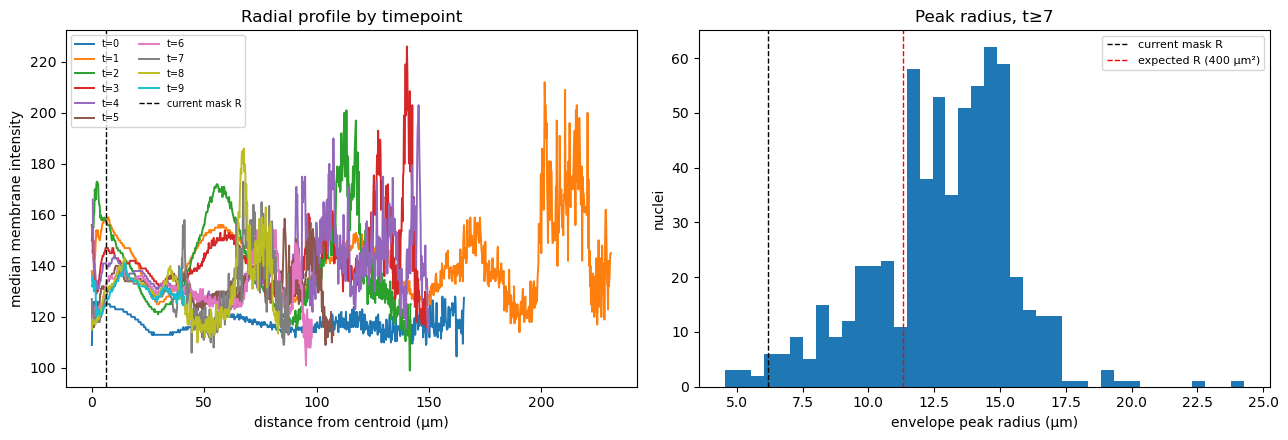

In [126]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for t, d in prof.groupby("t"):
    ax[0].plot(d.r_um, d["median"], label=f"t={t}", lw=1.4)
ax[0].axvline(6.2, ls="--", c="k", lw=1, label="current mask R")
ax[0].set_xlabel("distance from centroid (µm)")
ax[0].set_ylabel("median membrane intensity")
ax[0].set_title("Radial profile by timepoint")
ax[0].legend(fontsize=7, ncol=2)

late = peak[peak.t >= 7]
ax[1].hist(late.peak_r_um, bins=40)
ax[1].axvline(6.2, ls="--", c="k", lw=1, label="current mask R")
ax[1].axvline(11.3, ls="--", c="r", lw=1, label="expected R (400 µm²)")
ax[1].set_xlabel("envelope peak radius (µm)")
ax[1].set_ylabel("nuclei")
ax[1].set_title("Peak radius, t≥7")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [127]:
import numpy as np, pandas as pd, tifffile as tiff
from skimage import measure

drop = tiff.memmap(cfg.droplet_instance_hyperstack_path, mode="r")
plane = np.asarray(drop[9, 15])          # late t, in-focus z
d = pd.DataFrame(measure.regionprops_table(plane, properties=("area","equivalent_diameter")))
d = d[d.area > 1000]
med_px = d.equivalent_diameter.median()
print("droplet diameter (px):", round(med_px, 1))
print("droplet diameter (µm) @0.108:", round(med_px * cfg.pixel_size_um, 1))
print("implied px size if droplets are 65 µm:", round(65 / med_px, 4))


droplet diameter (px): 189.8
droplet diameter (µm) @0.108: 41.1
implied px size if droplets are 65 µm: 0.3425


In [128]:
import numpy as np, pandas as pd, tifffile as tiff
from skimage import measure

drop = tiff.memmap(cfg.droplet_instance_hyperstack_path, mode="r")
b = pd.read_pickle(cfg.obj_dir / "best_z_nuclei.pkl")

rows = []
for (t, z), grp in b[b.t >= 7].groupby(["t", "z"]):
    plane = np.asarray(drop[t, z])
    props = {r.label: r.area for r in measure.regionprops(plane)}
    for r in grp.itertuples():
        did = plane[int(r.centroid_y_px), int(r.centroid_x_px)]
        if did > 0 and props.get(did, 0) > 0:
            rows.append({"t": t, "nuc_px": r.area_px, "drop_px": props[did],
                         "ratio": r.area_px / props[did]})

d = pd.DataFrame(rows)
print("n nuclei matched:", len(d))
print("median droplet area (px):", round(float(d.drop_px.median())))
print("median droplet diameter (px):", round(float(2*np.sqrt(d.drop_px.median()/np.pi)), 1))
print("median nucleus/droplet area ratio:", round(float(d.ratio.median()), 4))

D_UM = 65.0   # <-- set to your actual RAN008 droplet diameter
diam_px = float(2*np.sqrt(d.drop_px.median()/np.pi))
print(f"\nif droplets are {D_UM} µm diameter -> nucleus area:",
      round(float(d.ratio.median()) * np.pi * (D_UM/2)**2, 1), "µm²")
print("implied pixel size:", round(D_UM / diam_px, 4), "µm/px")

n nuclei matched: 629
median droplet area (px): 31197
median droplet diameter (px): 199.3
median nucleus/droplet area ratio: 0.2722

if droplets are 65.0 µm diameter -> nucleus area: 903.3 µm²
implied pixel size: 0.3261 µm/px


## 36. Load saved mask hyperstacks for QC

In [35]:
class_mask_5d       = tiff.imread(cfg.segmentation_class_hyperstack_path)
label_mask_4d       = tiff.imread(cfg.segmentation_label_hyperstack_path)
nucleus_instance_4d = tiff.imread(cfg.nucleus_instance_hyperstack_path)

print(f"class_mask_5d shape:       {class_mask_5d.shape}")
print(f"label_mask_4d shape:       {label_mask_4d.shape}")
print(f"nucleus_instance_4d shape: {nucleus_instance_4d.shape}")

nucleus_mask_4d = class_mask_5d[:, :, cfg.nucleus_class_index] > 0
print(f"nucleus_mask_4d shape:     {nucleus_mask_4d.shape}")


class_mask_5d shape:       (10, 20, 4, 3889, 5732)
label_mask_4d shape:       (10, 20, 3889, 5732)
nucleus_instance_4d shape: (10, 20, 3889, 5732)
nucleus_mask_4d shape:     (10, 20, 3889, 5732)


## 37. QC plots

In [129]:
plot_nucleus_mask_overlay_qc(img_5d, nucleus_mask_4d, cfg, z_mode="max_mask")
plot_nucleus_mask_qc_summary(nucleus_mask_4d, z_mode="max_mask")
plot_nucleus_count_over_time(nucleus_mask_4d)


NameError: name 'nucleus_mask_4d' is not defined

## 38. Downstream measurement plots

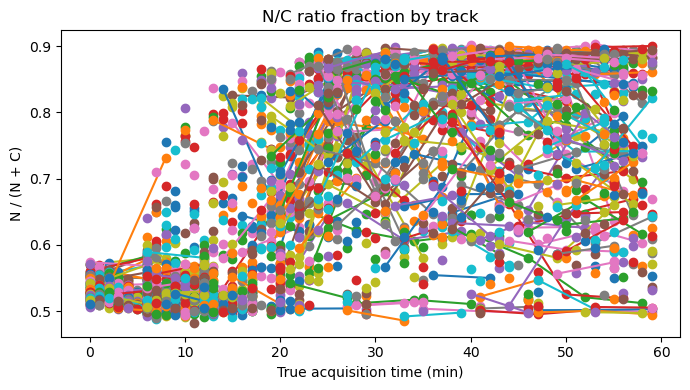

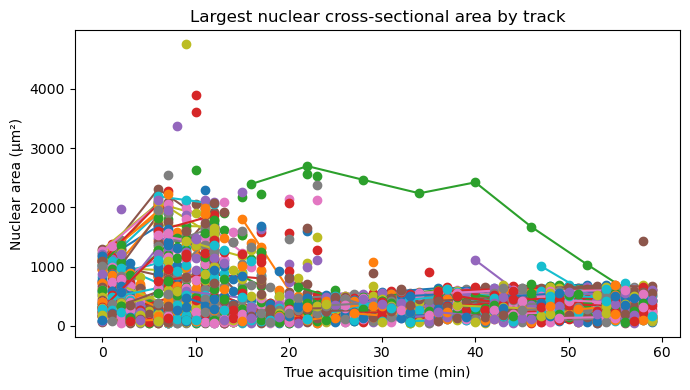

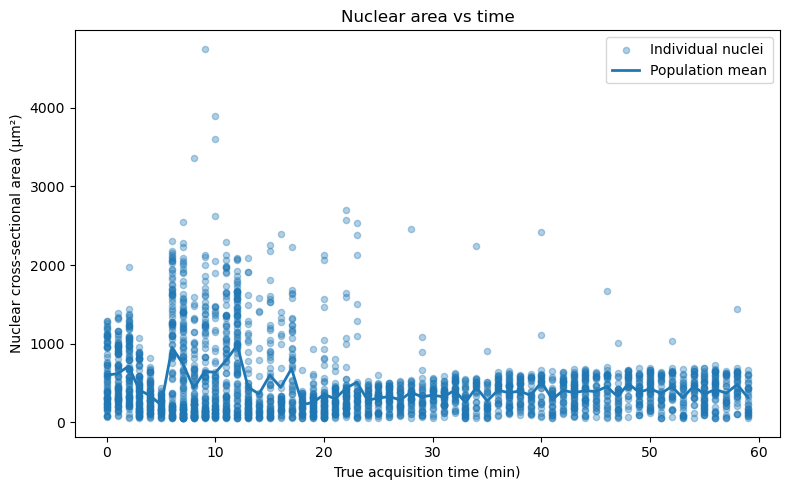

In [130]:
plot_nc_vs_time(halo_df)
plot_area_vs_time(halo_df)
plot_largest_cross_sectional_area_vs_time(timed_df, cfg)


## 39. Probability-map debug on the selected plane

In [52]:
if "debug_prob_map" in dir():
    raw_plane = img_5d[DEBUG_T_IDX, DEBUG_Z_IDX, cfg.nuclear_channel_index]
    plot_nucleus_probability_qc(debug_prob_map, raw_plane,
                                title=f"t={DEBUG_T_IDX}, z={DEBUG_Z_IDX}")
else:
    print("Run Section 26 (single-plane debug) first.")


Run Section 26 (single-plane debug) first.


## 40. Pipeline summary

In [131]:
summary_df = pd.DataFrame([{
    "seg_index_rows": len(seg_index_df),
    "objects_rows":   len(objects_df),
    "grouped_z_rows": len(grouped_z_df),
    "best_z_rows":    len(best_z_df),
    "filtered_rows":  len(filtered_df),
    "timed_rows":     len(timed_df),
    "tracked_rows":   len(tracked_df),
    "halo_rows":      len(halo_df),
}])
display(summary_df)


,seg_index_rows,objects_rows,grouped_z_rows,best_z_rows,filtered_rows,timed_rows,tracked_rows,halo_rows
0,200,4140,4140,2913,2913,2913,2913,2913


## 41. Export portable analysis bundle

In [132]:
if RUN_EXPORT_PORTABLE:
    portable_dir = cfg.output_dir / "portable_laptop_bundle"
    exported_path = export_portable_analysis_bundle(
        config=cfg,
        export_dir=portable_dir,
        seg_index_df=seg_index_df,
        objects_df=objects_df,
        grouped_z_df=grouped_z_df,
        best_z_df=best_z_df,
        filtered_df=filtered_df,
        timed_df=timed_df,
        tracked_df=tracked_df,
        halo_df=halo_df,
        copy_mask_npy_files=False,
    )
    print(f"Portable bundle written to: {exported_path}")


Portable bundle written to: /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d/portable_laptop_bundle


## 42. (Optional) Inspect probability TIFF

In [55]:
prob_tiff_path = cfg.segmentation_probability_hyperstack_path
if prob_tiff_path.exists():
    prob_hyperstack = tiff.imread(prob_tiff_path)
    print(f"Shape: {prob_hyperstack.shape}  |  dtype: {prob_hyperstack.dtype}")
    print(f"Range: {float(np.nanmin(prob_hyperstack)):.4f} – {float(np.nanmax(prob_hyperstack)):.4f}")
else:
    print(f"Probability TIFF not found yet: {prob_tiff_path}")


Shape: (10, 20, 4, 3889, 5732)  |  dtype: float16
Range: 0.0000 – 1.0000


In [56]:
# ── Plot probability hyperstack QC ───────────────────────────────────────────

prob_path = cfg.segmentation_probability_hyperstack_path
assert prob_path.exists(), f"Probability TIFF not found: {prob_path}"

prob = tiff.imread(prob_path).astype(np.float32)
# Shape: (T, Z, C, Y, X)  C=0 background, C=1 droplet, C=2 nucleus
print(f"Probability hyperstack shape: {prob.shape}  dtype: {prob.dtype}")
print(f"Value range: {prob.min():.4f} – {prob.max():.4f}")

T, Z, C, Y, X = prob.shape
class_names  = {0: "Background", 1: "Droplet", 2: "NPC", 3: "Nucleus"}
class_cmaps  = {0: "gray",       1: "Blues",   2: "Purples", 3: "Greens"}

# ── Controls — edit these ─────────────────────────────────────────────────────
PLOT_TIMEPOINTS = list(range(min(T, 9)))   # first 5 timepoints
PLOT_CLASS      = 2                       # 0=background 1=droplet 2=nucleus
# Use best-focus Z for each timepoint (from focus_data if available,
# otherwise the Z with the highest mean probability for the chosen class)
# ─────────────────────────────────────────────────────────────────────────────

def _best_z_for_prob(prob_tzyx, class_idx):
    """Return the Z index with the highest mean probability for this class."""
    return int(prob_tzyx[:, class_idx].reshape(prob_tzyx.shape[0], -1).mean(axis=1).argmax())

n_cols = min(5, len(PLOT_TIMEPOINTS))
n_rows = (len(PLOT_TIMEPOINTS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols, 4 * n_rows),
                         squeeze=False)

for idx, t in enumerate(PLOT_TIMEPOINTS):
    ax = axes[idx // n_cols][idx % n_cols]

    # Pick best Z for this timepoint and class
    try:
        best_z = focus_data[t][2]   # from focus pre-computation in seg loop
        if best_z is None:
            raise ValueError
    except Exception:
        best_z = _best_z_for_prob(prob[t], PLOT_CLASS)

    plane = prob[t, best_z, PLOT_CLASS]   # (Y, X)

    im = ax.imshow(plane, cmap=class_cmaps[PLOT_CLASS], vmin=0, vmax=1,
                   interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(f"t={t}  z={best_z}\n{class_names[PLOT_CLASS]} prob", fontsize=9)
    ax.axis("off")

# Hide unused panels
for idx in range(len(PLOT_TIMEPOINTS), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

fig.suptitle(
    f"Segmentation probability — {class_names[PLOT_CLASS]} channel\n"
    f"Shape: {prob.shape}  |  path: {prob_path.name}",
    fontsize=11)
plt.tight_layout()
plt.show()

# ── Optional: show all 3 classes side by side for one timepoint ──────────────
T_INSPECT = 9  # inspect latest timepoint with fully assembled nuclei   # which timepoint to inspect in detail

try:
    z_inspect = focus_data[T_INSPECT][2] or _best_z_for_prob(prob[T_INSPECT], 2)
except Exception:
    z_inspect = _best_z_for_prob(prob[T_INSPECT], 2)

fig2, axes2 = plt.subplots(1, cfg.num_classes, figsize=(5 * cfg.num_classes, 5))
for c_idx, ax in enumerate(axes2):
    plane = prob[T_INSPECT, z_inspect, c_idx]
    im = ax.imshow(plane, cmap=class_cmaps[c_idx], vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(f"{class_names[c_idx]}\nt={T_INSPECT}  z={z_inspect}", fontsize=10)
    ax.axis("off")

fig2.suptitle("All three probability channels — single timepoint", fontsize=12)
plt.tight_layout()
plt.show()

del prob   # free the ~several GB array after plotting

: 

: 

: 

## 43. Notes

- Every major stage is exposed as its own runnable block — there is no monolithic wrapper.
- Intermediate tables are written to disk so you can rerun only the stage being debugged.
- Set `RUN_EXPORT_PORTABLE = True` before the final cell to bundle TIFFs + CSVs for local laptop analysis.


In [1]:
g = pd.read_pickle(cfg.obj_dir / "grouped_z_objects.pkl")
b = pd.read_pickle(cfg.obj_dir / "best_z_nuclei.pkl")

edge = g.groupby(["t","nucleus_3d_id"])["z"].agg(["min","max"])
m = b.set_index(["t","nucleus_3d_id"]).join(edge)
m["at_edge"] = (m.z == m["min"]) | (m.z == m["max"])
print(m.groupby(level="t")["at_edge"].mean())      # fraction truncated, by t
print(b.groupby("t")["z"].value_counts().unstack())  # is z pinned to one plane?

# per-tile focus check
print(b.groupby(["t","tile_index"])["area_px"].median().unstack() * cfg.pixel_size_um**2)

NameError: name 'pd' is not defined

## 44. Export tables to database schema (for ggplot / SQLite)

Reshapes the pipeline's existing dataframes (`halo_df`, `grouped_z_df`, `best_z_df`, `cfg`) into the five-table schema (`Nuclei`, `NucleusZStack`, `RawIntensities`, `RadialProfile`, `Experimental_Cfg`) and writes them as CSVs.

**Known gaps carried over from the current pipeline (not fixed here — see notes):**
- `RawIntensities` halo columns are populated for the Mcherry/NLS channel only. `measure_fiji_equivalent_halos` (Section 18) is only ever called on `get_nuclear_plane`, so `Halo*_NPC` and `Halo*_Membrane` columns are written as `NaN` placeholders. Re-run `run_halo_analysis_for_tracked_nuclei` once per channel to fill these in.
- `Background_*` columns are `NaN` placeholders — `measure_fiji_equivalent_halos` does not currently compute a background ROI.
- `RadialProfile` is now populated by the Section 35b droplet-bounded radial sweep (membrane channel). `W_Wall_Proximity_Index`, `Is_Ridge_Point`, and `Cluster_ID` remain placeholders until ridge/wall-index analysis is added.
- `Volume_3D_um3` and `Stage_Classification` are not computed by this pipeline (2D best-Z only, no stage classifier) — written as `NaN`/blank.
- `Droplet_ID` is not tracked as a distinct ID by this pipeline (only a boolean multi-nucleus exclusion flag exists) — written blank.
- `FOV_ID` defaults to a single placeholder (`"FOV01"`) since this pipeline processes one stitched image per run, not multiple discrete FOVs.


In [133]:
PIPELINE_VERSION = "v16.2"  # matches this notebook; bump manually per release
DB_EXPORT_DIR = cfg.output_dir / "database_export"
DB_EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _fmt_slice_id(z: int) -> str:
    """Match the S#### convention used in the schema workbook."""
    return f"S{int(z):04d}"


def _fmt_centroid_xyz(x: float, y: float, z: float) -> str:
    return f"({x:.1f}, {y:.1f}, {z:.1f})"


In [134]:
def build_nuclei_table(halo_df: pd.DataFrame, cfg: PipelineConfig) -> pd.DataFrame:
    """One row per Nucleus_ID (track_id) per Time_Frame — analysis-ready table."""
    if halo_df.empty:
        return pd.DataFrame(columns=[
            "Nucleus_ID", "Droplet_ID", "FOV_ID", "Experiment_ID",
            "Time_Frame", "Time_Real_Minutes", "Stage_Classification",
            "Selected_Slice_ID", "Centroid_XYZ_px",
            "Cross_Sectional_Area_um2", "Volume_3D_um3", "NC_Ratio",
            "Segmentation_Pipeline_Version", "Model_Version",
            "QC_Flag", "QC_Notes", "Source_File_Path",
        ])

    experiment_id = Path(cfg.input_image_name).stem
    rows = []
    for row in halo_df.itertuples(index=False):
        qc_pass = bool(getattr(row, "valid_single_nucleus", True))
        rows.append({
            "Nucleus_ID":                    int(row.track_id),
            "Droplet_ID":                    "",  # not tracked as a distinct ID by this pipeline
            "FOV_ID":                        "FOV01",  # single stitched image per run
            "Experiment_ID":                 experiment_id,
            "Time_Frame":                    int(row.t),
            "Time_Real_Minutes":             float(getattr(row, "true_time_min", np.nan)),
            "Stage_Classification":          "",  # not computed by this pipeline
            "Selected_Slice_ID":             _fmt_slice_id(row.z),
            "Centroid_XYZ_px":               _fmt_centroid_xyz(row.centroid_x_px, row.centroid_y_px, row.z),
            "Cross_Sectional_Area_um2":      float(getattr(row, "nucleus_area_um2", np.nan)),
            "Volume_3D_um3":                 np.nan,  # 2D best-Z pipeline only
            "NC_Ratio":                      float(getattr(row, "nc_ratio", np.nan)),
            "Segmentation_Pipeline_Version": PIPELINE_VERSION,
            "Model_Version":                 cfg.model_name,
            "QC_Flag":                       "PASS" if qc_pass else "FAIL",
            "QC_Notes":                      "" if qc_pass else "excluded: multiple nuclei within exclusion radius",
            "Source_File_Path":              cfg.input_image_name,
        })
    return pd.DataFrame(rows)


nuclei_export_df = build_nuclei_table(halo_df, cfg)
print(nuclei_export_df.shape)
display(nuclei_export_df.head())


(2913, 17)


,Nucleus_ID,Droplet_ID,FOV_ID,Experiment_ID,Time_Frame,Time_Real_Minutes,Stage_Classification,Selected_Slice_ID,Centroid_XYZ_px,Cross_Sectional_Area_um2,Volume_3D_um3,NC_Ratio,Segmentation_Pipeline_Version,Model_Version,QC_Flag,QC_Notes,Source_File_Path
0,1,,FOV01,control_extract_1.1,0,0.0,,S0015,"(1665.0, 78.2, 15.0)",962.704204,NaN,1.151285,v16,unet_nuclear_scaling_v9_best.keras,PASS,,control_extract_1.1.tif
1,2,,FOV01,control_extract_1.1,0,1.0,,S0015,"(2712.6, 82.0, 15.0)",587.408755,NaN,1.121597,v16,unet_nuclear_scaling_v9_best.keras,PASS,,control_extract_1.1.tif
2,3,,FOV01,control_extract_1.1,0,2.0,,S0015,"(4017.5, 68.6, 15.0)",975.289186,NaN,1.214078,v16,unet_nuclear_scaling_v9_best.keras,PASS,,control_extract_1.1.tif
3,4,,FOV01,control_extract_1.1,0,2.0,,S0015,"(4286.6, 103.6, 15.0)",1069.582638,NaN,1.186610,v16,unet_nuclear_scaling_v9_best.keras,PASS,,control_extract_1.1.tif
4,5,,FOV01,control_extract_1.1,0,1.0,,S0015,"(2979.5, 118.1, 15.0)",980.689459,NaN,1.153326,v16,unet_nuclear_scaling_v9_best.keras,PASS,,control_extract_1.1.tif


In [135]:
def build_zstack_table(grouped_z_df: pd.DataFrame, best_z_df: pd.DataFrame,
                       tracked_df: pd.DataFrame, cfg: PipelineConfig) -> pd.DataFrame:
    """One row per Z-plane per nucleus per timepoint — full sweep behind the best-Z pick."""
    cols = ["Nucleus_ID", "Time_Frame", "Slice_ID", "Centroid_XYZ_px",
            "Cross_Sectional_Area_um2", "Is_Selected_Max"]
    if grouped_z_df.empty or best_z_df.empty or tracked_df.empty:
        return pd.DataFrame(columns=cols)

    track_lookup = tracked_df[["t", "nucleus_3d_id", "track_id"]].drop_duplicates()
    best_z_lookup = best_z_df[["t", "nucleus_3d_id", "z"]].rename(columns={"z": "best_z"})

    merged = grouped_z_df.merge(track_lookup, on=["t", "nucleus_3d_id"], how="inner")
    merged = merged.merge(best_z_lookup, on=["t", "nucleus_3d_id"], how="left")

    rows = []
    for row in merged.itertuples(index=False):
        area_um2 = float(row.area_px) * (cfg.pixel_size_um ** 2)
        rows.append({
            "Nucleus_ID":               int(row.track_id),
            "Time_Frame":               int(row.t),
            "Slice_ID":                 _fmt_slice_id(row.z),
            "Centroid_XYZ_px":          _fmt_centroid_xyz(row.centroid_x_px, row.centroid_y_px, row.z),
            "Cross_Sectional_Area_um2": area_um2,
            "Is_Selected_Max":          bool(row.z == row.best_z),
        })
    return pd.DataFrame(rows, columns=cols)


zstack_export_df = build_zstack_table(grouped_z_df, best_z_df, tracked_df, cfg)
print(zstack_export_df.shape)
display(zstack_export_df.head())


(4140, 6)


,Nucleus_ID,Time_Frame,Slice_ID,Centroid_XYZ_px,Cross_Sectional_Area_um2,Is_Selected_Max
0,1,0,S0015,"(1665.0, 78.2, 15.0)",962.704204,True
1,2,0,S0015,"(2712.6, 82.0, 15.0)",587.408755,True
2,3,0,S0015,"(4017.5, 68.6, 15.0)",975.289186,True
3,4,0,S0015,"(4286.6, 103.6, 15.0)",1069.582638,True
4,5,0,S0015,"(2979.5, 118.1, 15.0)",980.689459,True


In [136]:
def build_raw_intensities_table(halo_df: pd.DataFrame, cfg: PipelineConfig) -> pd.DataFrame:
    """Per-halo, per-channel integrated intensities at the selected Z-slice.

    NOTE: only the Mcherry/NLS channel is currently measured by
    measure_fiji_equivalent_halos (Section 18). NPC and Membrane columns,
    and all Background_* columns, are written as NaN until that function
    is extended to loop over channels.
    """
    cols = [
        "Nucleus_ID", "Time_Frame",
        "Halo1_Mcherry", "Halo2_Mcherry", "Halo3_Mcherry", "Halo4_Mcherry",
        "Halo1_NPC", "Halo2_NPC", "Halo3_NPC", "Halo4_NPC",
        "Halo1_Membrane", "Halo2_Membrane", "Halo3_Membrane", "Halo4_Membrane",
        "Background_Mcherry", "Background_NPC", "Background_Membrane",
    ]
    if halo_df.empty:
        return pd.DataFrame(columns=cols)

    rows = []
    for row in halo_df.itertuples(index=False):
        rd = row._asdict()
        rec = {
            "Nucleus_ID": int(rd["track_id"]),
            "Time_Frame": int(rd["t"]),
        }
        for i in range(1, cfg.n_halos + 1):
            rec[f"Halo{i}_Mcherry"] = rd.get(f"ring_{i}_intden", np.nan)
            rec[f"Halo{i}_NPC"] = np.nan       # not measured yet — see docstring
            rec[f"Halo{i}_Membrane"] = np.nan  # not measured yet — see docstring
        rec["Background_Mcherry"] = np.nan
        rec["Background_NPC"] = np.nan
        rec["Background_Membrane"] = np.nan
        rows.append(rec)
    return pd.DataFrame(rows, columns=cols)


raw_intensities_export_df = build_raw_intensities_table(halo_df, cfg)
print(raw_intensities_export_df.shape)
display(raw_intensities_export_df.head())


(2913, 17)


,Nucleus_ID,Time_Frame,Halo1_Mcherry,Halo2_Mcherry,Halo3_Mcherry,Halo4_Mcherry,Halo1_NPC,Halo2_NPC,Halo3_NPC,Halo4_NPC,Halo1_Membrane,Halo2_Membrane,Halo3_Membrane,Halo4_Membrane,Background_Mcherry,Background_NPC,Background_Membrane
0,1,0,496016.0,504877.0,487740.0,482788.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,512381.0,517512.0,473075.0,484659.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,0,416530.0,420714.0,411019.0,412916.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,616463.0,621234.0,590292.0,587653.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,564882.0,580707.0,568209.0,587820.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [137]:
def build_radial_profile_table(radial_df: pd.DataFrame, cfg: PipelineConfig) -> pd.DataFrame:
    """Long-form radial sweep -> schema RadialProfile (one row per ray sample point).

    W_Wall_Proximity_Index, Is_Ridge_Point, and Cluster_ID are written as
    placeholders (NaN / False / blank) -- wall-proximity index and ridge/DBSCAN
    clustering are not computed in v16.
    """
    cols = [
        "Nucleus_ID", "Time_Frame", "Theta_deg", "Rho_Normalized",
        "W_Wall_Proximity_Index", "Channel", "Intensity",
        "Is_Ridge_Point", "Cluster_ID",
    ]
    if radial_df is None or radial_df.empty:
        return pd.DataFrame(columns=cols)

    channel_label_by_index = {
        cfg.membrane_channel_index: "Membrane",
        cfg.nuclear_channel_index:  "Mcherry",
        cfg.npc_channel_index:      "NPC",
    }
    radial_channel_label = channel_label_by_index.get(cfg.radial_channel_index, "Membrane")

    out = pd.DataFrame({
        "Nucleus_ID":             radial_df["track_id"].astype(int),
        "Time_Frame":             radial_df["t"].astype(int),
        "Theta_deg":              np.degrees(radial_df["theta_rad"].astype(float)),
        "Rho_Normalized":         radial_df["distance_norm"].astype(float),
        "W_Wall_Proximity_Index": np.nan,
        "Channel":                radial_channel_label,
        "Intensity":              radial_df["intensity"].astype(float),
        "Is_Ridge_Point":         False,
        "Cluster_ID":             "",
    })
    return out[cols]


radial_profile_export_df = build_radial_profile_table(radial_df, cfg)
print(radial_profile_export_df.shape)
display(radial_profile_export_df.head())


(23423170, 9)


,Nucleus_ID,Time_Frame,Theta_deg,Rho_Normalized,W_Wall_Proximity_Index,Channel,Intensity,Is_Ridge_Point,Cluster_ID
0,1,0,0.0,0.782609,NaN,Membrane,120.0,False,
1,1,0,0.0,0.791304,NaN,Membrane,120.0,False,
2,1,0,0.0,0.800000,NaN,Membrane,145.0,False,
3,1,0,0.0,0.808696,NaN,Membrane,131.0,False,
4,1,0,0.0,0.817391,NaN,Membrane,143.0,False,


In [138]:
def build_experimental_cfg_table(cfg: PipelineConfig) -> pd.DataFrame:
    experiment_id = Path(cfg.input_image_name).stem
    channel_labels = {0: "Membrane", 1: "NLS", 2: "NPC"}
    row = {
        "Experiment_ID":                 experiment_id,
        "FOV_ID":                        "FOV01",
        "Droplet_ID":                    "",
        "Date":                          datetime.utcnow().strftime("%Y-%m-%d"),
        "Pixel_Size_um":                 cfg.pixel_size_um,
        "Z_Step_um":                     cfg.z_step_um,
        "Num_Z_Planes":                  int(img_5d.shape[1]) if "img_5d" in dir() else np.nan,
        "Frame_Interval_min":            cfg.minutes_per_tile * cfg.tile_rows * cfg.tile_cols,
        "Channel0_Label":                channel_labels.get(0, ""),
        "Channel1_Label":                channel_labels.get(1, ""),
        "Channel2_Label":                channel_labels.get(2, ""),
        "Microscope":                    "",
        "Objective":                     "",
        "Operator":                      "",
        "Segmentation_Pipeline_Version": PIPELINE_VERSION,
        "Model_Version":                 cfg.model_name,
        "Raw_File_Path":                 str(cfg.input_image_path),
        "Notes":                         "",
    }
    return pd.DataFrame([row])


experimental_cfg_export_df = build_experimental_cfg_table(cfg)
display(experimental_cfg_export_df)


,Experiment_ID,FOV_ID,Droplet_ID,Date,Pixel_Size_um,Z_Step_um,Num_Z_Planes,Frame_Interval_min,Channel0_Label,Channel1_Label,Channel2_Label,Microscope,Objective,Operator,Segmentation_Pipeline_Version,Model_Version,Raw_File_Path,Notes
0,control_extract_1.1,FOV01,,2026-07-22,0.2167,1.0,NaN,6.0,Membrane,NLS,NPC,,,,v16,unet_nuclear_scaling_v9_best.keras,/data/user/tdeibert/Nuclear_Scaling/Inputs/Raw...,


In [139]:
def export_database_schema_tables(export_dir: Path) -> dict:
    tables = {
        "Nuclei":            nuclei_export_df,
        "NucleusZStack":     zstack_export_df,
        "RawIntensities":    raw_intensities_export_df,
        "RadialProfile":     radial_profile_export_df,
        "Experimental_Cfg":  experimental_cfg_export_df,
    }
    written = {}
    for name, df in tables.items():
        out_path = export_dir / f"{name}.csv"
        df.to_csv(out_path, index=False)
        written[name] = str(out_path)
        print(f"{name}: {len(df)} rows -> {out_path}")
    return written


RUN_DB_SCHEMA_EXPORT = True

if RUN_DB_SCHEMA_EXPORT:
    written_paths = export_database_schema_tables(DB_EXPORT_DIR)


Nuclei: 2913 rows -> /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d/database_export/Nuclei.csv
NucleusZStack: 4140 rows -> /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d/database_export/NucleusZStack.csv
RawIntensities: 2913 rows -> /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d/database_export/RawIntensities.csv
RadialProfile: 23423170 rows -> /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d/database_export/RadialProfile.csv
Experimental_Cfg: 1 rows -> /data/user/tdeibert/Nuclear_Scaling/Runs/control_extract_1.1__cfg-35f03b5d/database_export/Experimental_Cfg.csv


In [140]:
r = (d.assign(frac=d.nuc_px/d.drop_px)
       .groupby("t")["frac"]
       .describe(percentiles=[.5,.9,.95,.99])[["50%","90%","95%","99%","max"]])
print(r.round(3))

     50%    90%    95%    99%    max
t                                   
7  0.257  0.483  0.583  0.642  0.668
8  0.271  0.465  0.578  0.677  0.756
9  0.287  0.546  0.614  0.721  0.737


In [141]:
rows = []
for (t, z), grp in b.groupby(["t", "z"]):          # drop the t>=7 filter
    plane = np.asarray(drop[t, z])
    props = {r.label: r.area for r in measure.regionprops(plane)}
    for r in grp.itertuples():
        did = plane[int(r.centroid_y_px), int(r.centroid_x_px)]
        rows.append({"t": t, "nuc_px": r.area_px,
                     "drop_px": props.get(did, np.nan),
                     "assigned": did > 0})
dall = pd.DataFrame(rows)
dall["frac"] = dall.nuc_px / dall.drop_px
print(dall.groupby("t")["frac"].describe(percentiles=[.5,.9,.95,.99])[["50%","90%","95%","99%","max"]].round(3))
print("\nunassigned (droplet_id=0) by t:")
print(dall.groupby("t")["assigned"].apply(lambda s: 1 - s.mean()).round(3))

     50%    90%    95%    99%    max
t                                   
0  0.467  0.655  0.691  0.749  0.813
1  0.090  0.397  0.486  0.655  0.780
2  0.229  0.601  0.656  0.743  0.766
3  0.136  0.317  0.437  0.586  0.892
4  0.155  0.276  0.393  0.564  0.759
5  0.204  0.430  0.541  0.693  0.711
6  0.217  0.426  0.492  0.684  0.770
7  0.257  0.483  0.583  0.642  0.668
8  0.271  0.465  0.578  0.677  0.756
9  0.287  0.546  0.614  0.721  0.737

unassigned (droplet_id=0) by t:
t
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: assigned, dtype: float64


In [142]:
print(dall.groupby("t")["drop_px"].median().round(0))
print(dall.groupby("t")["nuc_px"].median().round(0))
print(b.groupby("t")["z"].median())

t
0    31664.0
1    89955.0
2    39668.0
3    44673.0
4    49250.0
5    34896.0
6    42217.0
7    31307.0
8    34236.0
9    27824.0
Name: drop_px, dtype: float64
t
0    8530.0
1    9617.0
2    8407.0
3    5467.0
4    6796.0
5    7196.0
6    8354.0
7    8469.0
8    9162.0
9    8804.0
Name: nuc_px, dtype: float64
t
0    15.0
1     9.0
2    12.0
3     9.0
4    12.0
5    14.0
6    13.0
7    15.0
8    15.0
9    16.0
Name: z, dtype: float64


In [143]:
import pandas as pd

tm = pd.read_pickle(cfg.track_dir / "best_z_nuclei_timed.pkl")
tm["area_um2"] = tm.area_px * cfg.pixel_size_um**2

EARLY_MIN, EARLY_MAX = 50.0, 200.0     # true_time_min <= 20
LATE_MIN,  LATE_MAX  = 200.0, 500.0    # true_time_min >  20

early = tm.true_time_min <= 20
keep = ((early  & tm.area_um2.between(EARLY_MIN, EARLY_MAX)) |
        (~early & tm.area_um2.between(LATE_MIN,  LATE_MAX)))

tm_f = tm[keep].copy()
tm_f.to_pickle(cfg.track_dir / "best_z_nuclei_timed_filtered.pkl")

print(f"kept {len(tm_f)} / {len(tm)}  ({100*len(tm_f)/len(tm):.1f}%)")
print("\nretained by frame:")
print(pd.DataFrame({"before": tm.groupby("t").size(),
                    "after":  tm_f.groupby("t").size()}).fillna(0).astype(int))
print("\nmedian area µm² after filter:")
print(tm_f.groupby("t")["area_um2"].median().round(1))

kept 1223 / 2913  (42.0%)

retained by frame:
   before  after
t               
0     456     93
1     555    195
2     335    101
3     297    147
4     229    161
5     206    124
6     206    110
7     216    106
8     201     93
9     212     93

median area µm² after filter:
t
0    134.6
1    103.8
2    120.7
3    209.4
4    346.7
5    356.2
6    365.6
7    366.7
8    360.8
9    367.0
Name: area_um2, dtype: float64


kept 1223 / 2913 (42.0%)
   before  after
t               
0     456     93
1     555    195
2     335    101
3     297    147
4     229    161
5     206    124
6     206    110
7     216    106
8     201     93
9     212     93


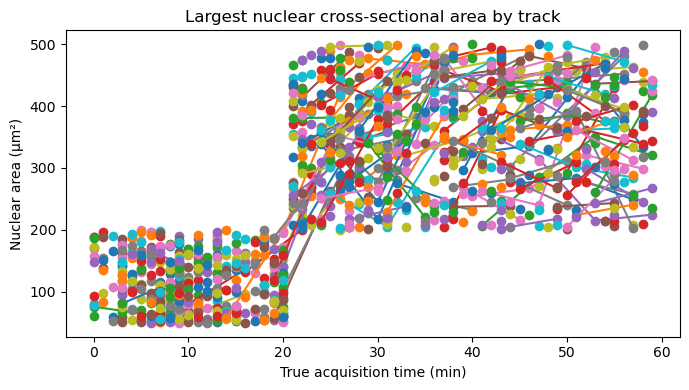

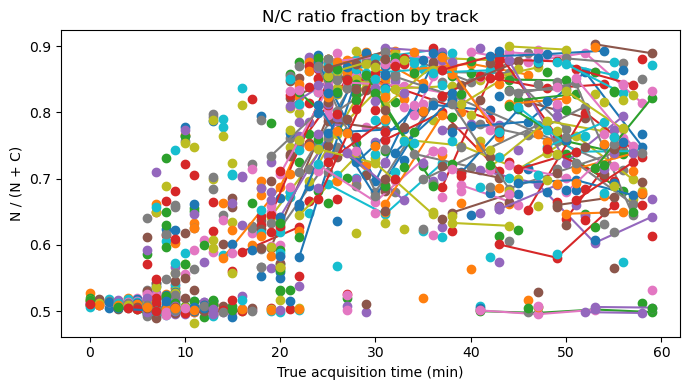

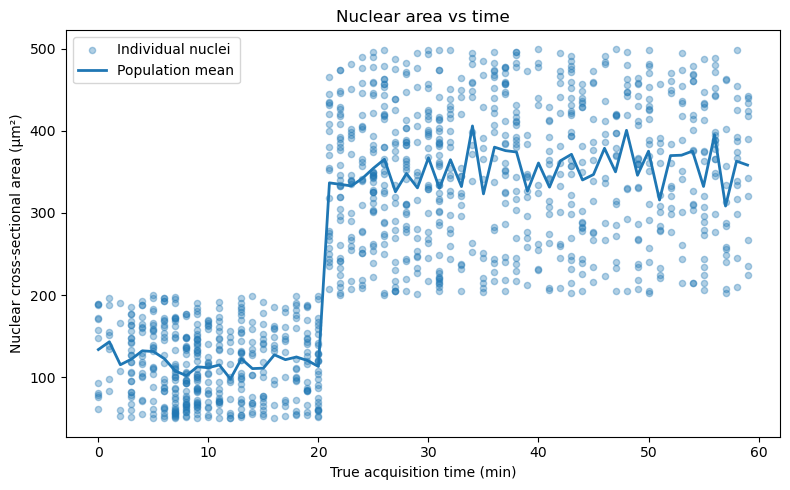

In [144]:
import pandas as pd

halo_df = pd.read_pickle(cfg.analysis_dir / "halo_analysis.pkl")

# recompute area from px so it always reflects the current calibration
if "nucleus_area_px" in halo_df.columns:
    halo_df["nucleus_area_um2"] = halo_df.nucleus_area_px * cfg.pixel_size_um**2

early = halo_df.true_time_min <= 20
keep = ((early  & halo_df.nucleus_area_um2.between(50, 200)) |
        (~early & halo_df.nucleus_area_um2.between(200, 500)))
hf = halo_df[keep].copy()

print(f"kept {len(hf)} / {len(halo_df)} ({100*len(hf)/len(halo_df):.1f}%)")
print(pd.DataFrame({"before": halo_df.groupby("t").size(),
                    "after":  hf.groupby("t").size()}).fillna(0).astype(int))

plot_area_vs_time(hf)
plot_nc_vs_time(hf)
plot_largest_cross_sectional_area_vs_time(hf, cfg)

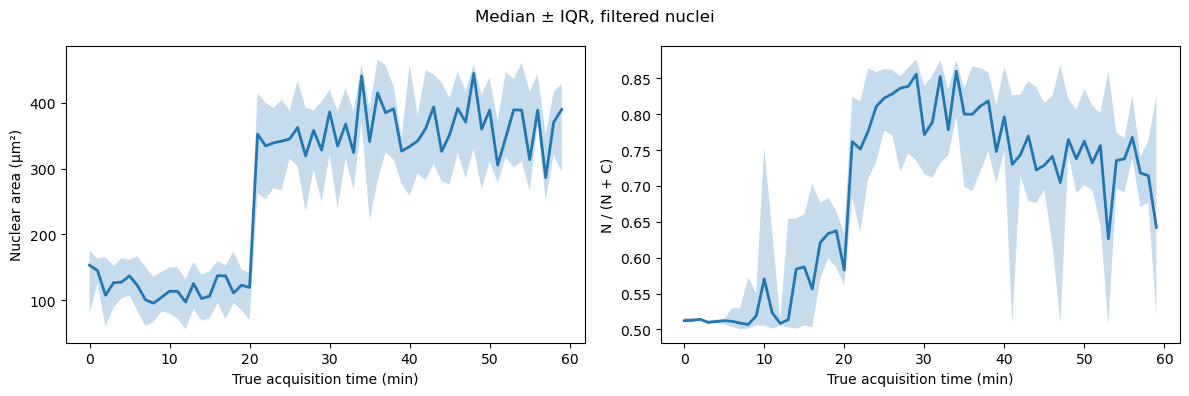

In [145]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, col, lab in [(ax[0], "nucleus_area_um2", "Nuclear area (µm²)"),
                    (ax[1], "nc_ratio_fraction", "N / (N + C)")]:
    g = hf.groupby("true_time_min")[col]
    med, lo, hi = g.median(), g.quantile(.25), g.quantile(.75)
    a.fill_between(med.index, lo, hi, alpha=.25)
    a.plot(med.index, med, lw=2)
    a.set_xlabel("True acquisition time (min)"); a.set_ylabel(lab)
a.figure.suptitle("Median ± IQR, filtered nuclei"); plt.tight_layout(); plt.show()

In [146]:
import pandas as pd

# nuclei per frame and per true acquisition minute
counts = pd.DataFrame({
    "rows":          hf.groupby("t").size(),
    "unique_tracks": hf.groupby("t")["track_id"].nunique(),
    "unique_droplets": hf.groupby("t")["droplet_id"].nunique() if "droplet_id" in hf else None,
}).fillna(0).astype(int)
counts["dupes"] = counts["rows"] - counts["unique_tracks"]
print(counts)

print("\nper true acquisition minute:")
print(hf.groupby("true_time_min")["track_id"].nunique())

# how persistent are tracks across the timecourse?
span = hf.groupby("track_id")["t"].nunique()
print("\ntimepoints per track:")
print(span.value_counts().sort_index())
print(f"\ntotal unique nuclei (any t): {hf.track_id.nunique()}")
print(f"tracks present at all 10 t:   {(span == hf.t.nunique()).sum()}")

   rows  unique_tracks  unique_droplets  dupes
t                                             
0    93             93                0      0
1   195            195                0      0
2   101            101                0      0
3   147            147                0      0
4   161            161                0      0
5   124            124                0      0
6   110            110                0      0
7   106            106                0      0
8    93             93                0      0
9    93             93                0      0

per true acquisition minute:
true_time_min
0.0     12
1.0      8
2.0      5
3.0     27
4.0     18
5.0     23
6.0     26
7.0     40
8.0     39
9.0     43
10.0    23
11.0    24
12.0    13
13.0    30
14.0    15
15.0    19
16.0    12
17.0    12
18.0    18
19.0    22
20.0    29
21.0    23
22.0    35
23.0    20
24.0    23
25.0    35
26.0    32
27.0    23
28.0    30
29.0    18
30.0    24
31.0    39
32.0    20
33.0    15
34.0    13
35.0   

/scratch/local/ipykernel_125525/3936699006.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }).fillna(0).astype(int)


In [147]:
import numpy as np, tifffile as tiff
from skimage import measure
drop = tiff.memmap(cfg.droplet_instance_hyperstack_path, mode="r")
for t in range(drop.shape[0]):
    z = int(hf[hf.t == t]["z"].median()) if (hf.t == t).any() else drop.shape[1]//2
    n = len([r for r in measure.regionprops(np.asarray(drop[t, z])) if r.area > 5000])
    print(f"t={t}  droplets={n:4d}  nuclei_kept={int((hf.t==t).sum()):4d}")

t=0  droplets= 154  nuclei_kept=  93
t=1  droplets= 136  nuclei_kept= 195
t=2  droplets= 124  nuclei_kept= 101
t=3  droplets= 132  nuclei_kept= 147
t=4  droplets= 145  nuclei_kept= 161
t=5  droplets= 137  nuclei_kept= 124
t=6  droplets= 130  nuclei_kept= 110
t=7  droplets= 139  nuclei_kept= 106
t=8  droplets= 130  nuclei_kept=  93
t=9  droplets= 130  nuclei_kept=  93


In [148]:
import numpy as np, pandas as pd, tifffile as tiff
from skimage import measure

prob = tiff.memmap(cfg.segmentation_probability_hyperstack_path, mode="r")  # (T,Z,C,Y,X)
NUC = cfg.nucleus_class_index

tm = pd.read_pickle(cfg.track_dir / "best_z_nuclei_timed.pkl")
tm["area_um2"] = tm.area_px * cfg.pixel_size_um**2

recs = []
for (t, z), grp in tm.groupby(["t", "z"]):
    lab = np.load(cfg.seg_dir / f"nuclear_mask_t{int(t):03d}_z{int(z):03d}.npy")
    lab = measure.label(lab > 0) if lab.dtype == bool else lab
    pplane = np.asarray(prob[int(t), int(z), NUC]).astype(np.float32)
    tbl = pd.DataFrame(measure.regionprops_table(
        lab, intensity_image=pplane,
        properties=("label", "mean_intensity", "area")))
    lut = dict(zip(tbl.label, tbl.mean_intensity))
    for r in grp.itertuples():
        l = int(lab[int(r.centroid_y_px), int(r.centroid_x_px)])
        recs.append({"t": r.t, "z": r.z, "track_id": getattr(r, "track_id", np.nan),
                     "centroid_x_px": r.centroid_x_px, "centroid_y_px": r.centroid_y_px,
                     "mean_prob": lut.get(l, np.nan)})

pr = pd.DataFrame(recs)
tm = tm.merge(pr, on=["t","z","centroid_x_px","centroid_y_px"], how="left")

print(tm.groupby("t")["mean_prob"].describe(percentiles=[.1,.25,.5,.75,.9])
        [["10%","25%","50%","75%","90%","max"]].round(3))
print("\nfraction with mean_prob > 0.9, by t:")
print(tm.groupby("t")["mean_prob"].apply(lambda s: (s > 0.9).mean()).round(3))

     10%    25%    50%    75%    90%    max
t                                          
0  0.773  0.821  0.861  0.861  0.861  0.861
1  0.744  0.744  0.747  0.769  0.769  0.769
2  0.790  0.790  0.793  0.795  0.795  0.795
3  0.765  0.765  0.771  0.806  0.806  0.806
4  0.851  0.851  0.858  0.871  0.871  0.871
5  0.818  0.818  0.856  0.876  0.876  0.876
6  0.844  0.844  0.870  0.878  0.878  0.878
7  0.838  0.838  0.863  0.872  0.872  0.872
8  0.852  0.860  0.860  0.868  0.868  0.868
9  0.843  0.843  0.846  0.861  0.861  0.861

fraction with mean_prob > 0.9, by t:
t
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: mean_prob, dtype: float64


kept 2887/2913; unique nuclei/t:
t
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: track_id, dtype: int64


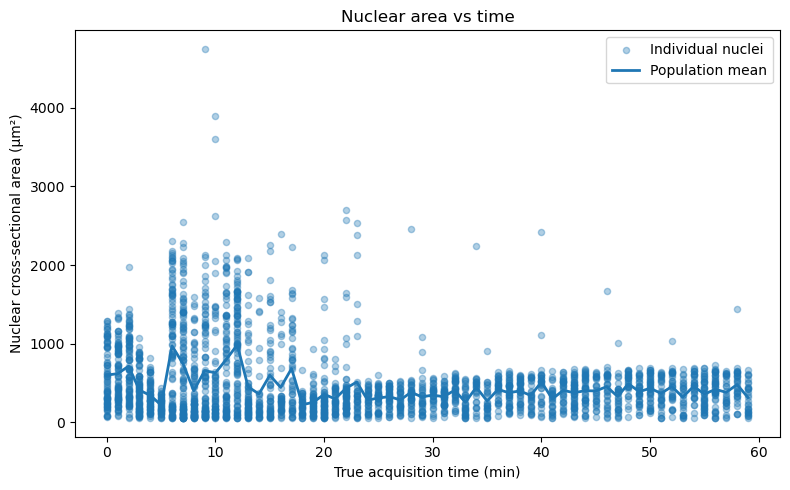

No data to plot.


In [150]:
tmp = tm[tm.mean_prob > 0.7].copy()
print(f"kept {len(tmp)}/{len(tm)}; unique nuclei/t:")
print(tmp.groupby("t")["track_id"].nunique())

plot_largest_cross_sectional_area_vs_time(tmp, cfg)

hf_p = halo_df.merge(tmp[["t","track_id"]].drop_duplicates(), on=["t","track_id"])
plot_nc_vs_time(hf_p)

track 1083: present at t = [2, 3, 4, 5, 6, 7, 8, 9]


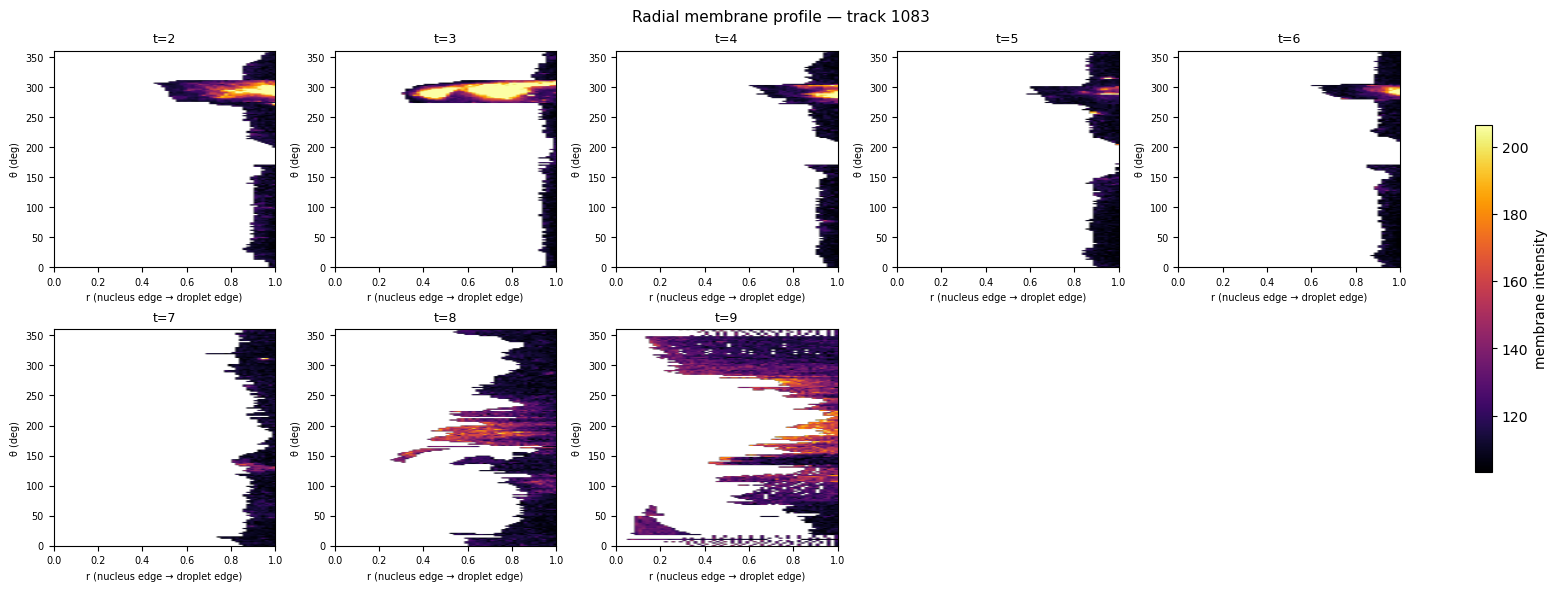

In [151]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

radial_df = pd.read_pickle(cfg.analysis_dir / "radial_sweep.pkl")

# --- pick the longest-lived track (or set TRACK manually) ---
span = radial_df.groupby("track_id")["t"].nunique().sort_values(ascending=False)
TRACK = int(span.index[0])
print(f"track {TRACK}: present at t = {sorted(radial_df[radial_df.track_id==TRACK].t.unique())}")

sub = radial_df[radial_df.track_id == TRACK].copy()

# --- radial axis: normalised (nucleus edge -> droplet edge) ---
RBINS = 60
sub["rbin"] = pd.cut(sub.distance_norm, np.linspace(0, 1, RBINS + 1), labels=False)

ts = sorted(sub.t.unique())
grids = {t: (sub[sub.t == t]
             .pivot_table(index="theta_index", columns="rbin",
                          values="intensity", aggfunc="mean")
             .reindex(index=range(cfg.radial_n_angles), columns=range(RBINS)))
         for t in ts}

allv = np.concatenate([g.to_numpy().ravel() for g in grids.values()])
vmin, vmax = np.nanpercentile(allv, [2, 98])

ncol = min(5, len(ts)); nrow = int(np.ceil(len(ts) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1*ncol, 2.9*nrow),
                         squeeze=False, constrained_layout=True)
for ax, t in zip(axes.ravel(), ts):
    im = ax.imshow(grids[t].to_numpy(), aspect="auto", origin="lower",
                   extent=[0, 1, 0, 360], vmin=vmin, vmax=vmax, cmap="inferno")
    ax.set_title(f"t={t}", fontsize=9)
    ax.set_xlabel("r (nucleus edge → droplet edge)", fontsize=7)
    ax.set_ylabel("θ (deg)", fontsize=7)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(ts):]:
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7, label="membrane intensity")
fig.suptitle(f"Radial membrane profile — track {TRACK}", fontsize=11)
plt.show()